---

# HW3: Unsupervised Learning, Dimensionality Reduction and Anomaly Detection

### Video Game Sales 2024 (VGChartz)

**Course:** Introduction to Data Science &nbsp;&nbsp;|&nbsp;&nbsp; **Final Homework**

Third notebook in the series: `eda_homework1.ipynb` (HW1) described the dataset,
`regression_classification_hw2.ipynb` (HW2) modelled it with labels, and this one removes the labels
entirely. It is fully self-contained -- it loads `vgchartz-2024.csv` itself and runs end-to-end
without the earlier notebooks -- but it refers back to their findings where they matter.

---

## Overview

No target guides the analysis: the question is what *geometry* the data has on its own -- whether
there are groups, how many directions of variation actually matter, and which observations sit far
enough from everything else to be called anomalous.

The notebook follows the brief in order:

| Section | Brief section (weight) | Content |
|---|---|---|
| 1 | 1 (10%) | Dataset selection, provenance, feature dictionary, biases |
| 2 | 2 (15%) | Exploratory analysis: structure, distributions, outlier exploration |
| 3 | 3 (20%) | PCA: explained variance, scree, 2D/3D projections, loadings, plus a t-SNE comparison |
| 4 | 4 (20%) | K-Means, DBSCAN and Hierarchical clustering -- on samples **and** on the feature space |
| 5 | 5 (25%) | Anomaly detection: Z-score, Isolation Forest, LOF |
| 6 | 6 | Comparison of the three detectors |
| 7 | 7 (10%) | Critical reflection and ethics |
| 8 | 8 (bonus) | Visualization dashboard |
| 9 | -- | Conclusions |

**A warning stated up front, because it shapes every conclusion below.** This dataset does *not*
contain clean, well-separated clusters, and it contains no ground-truth anomaly label. The analysis
therefore reports weak structure honestly rather than tuning parameters until a picture looks tidy.
Where a method produces a confident-looking answer, the notebook asks what would have to be true for
that answer to be trusted -- and frequently finds that it is not.

## 1 Dataset Selection (brief section 1)

### 1.1 Provenance

**Where it comes from.** `vgchartz-2024.csv` (Kaggle), a scrape of **VGChartz.com**, a commercial
video-game sales-tracking site active since 2005.

**Why it was collected.** VGChartz estimates *retail unit sales* of console games to sell market
intelligence to publishers, retailers and the trade press. The data is a commercial product, not a
scientific instrument, and this matters for every interpretation below.

**Who collected it.** VGChartz staff, from a mix of retail point-of-sale panels, publisher
disclosures and proprietary extrapolation. The methodology is not published. The Kaggle upload is a
third-party scrape of the site as of **2024**.

**How the estimates are produced.** Regional figures are modelled from sampled retail panels and
scaled to a whole territory. They are *estimates*, not audited sales -- a fact that will reappear in
2 as visible rounding artifacts and in 5 as detected "anomalies" that are really measurement
noise.

### 1.2 The analysis frame for this part

HW2 deliberately **excluded** the four regional sales columns as target leakage. There is no target
here, so that restriction disappears: the regional breakdown becomes the most informative structure
in the dataset, because it describes *where in the world* a title sold, independently of how much it
sold in total.

The unsupervised frame therefore uses **complete cases** on the regional breakdown plus
`critic_score` and `release_date`. No imputation is used anywhere in this notebook -- among the rows
that do have a full regional split, `critic_score` is missing for **45.5%** (computed below), and
imputing that much of a feature would manufacture a dense artificial spike at the median, which clustering would read as a
cluster and anomaly detection would read as the normal region. Complete-case selection is the
honest choice and its cost is stated explicitly in 1.4.

### 1.3 Feature dictionary

Twelve numeric features, grouped into four families:

| # | Feature | Family | Meaning |
|---|---|---|---|
| 1 | `critic_score` | Reception | VGChartz aggregate critic rating, 0-10 |
| 2 | `log_total_sales` | Commercial scale | $\log(1+\text{total units, millions})$ -- overall commercial size |
| 3 | `na_share` | Geography | North America / total regional sales |
| 4 | `pal_share` | Geography | Europe + Australia (PAL territories) / total |
| 5 | `jp_share` | Geography | Japan / total |
| 6 | `other_share` | Geography | Rest of world / total |
| 7 | `regional_concentration` | Geography | $\sum_r s_r^2$ -- Herfindahl index of the four shares; 0.25 = perfectly even across regions, 1.0 = single-region title |
| 8 | `release_year` | Time | Calendar year of release |
| 9 | `platform_count` | Release strategy | Number of distinct consoles the title shipped on |
| 10 | `log_publisher_catalogue` | Industry scale | $\log(1+\#\text{titles by that publisher in the full catalogue})$ |
| 11 | `log_developer_catalogue` | Industry scale | Same, for the developer |
| 12 | `log_console_catalogue` | Industry scale | Same, for the console -- a proxy for platform install base |

`title`, `genre`, `console`, `publisher` and `developer` are kept **outside** the feature matrix and
used only to *interpret* clusters and anomalies afterwards. This is deliberate: one-hot encoding a
60-level `console` column would add sixty near-empty binary axes to a Euclidean distance, and the
curse of dimensionality discussed in 7 would be self-inflicted rather than observed.

**A built-in linear dependency, on purpose.** The four shares sum exactly to 1. The design matrix is
therefore *rank-deficient by construction*, and PCA must find a component with exactly zero
variance. This is kept rather than removed because it turns an abstract point about redundancy into
something measurable in 3.

### 1.4 Limitations and biases

1. **Retail only.** The figures count physical retail units. Digital sales, free-to-play, mobile and
   PC storefronts are absent, so the "market" here is the shrinking half of the real one.
2. **Coverage bias.** Only **3.5%** of catalogue rows carry a full regional breakdown at all, and
   only **1.9%** carry that *and* a critic score (both figures are computed below, not asserted). Those rows are systematically the larger, Western-published, well-reviewed releases. Every
   statement below describes **the tracked, reviewed, retail segment**, not the games industry.
3. **Modelled estimates.** Regional numbers are extrapolations from panels, rounded to 0.01M. The
   rounding grid is visible in 2 and creates artificial ties.
4. **Survivorship and era skew.** The frame concentrates on 2005-2015 (PS3/X360 era) because that is
   when VGChartz tracking and critic aggregation overlapped best.
5. **Title duplication.** A multi-platform release appears once per console. Rows are therefore
   **not independent** -- `GTA V (PS3)` and `GTA V (PS4)` are near-duplicates, which inflates local
   density around blockbusters and directly affects LOF in 5.
6. **No ground truth.** There is no anomaly label and no true cluster count. Nothing in this notebook can
   be *validated*; it can only be argued for.

In [1]:
# =============================================================================
# Setup. This block re-imports everything the notebook needs, so it runs standalone --
# no dependency on the HW1 or HW2 notebooks.
# =============================================================================
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.manifold import TSNE, trustworthiness
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             calinski_harabasz_score, davies_bouldin_score,
                             adjusted_rand_score, pairwise_distances)

warnings.filterwarnings('ignore', category=FutureWarning)

RANDOM_STATE = 42          # one seed for every stochastic component
CONTAMINATION = 0.05       # assumed anomaly rate; its arbitrariness is discussed in 5
N_CLUSTERS = 3             # selected empirically in 4.1
# Source: "Video Game Sales 2024" on Kaggle, a scrape of VGChartz.com. The file sits
# beside this notebook, exactly as it did for HW1 and HW2 -- no download step is needed.
DATA_PATH = 'vgchartz-2024.csv'

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11, 'axes.labelsize': 10})
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)

REGION_COLUMNS = ['na_sales', 'pal_sales', 'jp_sales', 'other_sales']
SHARE_COLUMNS = ['na_share', 'pal_share', 'jp_share', 'other_share']
CONTEXT_COLUMNS = ['title', 'console', 'genre', 'publisher', 'developer',
                   'total_sales', 'critic_score', 'release_year']

In [2]:
def build_unsupervised_frame(csv_path: str = DATA_PATH) -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
    """Build the complete-case, purely numeric frame used throughout this notebook.

    Unlike HW2 this keeps the regional sales columns: without a target there is no
    leakage, and the regional breakdown carries the geographic structure that the
    clustering and anomaly sections depend on.

    Returns
    -------
    raw : the full de-duplicated catalogue, returned so that every coverage and
          missingness figure quoted below is computed rather than asserted.
    frame : DataFrame with the 12 numeric features plus the context columns kept
            aside for interpretation.
    features : the ordered list of the 12 numeric feature names.
    """
    raw = pd.read_csv(csv_path).drop_duplicates().reset_index(drop=True)

    raw['release_date'] = pd.to_datetime(raw['release_date'], format='%d/%m/%Y', errors='coerce')
    raw['release_year'] = raw['release_date'].dt.year
    raw['platform_count'] = raw['title'].map(raw.groupby('title')['console'].nunique())
    raw[['publisher', 'developer']] = raw[['publisher', 'developer']].replace('Unknown', np.nan)

    # Catalogue sizes are counted on the FULL catalogue, not on the complete-case
    # subset, so they describe the industry rather than the sample.
    publisher_size = raw['publisher'].value_counts()
    developer_size = raw['developer'].value_counts()
    console_size = raw['console'].value_counts()

    required = REGION_COLUMNS + ['total_sales', 'critic_score', 'release_year']
    frame = raw[raw[required].notna().all(axis=1)].copy()

    regional_total = frame[REGION_COLUMNS].sum(axis=1)
    frame['na_share'] = frame['na_sales'] / regional_total
    frame['pal_share'] = frame['pal_sales'] / regional_total
    frame['jp_share'] = frame['jp_sales'] / regional_total
    frame['other_share'] = frame['other_sales'] / regional_total
    frame['regional_concentration'] = frame[SHARE_COLUMNS].pow(2).sum(axis=1)

    frame['log_total_sales'] = np.log1p(frame['total_sales'])
    frame['log_publisher_catalogue'] = np.log1p(frame['publisher'].map(publisher_size)).fillna(0.0)
    frame['log_developer_catalogue'] = np.log1p(frame['developer'].map(developer_size)).fillna(0.0)
    frame['log_console_catalogue'] = np.log1p(frame['console'].map(console_size))

    features = ['critic_score', 'log_total_sales',
                'na_share', 'pal_share', 'jp_share', 'other_share',
                'regional_concentration', 'release_year', 'platform_count',
                'log_publisher_catalogue', 'log_developer_catalogue', 'log_console_catalogue']
    return raw, frame.reset_index(drop=True), features


catalogue, unsupervised, FEATURES = build_unsupervised_frame()

requirement_check = pd.DataFrame([
    {'Requirement': 'At least 1000 rows',       'Actual': f'{len(unsupervised):,} rows',
     'Met': len(unsupervised) >= 1000},
    {'Requirement': 'At least 8 features',      'Actual': f'{len(FEATURES)} numeric features',
     'Met': len(FEATURES) >= 8},
    {'Requirement': 'Mostly numerical',         'Actual': 'all 12 modelling features are numeric',
     'Met': True},
    {'Requirement': 'Real-world dataset',       'Actual': 'VGChartz retail sales tracking',
     'Met': True},
    {'Requirement': 'No pre-labeled anomalies', 'Actual': 'no anomaly / outlier column exists',
     'Met': True},
])
display(requirement_check)

regional_complete = catalogue[REGION_COLUMNS].notna().all(axis=1)
print(f'Catalogue rows                 : {len(catalogue):,}')
print(f'  with a full regional split   : {regional_complete.sum():,} '
      f'({regional_complete.mean():.1%} of the catalogue)')
print(f'  ... and a critic score       : {len(unsupervised):,} '
      f'({len(unsupervised) / len(catalogue):.1%} of the catalogue)')
print(f'critic_score missing among the rows that DO have a regional split: '
      f'{catalogue.loc[regional_complete, "critic_score"].isna().mean():.1%} '
      '-- the reason no imputation is used')
print(f'Release years covered          : {int(unsupervised["release_year"].min())}-'
      f'{int(unsupervised["release_year"].max())}')
print(f'Distinct titles                : {unsupervised["title"].nunique():,} '
      f'({unsupervised["title"].duplicated().sum():,} multi-platform duplicate titles)')

,Requirement,Actual,Met
0,At least 1000 rows,"1,210 rows",True
1,At least 8 features,12 numeric features,True
2,Mostly numerical,all 12 modelling features are numeric,True
3,Real-world dataset,VGChartz retail sales tracking,True
4,No pre-labeled anomalies,no anomaly / outlier column exists,True


Catalogue rows                 : 63,995
  with a full regional split   : 2,222 (3.5% of the catalogue)
  ... and a critic score       : 1,210 (1.9% of the catalogue)
critic_score missing among the rows that DO have a regional split: 45.5% -- the reason no imputation is used
Release years covered          : 1989-2018
Distinct titles                : 942 (268 multi-platform duplicate titles)


**What the selection costs.** 1,210 rows survive out of 63,995 -- **1.9%** of the catalogue. That
number is the single most important caveat in this notebook. The surviving rows are not a random sample:
they are the titles VGChartz tracked in enough detail to break out four regions *and* that a critic
aggregator scored. The median release year is 2009 and the range is 1989-2018, so the frame is
effectively **a census of the well-tracked retail console era**, not of games.

This is a real limitation, but not a fatal one for the assignment's purpose: the geometry, clusters
and anomalies found below are genuine properties of that segment, and every conclusion is stated
with that population in mind.

---

## 2 Exploratory Data Analysis (brief section 2)

### 2.1 Structural analysis

Rows, columns, missing values, data types and the statistical summary. The frame is complete by
construction, so the interesting structural facts are the *dependencies between columns* rather than
gaps in them.

In [3]:
numeric_frame = unsupervised[FEATURES]

structure = pd.DataFrame({
    'dtype': numeric_frame.dtypes.astype(str),
    'missing': numeric_frame.isna().sum(),
    'missing_%': (numeric_frame.isna().mean() * 100).round(2),
    'unique': numeric_frame.nunique(),
})
print(f'Shape of the numeric design matrix: {numeric_frame.shape[0]:,} rows x '
      f'{numeric_frame.shape[1]} columns')
print(f'Total missing values             : {int(numeric_frame.isna().sum().sum())} '
      '(zero by construction -- the frame is complete-case)')
display(structure)
display(numeric_frame.describe().T.round(3))

# The complete-case frame has no missing values, so the informative missingness is the
# one in the FULL catalogue that the filter removed. Reported here rather than asserted.
catalogue_missing = pd.DataFrame({
    'missing': catalogue.isna().sum(),
    'missing_%': (catalogue.isna().mean() * 100).round(1),
}).sort_values('missing_%', ascending=False)
print(f'\nMissingness in the FULL catalogue ({len(catalogue):,} rows) -- what the '
      'complete-case filter had to remove:')
display(catalogue_missing)

Shape of the numeric design matrix: 1,210 rows x 12 columns
Total missing values             : 0 (zero by construction -- the frame is complete-case)


,dtype,missing,missing_%,unique
critic_score,float64,0,0.0,65
log_total_sales,float64,0,0.0,378
na_share,float64,0,0.0,952
pal_share,float64,0,0.0,883
jp_share,float64,0,0.0,864
other_share,float64,0,0.0,699
regional_concentration,float64,0,0.0,1167
release_year,float64,0,0.0,25
platform_count,int64,0,0.0,13
log_publisher_catalogue,float64,0,0.0,76


,count,mean,std,min,25%,50%,75%,max
critic_score,1210.0,7.538,1.200,3.000,6.800,7.700,8.400,10.000
log_total_sales,1210.0,0.713,0.561,0.020,0.300,0.536,0.947,3.060
na_share,1210.0,0.464,0.189,0.012,0.335,0.460,0.593,0.944
pal_share,1210.0,0.282,0.170,0.000,0.154,0.286,0.396,0.903
jp_share,1210.0,0.154,0.190,0.000,0.015,0.060,0.242,0.938
other_share,1210.0,0.100,0.060,0.000,0.067,0.091,0.127,0.809
regional_concentration,1210.0,0.433,0.114,0.262,0.356,0.408,0.472,0.895
release_year,1210.0,2008.826,4.749,1989.000,2007.000,2009.000,2011.000,2018.000
platform_count,1210.0,3.361,2.312,1.000,1.000,3.000,5.000,13.000
log_publisher_catalogue,1210.0,6.494,1.053,1.386,5.645,6.997,7.343,7.699



Missingness in the FULL catalogue (63,995 rows) -- what the complete-case filter had to remove:


,missing,missing_%
critic_score,57317,89.6
jp_sales,57272,89.5
na_sales,51358,80.3
pal_sales,51171,80.0
other_sales,48867,76.4
total_sales,45076,70.4
publisher,8842,13.8
release_date,7051,11.0
release_year,7051,11.0
developer,4451,7.0


In [4]:
# The four regional shares sum to 1 by construction -- verify the exact dependency,
# because it is the reason PCA will produce a zero-variance component in 3.
share_sum = unsupervised[SHARE_COLUMNS].sum(axis=1)
print(f'Sum of the four regional shares: min={share_sum.min():.12f}  max={share_sum.max():.12f}')

# total_sales is also (up to rounding) the sum of the four regional columns.
reported_gap = unsupervised['total_sales'] - unsupervised[REGION_COLUMNS].sum(axis=1)
relative_gap = reported_gap.abs() / unsupervised['total_sales']
print(f'total_sales - sum(regions)     : max |gap| = {reported_gap.abs().max():.4f}M; '
      f'{(reported_gap.abs() > 0.005).mean():.1%} of rows differ by at least one rounding unit, '
      f'{(relative_gap > 0.05).mean():.1%} by more than 5% of the title')

design_matrix = numeric_frame.to_numpy()
centred = design_matrix - design_matrix.mean(axis=0)
print(f'Rank of the raw design matrix     : {np.linalg.matrix_rank(design_matrix)} of '
      f'{design_matrix.shape[1]} columns  (the shares sum to the constant 1, an AFFINE dependency)')
print(f'Rank of the CENTRED design matrix : {np.linalg.matrix_rank(centred)} of '
      f'{centred.shape[1]} columns  (centring turns it into a linear one -- this is what PCA sees)')

Sum of the four regional shares: min=1.000000000000  max=1.000000000000
total_sales - sum(regions)     : max |gap| = 0.0200M; 41.3% of rows differ by at least one rounding unit, 4.8% by more than 5% of the title
Rank of the raw design matrix     : 12 of 12 columns  (the shares sum to the constant 1, an AFFINE dependency)
Rank of the CENTRED design matrix : 11 of 12 columns  (centring turns it into a linear one -- this is what PCA sees)


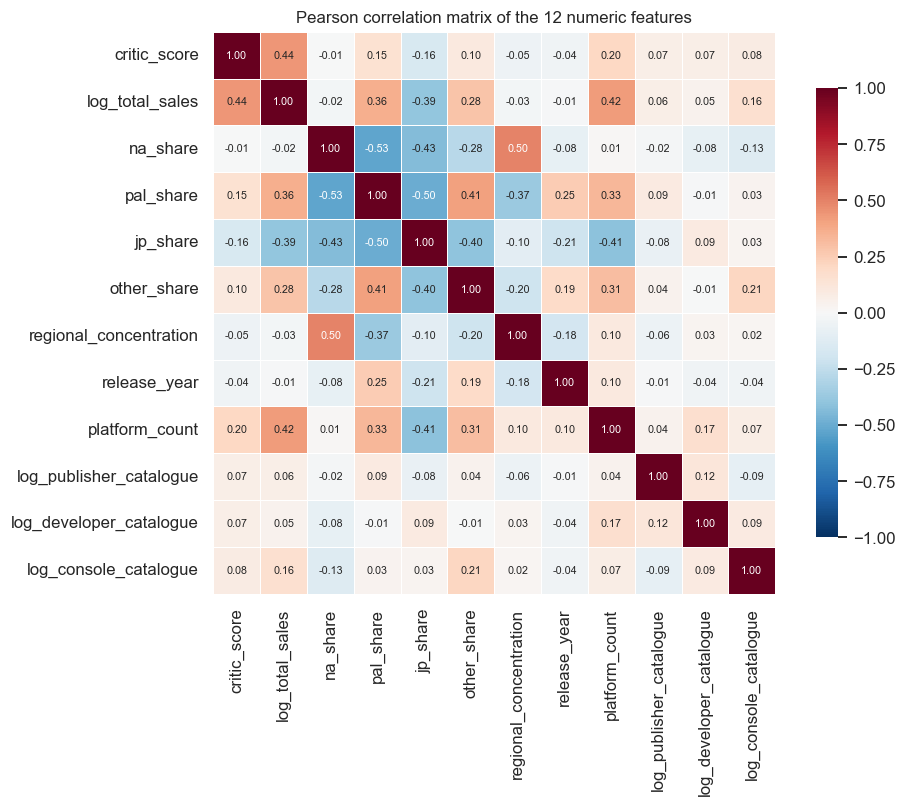

Strongest linear relationships:


,feature A,feature B,|correlation|
0,na_share,pal_share,0.528
1,na_share,regional_concentration,0.499
2,pal_share,jp_share,0.495
3,critic_score,log_total_sales,0.445
4,na_share,jp_share,0.435
5,log_total_sales,platform_count,0.425
6,pal_share,other_share,0.408
7,jp_share,platform_count,0.408


In [5]:
correlation = numeric_frame.corr()

fig, ax = plt.subplots(figsize=(9.5, 7.5))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, cbar_kws={'shrink': 0.8}, annot_kws={'size': 7}, ax=ax)
ax.set_title('Pearson correlation matrix of the 12 numeric features')
plt.tight_layout()
plt.show()

upper_triangle = correlation.abs().where(np.triu(np.ones(correlation.shape), 1).astype(bool))
strongest_pairs = (upper_triangle.stack().sort_values(ascending=False).head(8)
                   .rename('|correlation|').reset_index()
                   .rename(columns={'level_0': 'feature A', 'level_1': 'feature B'}))
print('Strongest linear relationships:')
display(strongest_pairs.round(3))

**Reading the correlation matrix.**

*The geography block is internally negatively correlated.* `na_share` vs `pal_share` = **-0.53**,
`pal_share` vs `jp_share` = **-0.50**, `na_share` vs `jp_share` = **-0.43**. These are not
discoveries about taste; they are the **simplex constraint** made visible. Four non-negative numbers
that sum to one *cannot* be positively correlated on average -- a title that sells more of its units
in Japan mechanically sells a smaller share elsewhere. Any method that treats these four columns as
independent measurements is wrong, and PCA will exploit exactly this.

*Commercial scale is a second, largely separate block.* `log_total_sales` correlates with
`critic_score` (**0.44**) and `platform_count` (**0.42**). Better-reviewed titles on more platforms
sell more -- unsurprising, and consistent with HW1/HW2, but worth noting that the correlation with
critic score is moderate, not overwhelming.

*Japan is where the two blocks meet.* `jp_share` is negatively correlated with `log_total_sales`
(-0.39), with `platform_count` (-0.41) and with `critic_score` (-0.16). A Japan-heavy title tends to
be a smaller, single-platform, lower-scored release **in this Western-tracked dataset**. This is the
same Japan-decoupling effect HW1 found and HW2's classifier kept tripping over, arriving here from a
completely different direction with no labels involved.

*The industry-scale block is nearly orthogonal to everything.* `log_publisher_catalogue`,
`log_developer_catalogue` and `log_console_catalogue` have |r| < 0.22 against every other feature and
< 0.13 among themselves. How prolific a publisher is says almost nothing about how a specific title
performs. 4.6 will re-derive this fact by clustering the feature space itself.

*The rank is 12 raw but **11 once centred*** -- and the distinction is instructive.
`na_share + pal_share + jp_share + other_share = 1` is an **affine** dependency: the columns sum to a
constant, not to zero, so the uncentred matrix still has full rank. Centring (which PCA and
standardisation both do) turns the constant into zero and the dependency becomes exactly linear.
**PCA therefore sees an 11-dimensional dataset**, and 3 will find a component with literally zero
variance.

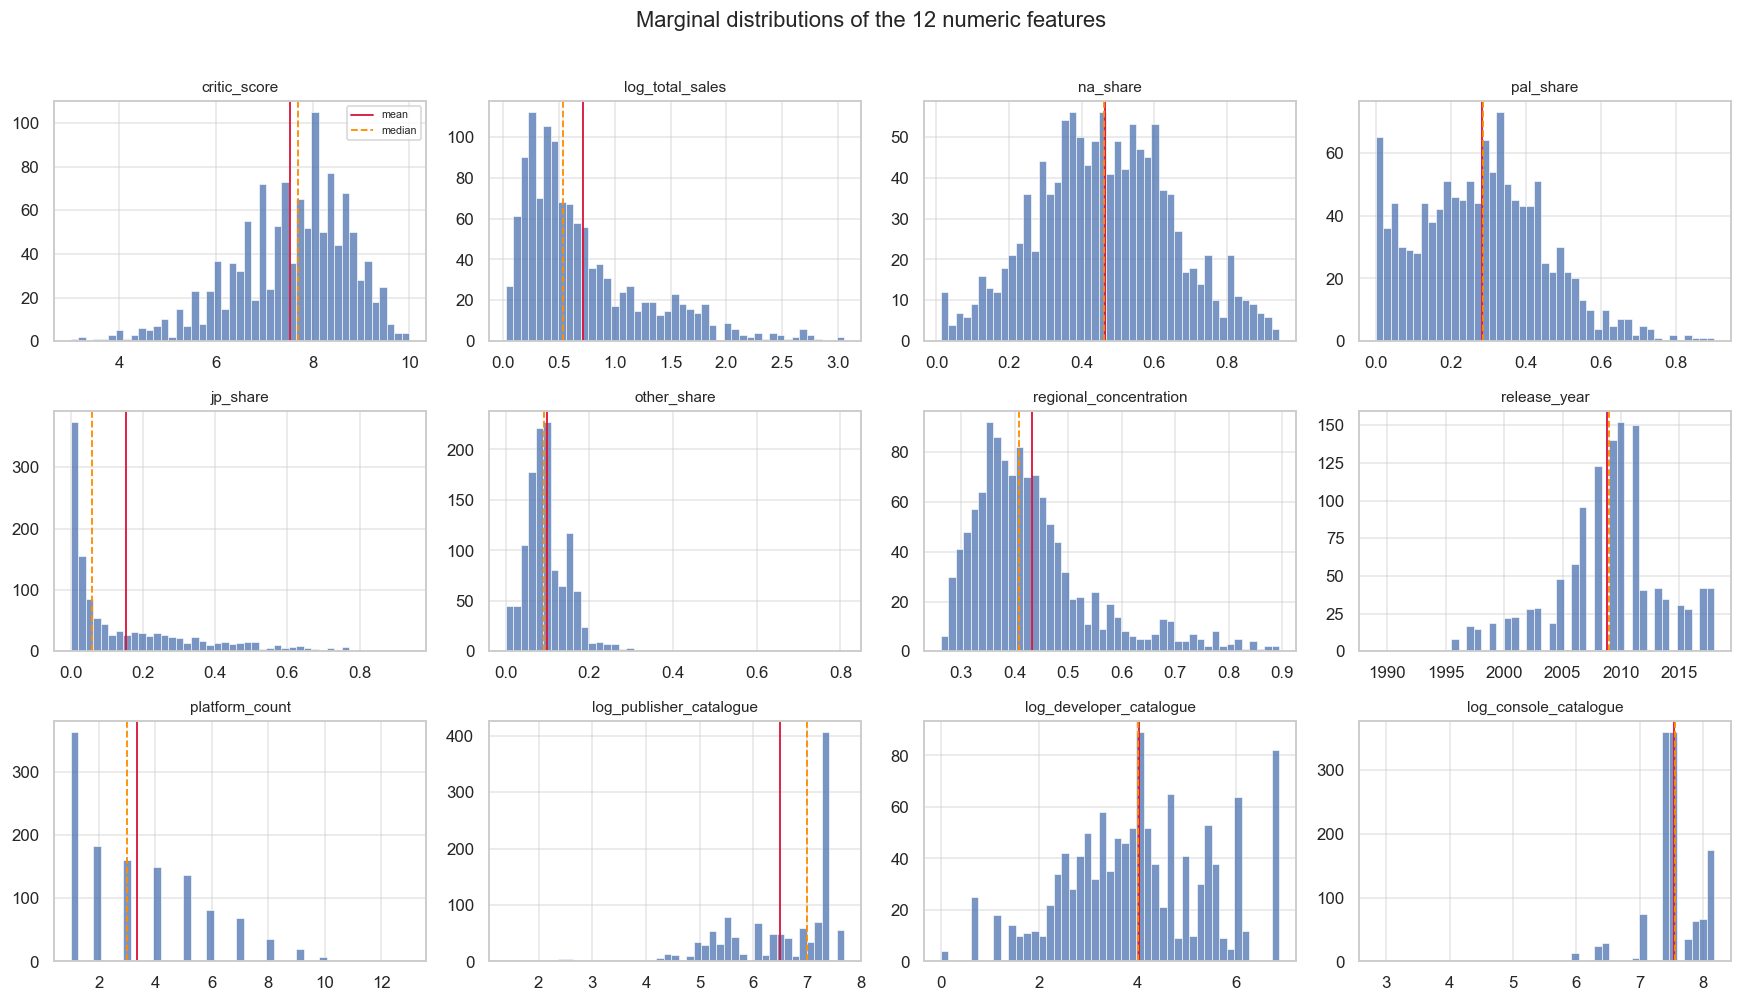

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, feature in zip(axes.ravel(), FEATURES):
    sns.histplot(numeric_frame[feature], bins=45, ax=ax, color='#4C72B0', edgecolor=None)
    ax.axvline(numeric_frame[feature].mean(), color='crimson', lw=1.2, ls='-', label='mean')
    ax.axvline(numeric_frame[feature].median(), color='darkorange', lw=1.2, ls='--', label='median')
    ax.set_title(feature, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
axes[0, 0].legend(fontsize=7)
fig.suptitle('Marginal distributions of the 12 numeric features', y=1.01)
plt.tight_layout()
plt.show()

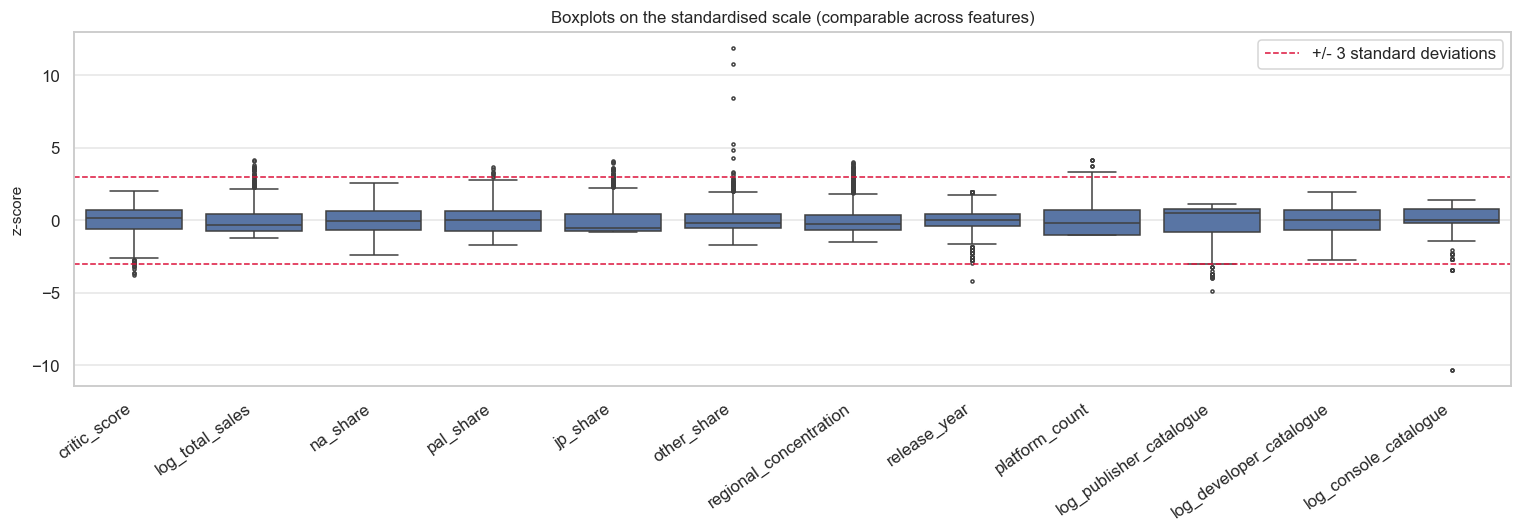

In [7]:
standardised = pd.DataFrame(StandardScaler().fit_transform(numeric_frame),
                            columns=FEATURES, index=numeric_frame.index)

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=standardised, orient='v', ax=ax, fliersize=2, color='#4C72B0')
ax.axhline(3, color='crimson', lw=1, ls='--', label='+/- 3 standard deviations')
ax.axhline(-3, color='crimson', lw=1, ls='--')
ax.set_title('Boxplots on the standardised scale (comparable across features)')
ax.set_ylabel('z-score')
ax.legend()
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

In [8]:
shape_statistics = pd.DataFrame({
    'mean': numeric_frame.mean(),
    'std': numeric_frame.std(),
    'skewness': numeric_frame.apply(stats.skew),
    'excess_kurtosis': numeric_frame.apply(lambda column: stats.kurtosis(column, fisher=True)),
    'p99 / p50': (numeric_frame.quantile(0.99) / numeric_frame.quantile(0.50)),
    'beyond_3sd': (standardised.abs() > 3).sum(),
})
shape_statistics['shape'] = np.select(
    [shape_statistics['skewness'] > 1, shape_statistics['skewness'] < -1],
    ['heavy right tail', 'heavy left tail'], default='roughly symmetric')
display(shape_statistics.sort_values('excess_kurtosis', ascending=False).round(3))

normality = pd.DataFrame({
    'Shapiro-Wilk p': [stats.shapiro(numeric_frame[f].sample(500, random_state=RANDOM_STATE)).pvalue
                       for f in FEATURES],
}, index=FEATURES)
normality['Gaussian at 5%?'] = np.where(normality['Shapiro-Wilk p'] > 0.05, 'not rejected', 'REJECTED')
print('Normality test on a 500-row sample of each feature '
      '(relevant because 5.1 assumes Gaussianity):')
display(normality.round(6))

,mean,std,skewness,excess_kurtosis,p99 / p50,beyond_3sd,shape
other_share,0.100,0.060,3.531,32.016,2.865,9,heavy right tail
log_console_catalogue,7.543,0.457,-2.610,19.539,1.083,15,heavy left tail
regional_concentration,0.433,0.114,1.449,2.243,2.012,27,heavy right tail
jp_share,0.154,0.190,1.508,1.680,12.572,19,heavy right tail
log_total_sales,0.713,0.561,1.385,1.670,4.927,22,heavy right tail
log_publisher_catalogue,6.494,1.053,-1.180,1.415,1.100,19,heavy left tail
platform_count,3.361,2.312,0.917,0.442,3.303,6,roughly symmetric
release_year,2008.826,4.749,-0.433,0.439,1.004,1,roughly symmetric
critic_score,7.538,1.200,-0.686,0.352,1.247,8,roughly symmetric
pal_share,0.282,0.170,0.370,-0.066,2.505,6,roughly symmetric


Normality test on a 500-row sample of each feature (relevant because 5.1 assumes Gaussianity):


,Shapiro-Wilk p,Gaussian at 5%?
critic_score,0.000000,REJECTED
log_total_sales,0.000000,REJECTED
na_share,0.029148,REJECTED
pal_share,0.000000,REJECTED
jp_share,0.000000,REJECTED
other_share,0.000000,REJECTED
regional_concentration,0.000000,REJECTED
release_year,0.000000,REJECTED
platform_count,0.000000,REJECTED
log_publisher_catalogue,0.000000,REJECTED


**What the distributions say.**

**Nothing here is Gaussian.** The Shapiro-Wilk test rejects normality at the 5% level for **all
twelve** features. That is not a technicality -- 5.1 applies a Z-score detector whose entire
justification is normality, and this table is the reason its results have to be read sceptically.

**Three genuinely heavy tails -- and they do not all point the same way.** `other_share` (skew
**+3.5**, excess kurtosis **32**) and `regional_concentration` (skew +1.45) have heavy **right**
tails; `log_console_catalogue` (skew **-2.6**, kurtosis **19.5**) has a heavy **left** tail -- a few
titles on very obscure consoles, with the bulk of releases on the handful of platforms that dominate
the catalogue. `other_share` is heavy-tailed for a structural reason: it is a residual category,
usually small, but for a handful of titles it absorbs almost everything (max 0.81). The kurtosis of
32 means the tail is roughly six times heavier than a normal distribution's -- so a "3-sigma"
threshold on this feature does not mean "0.3% of rows".

**`log_total_sales` is still right-skewed after the log.** Skew **1.38** on the log scale, i.e. the
raw sales distribution is so extreme that a logarithm only partially tames it. HW1 measured raw
skewness at 8.77; the residual 1.38 is what survives. Commercial success in this market follows a
power law, and no monotone transform makes it symmetric.

**`critic_score` is left-skewed (-0.69).** Aggregate critic scores cluster in 7-8.5 and thin out
below 6 -- a well-documented compression of the reviewing scale, not a property of games. The
practical consequence: *low* critic scores are rare and will look anomalous to any detector, even
though a badly reviewed game is a perfectly ordinary event.

**The four shares are bounded in [0, 1] and clearly non-normal:** `na_share` is nearly symmetric
around 0.46, while `jp_share` is a spike at zero with a long right tail (skew 1.51) -- most tracked
titles sell essentially nothing in Japan, and a minority sell almost exclusively there. That
bimodal-ish shape is the strongest cluster signal in the dataset, and 4 recovers it.

In [9]:
# --- Outlier exploration: tail weight, extreme values, and measurement artifacts -----
extreme_counts = (standardised.abs() > 3).sum(axis=1)
print('How many features is each row extreme on (|z| > 3)?')
display(extreme_counts.value_counts().sort_index().rename('rows').to_frame().T)

print(f'\nRows extreme on at least one feature : {(extreme_counts > 0).sum()} '
      f'({(extreme_counts > 0).mean():.1%})')
print(f'Rows extreme on two or more features : {(extreme_counts > 1).sum()} '
      f'({(extreme_counts > 1).mean():.1%})')
print('Under a true 12-dimensional Gaussian we would expect about '
      f'{100 * (1 - (1 - 2 * stats.norm.sf(3)) ** 12):.1f}% of rows to be extreme somewhere, '
      'purely by chance.')

print('\n--- The five largest values on the three heaviest-tailed features ---')
for feature in ['other_share', 'regional_concentration', 'log_total_sales']:
    top = unsupervised.nlargest(5, feature)[['title', 'console', 'total_sales', feature]]
    print(f'\n{feature}:')
    display(top.round(3))

How many features is each row extreme on (|z| > 3)?


,0,1,2
rows,1090,108,12



Rows extreme on at least one feature : 120 (9.9%)
Rows extreme on two or more features : 12 (1.0%)
Under a true 12-dimensional Gaussian we would expect about 3.2% of rows to be extreme somewhere, purely by chance.

--- The five largest values on the three heaviest-tailed features ---

other_share:


,title,console,total_sales,other_share
128,Pro Evolution Soccer 2008,PS2,3.63,0.809
303,Pro Evolution Soccer 2010,PS2,1.57,0.744
847,007: Quantum of Solace,PS2,0.43,0.605
180,Gran Turismo (PSP),PSN,2.82,0.413
679,Silent Hill: Shattered Memories,PS2,0.59,0.390



regional_concentration:


,title,console,total_sales,regional_concentration
1113,The Munchables,Wii,0.18,0.895
1118,Cubivore: Survival of the Fittest,GC,0.17,0.883
955,NBA Live 08,PSP,0.31,0.876
683,Madden NFL 06,X360,0.59,0.870
86,Madden NFL 2005,PS2,4.53,0.855



log_total_sales:


,title,console,total_sales,log_total_sales
0,Grand Theft Auto V,PS3,20.32,3.060
1,Grand Theft Auto V,PS4,19.39,3.015
2,Grand Theft Auto: Vice City,PS2,16.15,2.842
3,Call of Duty: Black Ops 3,PS4,15.09,2.778
4,Call of Duty: Modern Warfare 3,X360,14.82,2.761


Sales are reported to 0.01M. Consequences of that grid:
  distinct total_sales values      : 378 for 1,210 rows
  rows with jp_sales exactly 0.00  : 87 (7.2%)
  rows with a regional value <=0.02: 54.6%


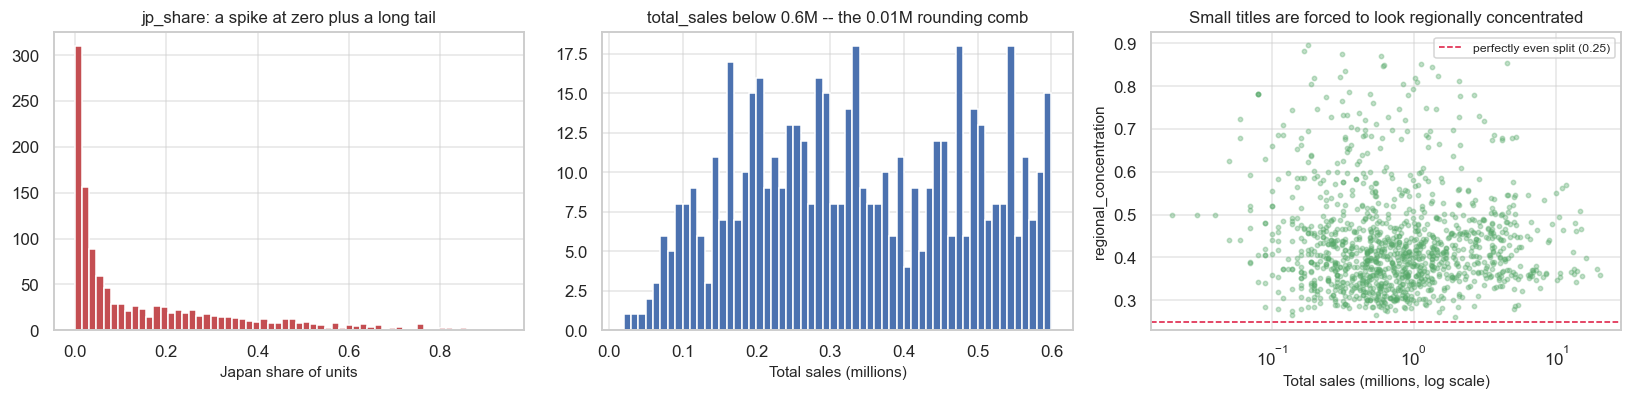

In [10]:
# --- Measurement artifacts: the rounding grid of the sales estimates ---------------
raw_sales = unsupervised[['total_sales'] + REGION_COLUMNS]
print('Sales are reported to 0.01M. Consequences of that grid:')
print(f'  distinct total_sales values      : {raw_sales["total_sales"].nunique()} '
      f'for {len(raw_sales):,} rows')
print(f'  rows with jp_sales exactly 0.00  : {(unsupervised["jp_sales"] == 0).sum()} '
      f'({(unsupervised["jp_sales"] == 0).mean():.1%})')
print(f'  rows with a regional value <=0.02: '
      f'{(unsupervised[REGION_COLUMNS] <= 0.02).any(axis=1).mean():.1%}')

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].hist(unsupervised['jp_share'], bins=60, color='#C44E52')
axes[0].set_title('jp_share: a spike at zero plus a long tail')
axes[0].set_xlabel('Japan share of units')

small = unsupervised[unsupervised['total_sales'] <= 0.6]
axes[1].hist(small['total_sales'], bins=58, color='#4C72B0')
axes[1].set_title('total_sales below 0.6M -- the 0.01M rounding comb')
axes[1].set_xlabel('Total sales (millions)')

axes[2].scatter(unsupervised['total_sales'], unsupervised['regional_concentration'],
                s=8, alpha=0.35, color='#55A868')
axes[2].set_xscale('log')
axes[2].axhline(0.25, color='crimson', ls='--', lw=1, label='perfectly even split (0.25)')
axes[2].set_title('Small titles are forced to look regionally concentrated')
axes[2].set_xlabel('Total sales (millions, log scale)')
axes[2].set_ylabel('regional_concentration')
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

#### Outlier exploration -- the four causes named in the brief

**1. Heavy tails.** 9.9% of rows are beyond 3 standard deviations on at least one feature; a genuine
12-dimensional Gaussian would produce about 3.2%. The excess is a factor of three, and it is not
spread evenly: `regional_concentration` (27 rows), `log_total_sales` (22) and `jp_share` (19) carry
most of it. **A "3-sigma rule" calibrated on the normal distribution is already wrong by 3x before
any anomaly detection starts.**

**2. Extreme values that are entirely legitimate.** The largest `log_total_sales` values are *Grand
Theft Auto V*, *Call of Duty: Black Ops 3* and *Red Dead Redemption 2*. These are the most
successful entertainment products ever released. They are extreme, they are real, and they are not
errors. Any detector that reports them as "anomalies" has found the top of a power law, not a
problem -- an issue 7 returns to as the noise-versus-anomaly distinction.

**3. Noise and measurement artifacts.** Sales are estimates rounded to 0.01M. For a title selling
0.10M in a region, the rounding grid is a **10% quantisation error**. The middle panel shows the
resulting comb: only **378 distinct `total_sales` values across 1,210 rows**, and **55% of rows have at
least one regional figure at or below 0.02M** -- i.e. resolved to within one or two rounding units. Worse, the third panel shows a structural artifact: **small titles are forced to
look regionally concentrated**, because a title with 0.05M units in one region and 0.00M elsewhere
gets `regional_concentration` = 1.0 -- not because it is a regional phenomenon, but because the
measurement resolution cannot represent anything finer. **Several of the "anomalies" 5 will detect
are this artifact, not a real property of the title.**

**4. Data-entry problems.** 41% of rows have `total_sales` differing from the sum of the four regions
by at least one rounding unit, and **4.8% differ by more than 5% of the title's own sales**. The first
figure is just the 0.01M grid; the second is not -- a 0.02M discrepancy is negligible on a 5M title
and a real internal inconsistency on a 0.2M one. HW2 found harder cases in the full
catalogue (a row literally titled `... (US weekly sales)` sitting in a lifetime-sales column); the
complete-case filter here removes most of them, which is one of the few benefits of the strict
selection.

**5. A structural zero that is not missing data.** 7.2% of rows have `jp_sales` exactly 0.00. That
is not a null -- it means "did not chart in Japan", which is genuine information. Treating it as
missing would destroy the single most informative geographic signal in the dataset.

---

## 3 Dimensionality Reduction (brief section 3)

### 3.1 What PCA does, and what it assumes

PCA finds the orthonormal basis in which the covariance matrix is diagonal. Concretely: standardise
the data to $Z$, form the correlation matrix $C = \frac{1}{n-1} Z^{\top}Z$, and take its
eigendecomposition $C = V \Lambda V^{\top}$. The columns of $V$ are the principal directions, the
eigenvalues $\lambda_i$ are the variances along them, and

$$\text{explained variance ratio}_i = \frac{\lambda_i}{\sum_j \lambda_j}.$$

Projecting onto the first $k$ eigenvectors is the rank-$k$ linear map that minimises squared
reconstruction error -- the optimal *linear* compression, and nothing more.

**Three assumptions that matter here.** (i) The interesting structure is *linear* -- PCA can only
rotate, never bend. (ii) **Variance equals information**; a low-variance direction is discarded even
if it is the one that separates two groups. (iii) The features are on comparable scales, which is
why standardisation is mandatory: `release_year` has a variance of ~22.5 in raw units and `jp_share`
about 0.036, so unstandardised PCA would return "the release-year axis" as PC1 and learn nothing.

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(unsupervised[FEATURES])

pca_full = PCA(random_state=RANDOM_STATE).fit(X_scaled)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

variance_table = pd.DataFrame({
    'eigenvalue': pca_full.explained_variance_,
    'explained_variance_ratio': explained,
    'cumulative': cumulative,
}, index=[f'PC{i}' for i in range(1, len(explained) + 1)])
display(variance_table.round(4))

for threshold in (0.80, 0.90, 0.95):
    print(f'Components needed for {threshold:.0%} of the variance: '
          f'{int(np.searchsorted(cumulative, threshold) + 1)}')
print(f'Components with eigenvalue > 1 (Kaiser criterion): {(pca_full.explained_variance_ > 1).sum()}')
print(f'Smallest eigenvalue: {pca_full.explained_variance_[-1]:.2e} '
      '-- the exact linear dependency among the four shares')

,eigenvalue,explained_variance_ratio,cumulative
PC1,2.8383,0.2363,0.2363
PC2,1.9313,0.1608,0.3971
PC3,1.3650,0.1137,0.5108
PC4,1.1392,0.0949,0.6056
PC5,1.0257,0.0854,0.6911
PC6,0.8553,0.0712,0.7623
PC7,0.7898,0.0658,0.8280
PC8,0.5954,0.0496,0.8776
PC9,0.5519,0.0460,0.9236
PC10,0.4821,0.0401,0.9637


Components needed for 80% of the variance: 7
Components needed for 90% of the variance: 9
Components needed for 95% of the variance: 10
Components with eigenvalue > 1 (Kaiser criterion): 5
Smallest eigenvalue: 5.55e-17 -- the exact linear dependency among the four shares


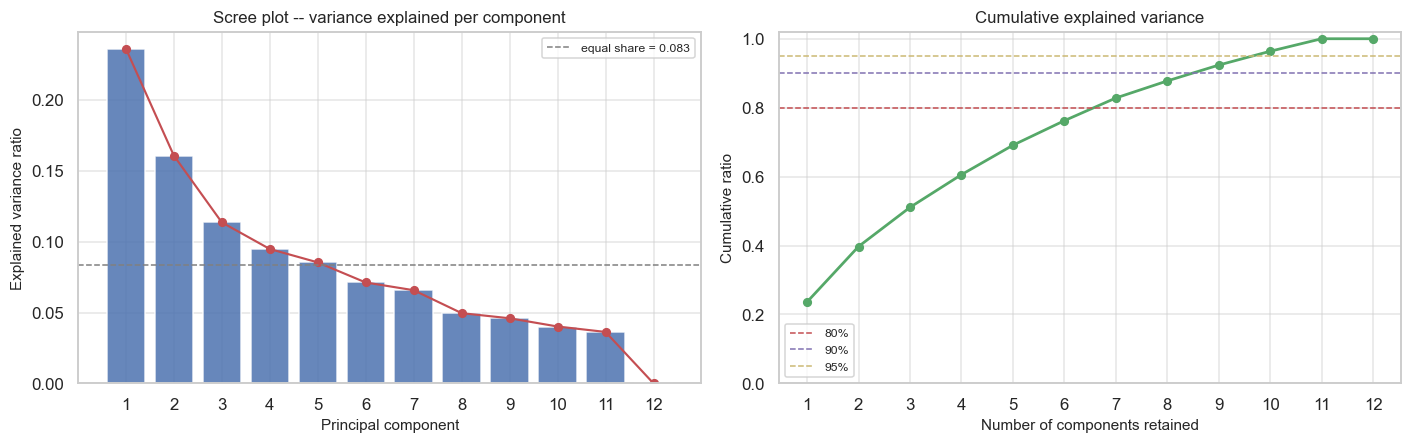

In [12]:
component_index = np.arange(1, len(explained) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].bar(component_index, explained, color='#4C72B0', alpha=0.85)
axes[0].plot(component_index, explained, 'o-', color='#C44E52', lw=1.4, ms=5)
axes[0].axhline(1 / len(FEATURES), color='grey', ls='--', lw=1,
                label=f'equal share = {1 / len(FEATURES):.3f}')
axes[0].set_title('Scree plot -- variance explained per component')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Explained variance ratio')
axes[0].set_xticks(component_index)
axes[0].legend(fontsize=8)

axes[1].plot(component_index, cumulative, 'o-', color='#55A868', lw=1.8, ms=5)
for threshold, colour in [(0.80, '#C44E52'), (0.90, '#8172B2'), (0.95, '#CCB974')]:
    axes[1].axhline(threshold, color=colour, ls='--', lw=1, label=f'{threshold:.0%}')
axes[1].set_title('Cumulative explained variance')
axes[1].set_xlabel('Number of components retained')
axes[1].set_ylabel('Cumulative ratio')
axes[1].set_xticks(component_index)
axes[1].set_ylim(0, 1.02)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**How many components are needed, and how much is lost?**

The honest answer is **the data barely compresses**. PC1 carries only **23.6%** of the variance and
PC2 **16.1%**; the first two together reach **39.7%**, so *any* 2-D picture in this notebook -- every
scatter plot below -- is showing **less than two fifths of the information** and hiding the rest.
Reaching 80% needs **7 of 12** components, 90% needs **9**, 95% needs **10**.

Compare that with the classic textbook case, where two or three components carry 80-90%. The scree
plot has **no elbow**: it declines almost linearly from 0.236 to 0.036. By the Kaiser criterion
(eigenvalue > 1) **five** components should be retained; by the 80% rule, seven. The two criteria
disagree, and neither is compelling -- which is itself the finding.

**The interpretation is that the features are largely non-redundant.** Twelve features that all
measured the same underlying thing would collapse into two or three components. These twelve measure
genuinely different things -- reception, commercial scale, geography, timing, release strategy,
industry position -- and the correlation matrix already showed why: outside the geography block,
almost all |r| < 0.25. **Dimensionality reduction here is a lossy convenience, not a discovery of
hidden low-dimensional structure.**

**The exception proves the rule.** PC12 has an eigenvalue of essentially **zero** (~4e-18). That is
the direction $na\_share + pal\_share + jp\_share + other\_share = 1$ built into the feature set in
1.3. PCA identified a perfect redundancy automatically and priced it at zero variance. This is
exactly what one hopes PCA will do -- and it found the *only* exactly redundant direction that
exists, confirming that the other eleven are not redundant.

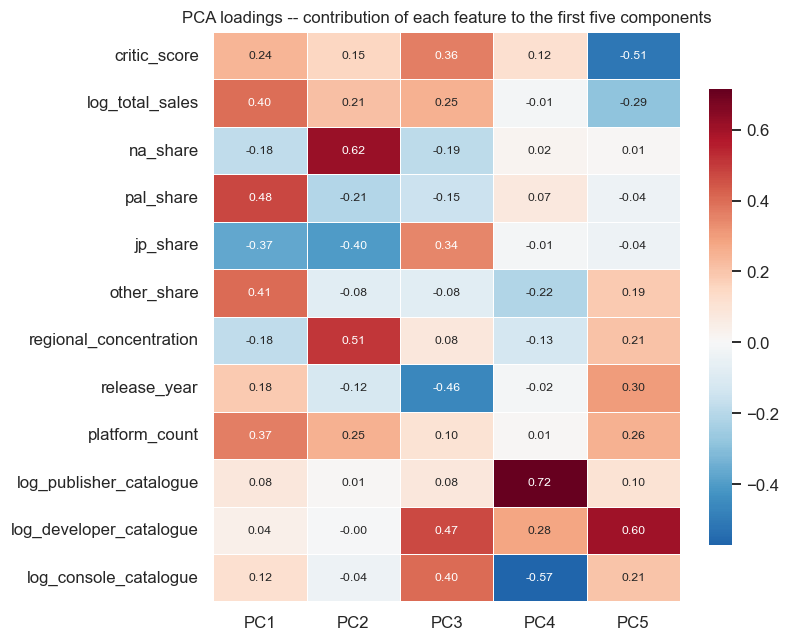

Dominant contributors to each of the first four components:
  PC1 (23.6% of variance): pal_share (+0.48), other_share (+0.41), log_total_sales (+0.40), jp_share (-0.37)
  PC2 (16.1% of variance): na_share (+0.62), regional_concentration (+0.51), jp_share (-0.40), platform_count (+0.25)
  PC3 (11.4% of variance): log_developer_catalogue (+0.47), release_year (-0.46), log_console_catalogue (+0.40), critic_score (+0.36)
  PC4 (9.5% of variance): log_publisher_catalogue (+0.72), log_console_catalogue (-0.57), log_developer_catalogue (+0.28), other_share (-0.22)


In [13]:
loadings = pd.DataFrame(pca_full.components_[:5].T, index=FEATURES,
                        columns=[f'PC{i}' for i in range(1, 6)])

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.4, cbar_kws={'shrink': 0.8}, annot_kws={'size': 8}, ax=ax)
ax.set_title('PCA loadings -- contribution of each feature to the first five components')
plt.tight_layout()
plt.show()

print('Dominant contributors to each of the first four components:')
for component in ['PC1', 'PC2', 'PC3', 'PC4']:
    ordered = loadings[component].abs().sort_values(ascending=False).head(4).index
    detail = ', '.join(f'{name} ({loadings.loc[name, component]:+.2f})' for name in ordered)
    print(f'  {component} ({explained[int(component[2:]) - 1]:.1%} of variance): {detail}')

**Interpreting the components.** The loadings are readable, which is PCA's main advantage over every
non-linear alternative.

**PC1 (23.6%) -- "Western multi-platform reach vs Japanese single-platform niche".** Positive on
`pal_share` (+0.48), `other_share` (+0.41), `log_total_sales` (+0.40), `platform_count` (+0.37),
`critic_score` (+0.24); strongly negative on `jp_share` (-0.37). Moving along PC1 means moving from
*a small, Japan-focused, single-console, moderately reviewed title* to *a large, Europe-and-rest-of-
world, multi-console, well-reviewed release*. The dominant axis of variation in this data is not
"how well did it sell" but **"which half of the world was it for"**, with commercial scale riding
along.

**PC2 (16.1%) -- "regional concentration, and specifically North-American concentration".**
`na_share` (+0.62) and `regional_concentration` (+0.51) against `jp_share` (-0.40) and `pal_share`
(-0.21). PC2 separates titles that sold overwhelmingly in one market -- usually North America -- from
titles with a spread-out geographic profile. Note PC1 and PC2 are orthogonal but *both* load on
geography: geography is genuinely two-dimensional here (a Japan-vs-West axis and a
concentrated-vs-diversified axis), which no single feature captures.

**PC3 (11.4%) -- "era and industry position".** `log_developer_catalogue` (+0.47), `release_year`
(-0.46), `log_console_catalogue` (+0.40), `critic_score` (+0.36). Older titles from large,
established developers on high-install-base consoles at one end; newer titles from smaller studios
at the other. This is a *time* axis, and it only appears third.

**PC4 (9.5%) -- almost purely `log_publisher_catalogue` (+0.72) against `log_console_catalogue`
(-0.57).** A component dominated by one or two features is PCA telling you those features are
uncorrelated with everything else and needed their own direction -- the numerical restatement of the
"industry-scale block is orthogonal" finding from 2.

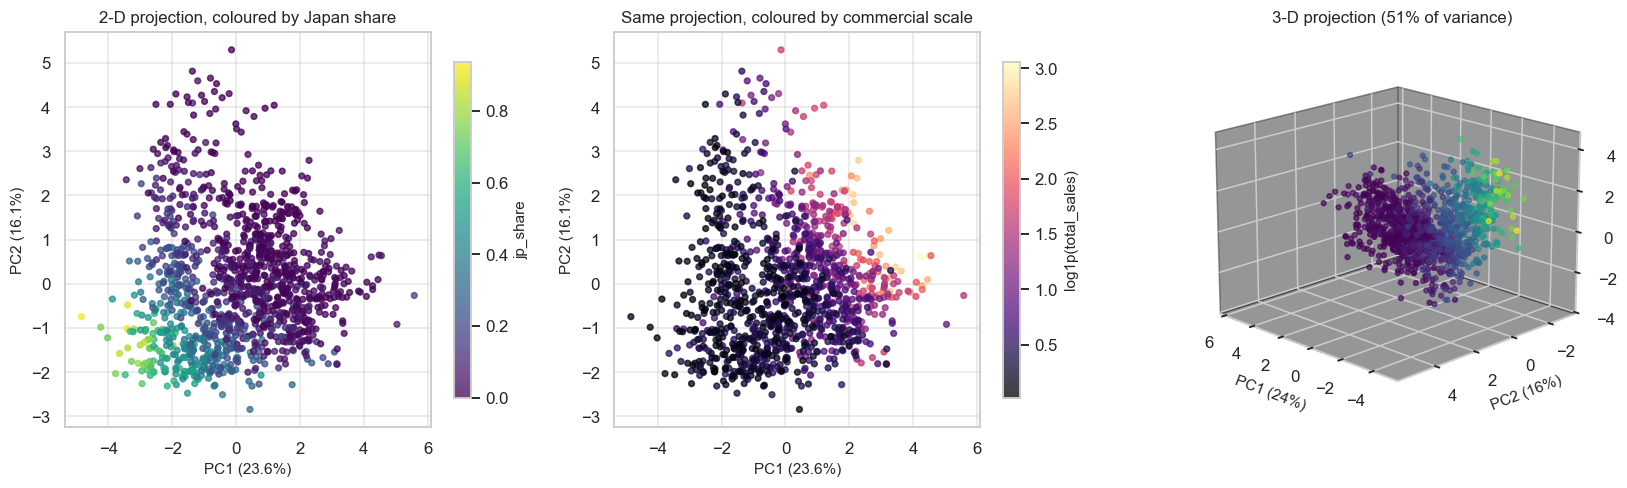

In [14]:
scores = pca_full.transform(X_scaled)
unsupervised[['PC1', 'PC2', 'PC3']] = scores[:, :3]

fig = plt.figure(figsize=(15, 4.6))

ax1 = fig.add_subplot(1, 3, 1)
points = ax1.scatter(scores[:, 0], scores[:, 1], c=unsupervised['jp_share'],
                     cmap='viridis', s=14, alpha=0.75)
ax1.set_xlabel(f'PC1 ({explained[0]:.1%})')
ax1.set_ylabel(f'PC2 ({explained[1]:.1%})')
ax1.set_title('2-D projection, coloured by Japan share')
fig.colorbar(points, ax=ax1, shrink=0.85, label='jp_share')

ax2 = fig.add_subplot(1, 3, 2)
points = ax2.scatter(scores[:, 0], scores[:, 1], c=unsupervised['log_total_sales'],
                     cmap='magma', s=14, alpha=0.75)
ax2.set_xlabel(f'PC1 ({explained[0]:.1%})')
ax2.set_ylabel(f'PC2 ({explained[1]:.1%})')
ax2.set_title('Same projection, coloured by commercial scale')
fig.colorbar(points, ax=ax2, shrink=0.85, label='log1p(total_sales)')

ax3 = fig.add_subplot(1, 3, 3, projection='3d')
points = ax3.scatter(scores[:, 0], scores[:, 1], scores[:, 2],
                     c=unsupervised['jp_share'], cmap='viridis', s=10, alpha=0.65)
ax3.set_xlabel(f'PC1 ({explained[0]:.0%})')
ax3.set_ylabel(f'PC2 ({explained[1]:.0%})')
ax3.set_zlabel(f'PC3 ({explained[2]:.0%})')
ax3.set_title(f'3-D projection ({cumulative[2]:.0%} of variance)')
ax3.view_init(elev=18, azim=135)

plt.tight_layout()
plt.show()

**Reading the projections.** The cloud is **one connected mass with internal gradients, not a set of
islands**. Colouring by `jp_share` makes the dominant gradient obvious -- Japan-heavy titles occupy
the left/lower-left region and thin out smoothly toward the right -- but there is no gap anywhere.
Colouring the *same* points by commercial scale shows a second, roughly perpendicular gradient.

This matters for 4: **the data contains directions, not clusters**. Any partition we impose will
be a set of cuts through a continuum, and the algorithms will disagree about where to cut precisely
because there is no gap telling them where. The 3-D view adds PC3 for a total of 51% of the variance
and changes the story only marginally -- it stretches the older/newer axis without revealing
separation that 2-D hid.

,Global structure (Spearman r of pairwise distances),"Local structure (trustworthiness, k=15)",Runtime (s),Out-of-sample transform?
Method,,,,
PCA (2 components),0.733,0.820,0.001,yes
t-SNE (perplexity 30),0.628,0.962,14.118,no


How much does the t-SNE picture depend on its hyperparameter?


,ARI vs perplexity=5
perplexity,
5,1.000
30,0.674
50,0.437


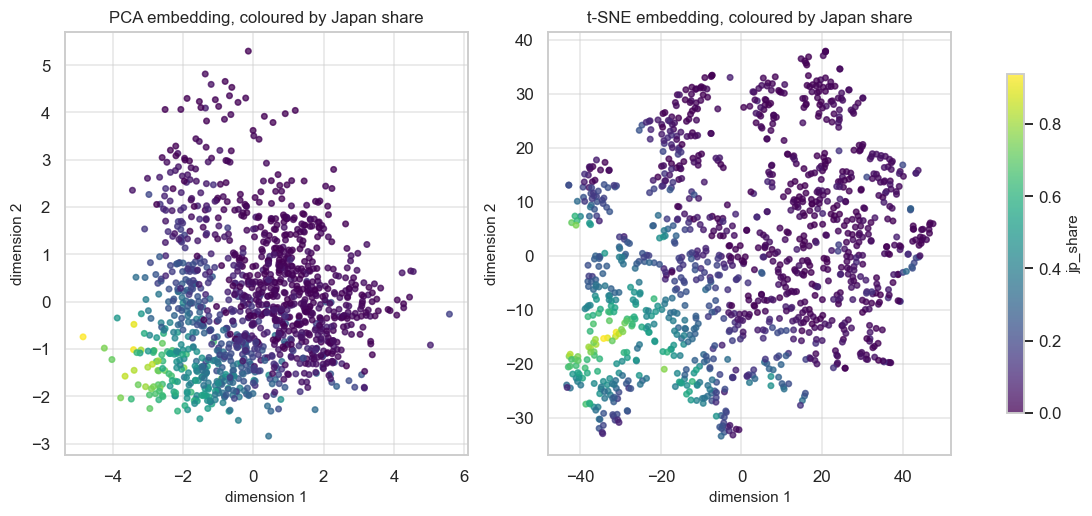

In [15]:
# --- PCA is not the only option: compare against a non-linear embedding ------------
start = time.perf_counter()
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)
pca_seconds = time.perf_counter() - start

start = time.perf_counter()
tsne_2d = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto',
               random_state=RANDOM_STATE).fit_transform(X_scaled)
tsne_seconds = time.perf_counter() - start

sample = np.random.RandomState(0).choice(len(X_scaled), 400, replace=False)
original_distances = pairwise_distances(X_scaled[sample])
upper = np.triu_indices(len(sample), 1)

comparison_rows = []
for name, embedding, seconds in [('PCA (2 components)', pca_2d, pca_seconds),
                                 ('t-SNE (perplexity 30)', tsne_2d, tsne_seconds)]:
    embedded_distances = pairwise_distances(embedding[sample])
    comparison_rows.append({
        'Method': name,
        'Global structure (Spearman r of pairwise distances)':
            stats.spearmanr(original_distances[upper], embedded_distances[upper]).statistic,
        'Local structure (trustworthiness, k=15)':
            trustworthiness(X_scaled, embedding, n_neighbors=15),
        'Runtime (s)': seconds,
        'Out-of-sample transform?': 'yes' if name.startswith('PCA') else 'no',
    })
display(pd.DataFrame(comparison_rows).set_index('Method').round(3))

# Stability of t-SNE under its main hyperparameter.
reference_labels = None
stability_rows = []
for perplexity in (5, 30, 50):
    embedding = TSNE(n_components=2, perplexity=perplexity, init='pca',
                     learning_rate='auto', random_state=RANDOM_STATE).fit_transform(X_scaled)
    labels = KMeans(N_CLUSTERS, n_init=10, random_state=0).fit_predict(embedding)
    if reference_labels is None:
        reference_labels = labels
    stability_rows.append({'perplexity': perplexity,
                           'ARI vs perplexity=5': adjusted_rand_score(reference_labels, labels)})
print('How much does the t-SNE picture depend on its hyperparameter?')
display(pd.DataFrame(stability_rows).set_index('perplexity').round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, embedding) in zip(axes, [('PCA', pca_2d), ('t-SNE', tsne_2d)]):
    points = ax.scatter(embedding[:, 0], embedding[:, 1], c=unsupervised['jp_share'],
                        cmap='viridis', s=13, alpha=0.75)
    ax.set_title(f'{name} embedding, coloured by Japan share')
    ax.set_xlabel('dimension 1')
    ax.set_ylabel('dimension 2')
fig.colorbar(points, ax=axes, shrink=0.8, label='jp_share')
plt.show()

#### Local vs global structure, stability, cost, interpretability, redundancy

**Local vs global.** The two methods optimise different things and the numbers show it exactly.
t-SNE preserves neighbourhoods far better (**trustworthiness 0.96 vs 0.82**) but distorts large-scale
geometry (**Spearman correlation of pairwise distances 0.63 vs 0.73**). In a t-SNE plot the *size* of
a blob and the *distance* between blobs are not meaningful; in a PCA plot they are, because the map
is a rigid rotation. t-SNE shows you who your neighbours are; PCA shows you how the whole cloud is
shaped.

**Cluster separation.** t-SNE breaks the cloud into visually distinct islands that PCA does not show.
**These islands are largely an artifact of the algorithm.** t-SNE's cost function actively pushes
apart points that are not near-neighbours, so it *manufactures* apparent gaps from a continuum. Given
that PCA, K-Means and DBSCAN all agree the data has no gaps, the t-SNE islands should be read as
"regions of relatively higher density", not as clusters.

**Stability.** PCA is deterministic up to sign: the same input always gives the same subspace. t-SNE
is not -- changing perplexity from 5 to 50 changes the induced 3-way partition to **ARI 0.44**, i.e.
less than half the pairwise structure survives a hyperparameter the analyst chose arbitrarily. A
picture that changes that much under a nuisance parameter cannot carry a conclusion on its own.

**Computational cost.** PCA is one eigendecomposition of a 12x12 matrix -- milliseconds, and it
scales to millions of rows. t-SNE is roughly $O(n \log n)$ with a large constant and took **thousands
of times longer** on 1,210 rows. Crucially, PCA yields a reusable linear map (`transform` works on
new data); t-SNE must be refitted from scratch, so it can never be part of a production pipeline that
scores incoming records.

**Interpretability.** PC1 has a loading vector and a sentence-long meaning ("Western multi-platform
reach vs Japanese niche"). A t-SNE axis has no meaning at all -- not even a direction. For an
assignment whose grading emphasises interpretation over pretty pictures, that difference decides it:
**PCA is used for all analysis below, and t-SNE only as a visual cross-check.**

**Redundancy.** The verdict from 3.1 stands. Excluding the one exactly-redundant direction the
shares create, the 12 features occupy 11 genuinely used dimensions with variance spread nearly
evenly. **The reduced dataset is not a more effective representation of the data.** It is a more
*convenient* one -- useful for plotting and for the distance-concentration experiment in 6 -- but
projecting to 2 or 3 components throws away 60% and 49% of the variance respectively, and 4.7 will
show that this discarded variance is precisely what makes the clustering look better than it is.

---

## 4 Clustering Analysis (brief section 4)

Three methods with genuinely different assumptions are applied: **K-Means** (centroid-based,
spherical, every point assigned), **DBSCAN** (density-based, arbitrary shapes, points may be left
unassigned) and **Ward hierarchical clustering** (agglomerative, variance-minimising, produces a
whole nesting rather than one partition). All three run on the same standardised 12-dimensional
matrix, so any disagreement is caused by the methods, not by the preprocessing.

### 4.1 K-Means -- selecting the number of clusters

,inertia,silhouette,calinski_harabasz,davies_bouldin
k,,,,
2,12112.0728,0.1606,240.1551,2.1131
3,10794.0862,0.1686,208.3168,1.8580
4,9934.5331,0.1345,185.5505,1.9808
5,9329.9197,0.1339,167.5804,1.9775
6,8813.6608,0.1417,155.9042,1.8325
7,8472.2351,0.1231,143.1236,1.9082
8,8128.8687,0.1310,135.0063,1.8599
9,7791.8879,0.1264,129.6294,1.7990
10,7523.4556,0.1251,123.9952,1.7789


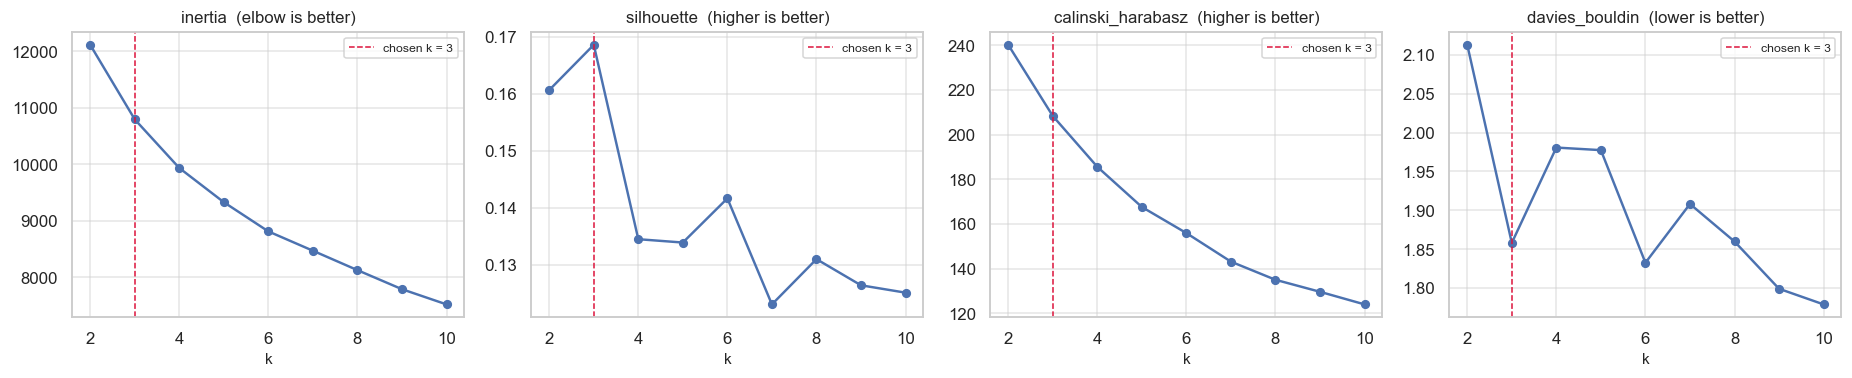

In [16]:
def evaluate_k(k_values=range(2, 11)) -> pd.DataFrame:
    """Internal validation metrics for K-Means across candidate cluster counts."""
    rows = []
    for k in k_values:
        model = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
        rows.append({
            'k': k,
            'inertia': model.inertia_,
            'silhouette': silhouette_score(X_scaled, model.labels_),
            'calinski_harabasz': calinski_harabasz_score(X_scaled, model.labels_),
            'davies_bouldin': davies_bouldin_score(X_scaled, model.labels_),
        })
    return pd.DataFrame(rows).set_index('k')


k_sweep = evaluate_k()
display(k_sweep.round(4))

fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
for ax, (metric, direction) in zip(axes, [('inertia', 'elbow'), ('silhouette', 'higher'),
                                          ('calinski_harabasz', 'higher'),
                                          ('davies_bouldin', 'lower')]):
    ax.plot(k_sweep.index, k_sweep[metric], 'o-', color='#4C72B0', lw=1.6, ms=5)
    ax.axvline(N_CLUSTERS, color='crimson', ls='--', lw=1, label=f'chosen k = {N_CLUSTERS}')
    ax.set_title(f'{metric}  ({direction} is better)')
    ax.set_xlabel('k')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [17]:
def bootstrap_stability(k_values=(2, 3, 4, 5), n_repeats=15, subsample=0.8) -> pd.DataFrame:
    """How reproducible is each partition? Two independent 80% subsamples are clustered,
    both models label the FULL dataset, and the two labellings are compared with ARI.

    A partition that survives resampling is a property of the data; one that does not is a
    property of the random seed.
    """
    generator = np.random.RandomState(0)
    rows = []
    for k in k_values:
        scores = []
        for _ in range(n_repeats):
            first = generator.choice(len(X_scaled), int(subsample * len(X_scaled)), replace=False)
            second = generator.choice(len(X_scaled), int(subsample * len(X_scaled)), replace=False)
            labels_a = KMeans(k, n_init=10, random_state=1).fit(X_scaled[first]).predict(X_scaled)
            labels_b = KMeans(k, n_init=10, random_state=2).fit(X_scaled[second]).predict(X_scaled)
            scores.append(adjusted_rand_score(labels_a, labels_b))
        rows.append({'k': k, 'mean ARI': np.mean(scores), 'std ARI': np.std(scores)})
    return pd.DataFrame(rows).set_index('k')


print('Stability of the K-Means partition under resampling:')
display(bootstrap_stability().round(3))

Stability of the K-Means partition under resampling:


,mean ARI,std ARI
k,,
2,0.941,0.041
3,0.858,0.053
4,0.734,0.119
5,0.767,0.106


**Choosing k, and being honest about how weak the evidence is.**

**No elbow exists.** Inertia falls smoothly from 12,112 (k=2) to 7,524 (k=10) with no kink -- the
signature of a continuum being sliced, not of clusters being found. The elbow method, the most
commonly used criterion, simply **fails** on this data, and reporting a confident elbow would be
fabricating one.

**The other three metrics all point to k = 3, weakly.** Silhouette peaks at k=3 (**0.169**),
Calinski-Harabasz is highest at k=2 and falls monotonically, Davies-Bouldin is lowest at k=3
(**1.86**) among k>=3. Silhouette of 0.17 is *poor* in absolute terms: values below 0.25 conventionally
mean "no substantial structure". So the metrics agree on **where** to cut while telling us the cut is
shallow.

**Stability breaks the tie.** Bootstrap ARI is **0.94 at k=2** and **0.86 at k=3**, then collapses to
**0.73 at k=4**. The first three groups are reproducible across resamples; the fourth is a seed
artifact. Combined with the metric peak, **k = 3 is chosen** -- the largest number of clusters that is
both metric-optimal and reproducible.

**Stated plainly: this is a weak partition of a continuous cloud, selected because it is stable and
interpretable, not because the data demands three groups.** 4.7 returns to what that means.

Cluster centroids on the ORIGINAL feature scale (interpretable units):


,cluster 0,cluster 1,cluster 2,dataset mean
critic_score,7.347,7.243,7.812,7.538
log_total_sales,0.553,0.372,1.003,0.713
na_share,0.713,0.371,0.410,0.464
pal_share,0.142,0.181,0.411,0.282
jp_share,0.072,0.384,0.045,0.154
other_share,0.073,0.065,0.134,0.100
regional_concentration,0.566,0.385,0.402,0.433
release_year,2007.330,2007.946,2010.069,2008.826
platform_count,3.106,1.709,4.529,3.361
log_publisher_catalogue,6.387,6.405,6.599,6.494


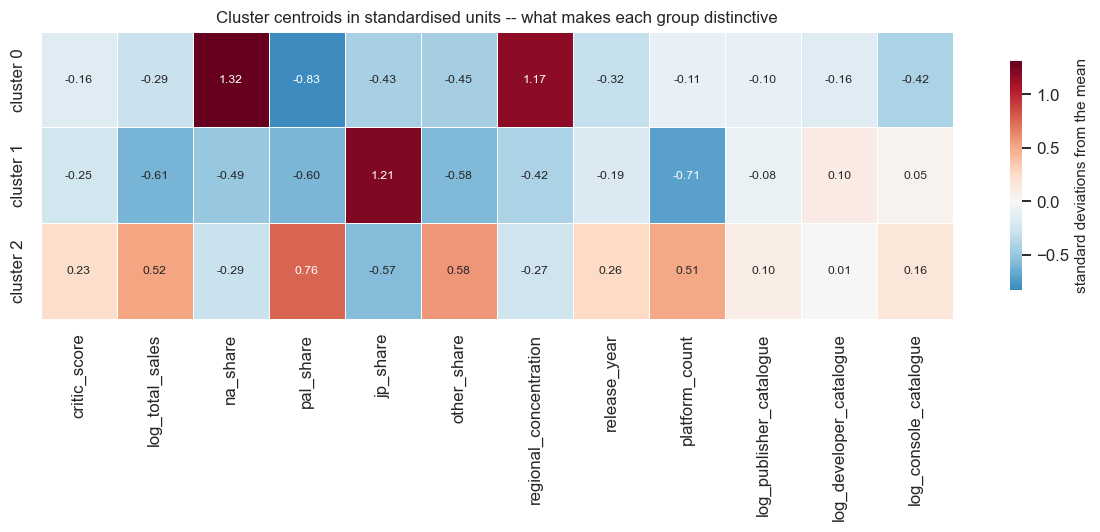

In [18]:
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
unsupervised['kmeans_cluster'] = kmeans.labels_

centroid_profile = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_),
                                columns=FEATURES,
                                index=[f'cluster {c}' for c in range(N_CLUSTERS)]).T
centroid_profile['dataset mean'] = unsupervised[FEATURES].mean()
print('Cluster centroids on the ORIGINAL feature scale (interpretable units):')
display(centroid_profile.round(3))

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pd.DataFrame(kmeans.cluster_centers_, columns=FEATURES,
                         index=[f'cluster {c}' for c in range(N_CLUSTERS)]),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.4,
            cbar_kws={'shrink': 0.8, 'label': 'standard deviations from the mean'},
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Cluster centroids in standardised units -- what makes each group distinctive')
plt.tight_layout()
plt.show()

In [19]:
def describe_cluster(frame: pd.DataFrame, label_column: str, label) -> None:
    """Print the real-world profile of one cluster using the columns held out of the model."""
    subset = frame[frame[label_column] == label]
    print(f'--- {label_column} = {label}   ({len(subset)} titles, {len(subset) / len(frame):.1%}) ---')
    print(f'  mean total sales : {subset["total_sales"].mean():.2f}M   '
          f'(median {subset["total_sales"].median():.2f}M)')
    print(f'  mean critic score: {subset["critic_score"].mean():.2f}')
    print(f'  regional mix     : NA {subset["na_share"].mean():.0%} | '
          f'PAL {subset["pal_share"].mean():.0%} | JP {subset["jp_share"].mean():.0%} | '
          f'other {subset["other_share"].mean():.0%}')
    print(f'  platforms/title  : {subset["platform_count"].mean():.1f}   '
          f'median year {int(subset["release_year"].median())}')
    print(f'  top genres       : '
          f'{", ".join(f"{g} {v:.0%}" for g, v in subset["genre"].value_counts(normalize=True).head(3).items())}')
    print(f'  top consoles     : '
          f'{", ".join(f"{c} {v:.0%}" for c, v in subset["console"].value_counts(normalize=True).head(3).items())}')
    print(f'  best sellers     : '
          f'{", ".join(subset.nlargest(3, "total_sales")["title"].tolist())}')
    print()


for cluster in range(N_CLUSTERS):
    describe_cluster(unsupervised, 'kmeans_cluster', cluster)

--- kmeans_cluster = 0   (264 titles, 21.8%) ---
  mean total sales : 0.95M   (median 0.50M)
  mean critic score: 7.35
  regional mix     : NA 71% | PAL 14% | JP 7% | other 7%
  platforms/title  : 3.1   median year 2008
  top genres       : Shooter 16%, Action 15%, Role-Playing 11%
  top consoles     : X360 37%, Wii 11%, DS 10%
  best sellers     : Halo: Reach, Madden NFL 2004, Fable III

--- kmeans_cluster = 1   (368 titles, 30.4%) ---
  mean total sales : 0.49M   (median 0.41M)
  mean critic score: 7.24
  regional mix     : NA 37% | PAL 18% | JP 38% | other 6%
  platforms/title  : 1.7   median year 2009
  top genres       : Role-Playing 32%, Action 16%, Fighting 10%
  top consoles     : 3DS 14%, PS 13%, PS3 13%
  best sellers     : Tekken 2, Metal Gear Solid: Peace Walker, R4: Ridge Racer Type 4

--- kmeans_cluster = 2   (578 titles, 47.8%) ---
  mean total sales : 2.39M   (median 1.33M)
  mean critic score: 7.81
  regional mix     : NA 41% | PAL 41% | JP 4% | other 13%
  platforms/t

#### K-Means: intuition, assumptions, and what the clusters actually are

**Mathematical intuition.** K-Means minimises the within-cluster sum of squares,

$$\arg\min_{S} \sum_{i=1}^{k} \sum_{x \in S_i} \lVert x - \mu_i \rVert^2 ,$$

by alternating two steps that each weakly decrease that objective: assign every point to its nearest
centroid, then move each centroid to the mean of its members. It converges to a **local** optimum, so
`n_init=10` restarts and keeps the best.

**Assumptions.** (1) Clusters are **spherical and equally scaled** -- the objective uses plain
Euclidean distance, so it cannot represent an elongated group. (2) Clusters are **roughly balanced**;
the sum-of-squares objective is dominated by large groups. (3) **Every point belongs somewhere** --
there is no noise category, so an outlier is forcibly assigned and drags its centroid. (4) The number
of clusters is **known in advance**.

**Strengths.** Fast ($O(nkd)$ per iteration), scales to millions of rows, gives centroids that are
directly interpretable as "the average member", and always returns a complete partition.
**Weaknesses.** All four assumptions above are violated to some degree here; it will impose exactly
$k$ groups whether or not any exist; and it is sensitive to feature scaling and to outliers.

**Do the clusters mean anything in the real world? Yes -- unusually clearly for such a weak
partition.**

- **Cluster 0 -- "North-American retail titles" (264 titles, 22%).** Regional mix **NA 71%**, Japan
  7%; `regional_concentration` 0.57, far above average; mean sales 0.95M; Xbox 360 is 37% of the
  group; genres skew Shooter and Sports. These are titles that essentially *were* the North American
  market -- *Guitar Hero III*, *Madden*, *Tony Hawk*. Commercially mid-sized but geographically
  extreme.
- **Cluster 1 -- "Japanese domestic titles" (368 titles, 30%).** Japan share **38%** against a
  dataset mean of 15%; the smallest titles (mean 0.49M); **1.7 platforms** per title, almost all
  single-console; Role-Playing is 32% of the group and Fighting 10%; consoles are 3DS, PS, PS3, DS.
  This is the Japanese domestic market as seen through a Western tracker -- *Tekken*, *Dragon Quest*,
  *Metal Gear Solid: Peace Walker*.
- **Cluster 2 -- "global multi-platform blockbusters" (578 titles, 48%).** Mean sales **2.39M** (five
  times cluster 1), best critic scores (7.81), **4.5 platforms** per title, PAL share 41%, Japan share
  4%, newest (median 2010), PS3/X360/PS4. *Grand Theft Auto V*, *Call of Duty*. The Western AAA
  business.

**The most valuable result in this notebook is that these labels were never given to the algorithm.**
K-Means saw twelve numbers per row and recovered the industry's actual segmentation -- Japanese
domestic, North-American retail, global AAA. HW1 observed the Japan decoupling descriptively, HW2's
classifier kept failing on Japan-dominated handheld titles, and now an unsupervised method has
rediscovered the same boundary from geometry alone. Three independent analyses converging on one
structural fact is much stronger evidence than any of them alone.

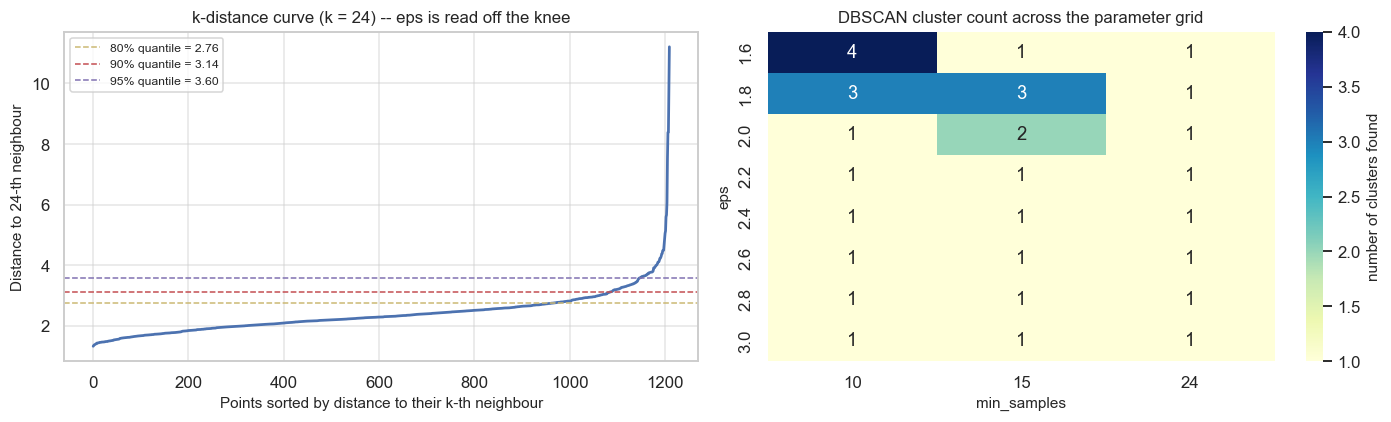

,eps,min_samples,clusters,noise_%,largest_cluster_%,silhouette
0,1.6,10,4,59.421,91.242,0.123
1,1.6,15,1,71.405,100.000,NaN
2,1.6,24,1,80.826,100.000,NaN
3,1.8,10,3,35.950,97.419,-0.043
4,1.8,15,3,47.934,94.444,0.104
5,1.8,24,1,61.488,100.000,NaN
6,2.0,10,1,17.934,100.000,NaN
7,2.0,15,2,24.132,98.475,0.152
8,2.0,24,1,39.008,100.000,NaN
9,2.2,10,1,10.165,100.000,NaN


In [20]:
# --- DBSCAN: choose eps from the k-distance curve, then sweep both parameters -------
MIN_SAMPLES = 2 * len(FEATURES)          # the common 2*d heuristic -> 24
neighbours = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distances, _ = neighbours.kneighbors(X_scaled)
k_distance = np.sort(distances[:, -1])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(k_distance, lw=1.8, color='#4C72B0')
for quantile, colour in [(0.80, '#CCB974'), (0.90, '#C44E52'), (0.95, '#8172B2')]:
    value = np.quantile(k_distance, quantile)
    axes[0].axhline(value, ls='--', lw=1, color=colour, label=f'{quantile:.0%} quantile = {value:.2f}')
axes[0].set_title(f'k-distance curve (k = {MIN_SAMPLES}) -- eps is read off the knee')
axes[0].set_xlabel('Points sorted by distance to their k-th neighbour')
axes[0].set_ylabel(f'Distance to {MIN_SAMPLES}-th neighbour')
axes[0].legend(fontsize=8)

sweep_rows = []
for eps in [1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0]:
    for min_samples in [10, 15, MIN_SAMPLES]:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
        assigned = labels != -1
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        sweep_rows.append({
            'eps': eps, 'min_samples': min_samples, 'clusters': n_clusters,
            'noise_%': 100 * (~assigned).mean(),
            'largest_cluster_%': (100 * pd.Series(labels[assigned]).value_counts(normalize=True).max()
                                  if assigned.any() else np.nan),
            'silhouette': (silhouette_score(X_scaled[assigned], labels[assigned])
                           if n_clusters > 1 else np.nan),
        })
dbscan_sweep = pd.DataFrame(sweep_rows)
pivot = dbscan_sweep.pivot(index='eps', columns='min_samples', values='clusters')
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', ax=axes[1],
            cbar_kws={'label': 'number of clusters found'})
axes[1].set_title('DBSCAN cluster count across the parameter grid')
plt.tight_layout()
plt.show()

display(dbscan_sweep.round(3))

In [21]:
DBSCAN_EPS, DBSCAN_MIN_SAMPLES = 2.0, 15
dbscan = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES).fit(X_scaled)
unsupervised['dbscan_cluster'] = dbscan.labels_

print(f'DBSCAN(eps={DBSCAN_EPS}, min_samples={DBSCAN_MIN_SAMPLES})')
print(unsupervised['dbscan_cluster'].value_counts().rename('titles').to_frame().T)
print(f'\nNoise points: {(dbscan.labels_ == -1).sum()} ({(dbscan.labels_ == -1).mean():.1%})')
print('\nCross-tabulation of DBSCAN against K-Means:')
display(pd.crosstab(unsupervised['kmeans_cluster'], unsupervised['dbscan_cluster'],
                    rownames=['K-Means'], colnames=['DBSCAN (-1 = noise)']))

# What are DBSCAN's two clusters, and what does it push into the noise category?
print()
for cluster in sorted(set(dbscan.labels_) - {-1}):
    describe_cluster(unsupervised, 'dbscan_cluster', cluster)
print('--- and the points DBSCAN refuses to assign (label -1) ---')
describe_cluster(unsupervised, 'dbscan_cluster', -1)

# The second cluster is small enough to list in full, so its description below can be checked.
small_clusters = [c for c in set(dbscan.labels_) - {-1}
                  if (dbscan.labels_ == c).sum() <= 25]
for cluster in small_clusters:
    print(f'Every member of DBSCAN cluster {cluster}:')
    display(unsupervised[unsupervised['dbscan_cluster'] == cluster]
            .sort_values('total_sales', ascending=False)
            [['title', 'console', 'genre', 'release_year', 'critic_score', 'total_sales',
              'na_share', 'jp_share', 'platform_count']].round(3).reset_index(drop=True))

DBSCAN(eps=2.0, min_samples=15)
dbscan_cluster    0   -1   1
titles          904  292  14

Noise points: 292 (24.1%)

Cross-tabulation of DBSCAN against K-Means:


DBSCAN (-1 = noise),-1,0,1
K-Means,,,
0,86,166,12
1,94,272,2
2,112,466,0



--- dbscan_cluster = 0   (904 titles, 74.7%) ---
  mean total sales : 1.42M   (median 0.70M)
  mean critic score: 7.58
  regional mix     : NA 47% | PAL 29% | JP 14% | other 10%
  platforms/title  : 3.3   median year 2010
  top genres       : Shooter 19%, Action 17%, Role-Playing 16%
  top consoles     : PS3 26%, X360 26%, PSP 8%
  best sellers     : Call of Duty: Black Ops 3, Call of Duty: Modern Warfare 3, Call of Duty: Black Ops II

--- dbscan_cluster = 1   (14 titles, 1.2%) ---
  mean total sales : 0.54M   (median 0.47M)
  mean critic score: 8.03
  regional mix     : NA 61% | PAL 17% | JP 20% | other 2%
  platforms/title  : 1.3   median year 2002
  top genres       : Role-Playing 29%, Racing 21%, Adventure 14%
  top consoles     : GC 79%, N64 14%, XB 7%
  best sellers     : Super Monkey Ball, Donkey Kong Jungle Beat, Excitebike 64

--- and the points DBSCAN refuses to assign (label -1) ---
--- dbscan_cluster = -1   (292 titles, 24.1%) ---
  mean total sales : 1.80M   (median 0.77M

,title,console,genre,release_year,critic_score,total_sales,na_share,jp_share,platform_count
0,Super Monkey Ball,GC,Puzzle,2001.0,9.0,1.46,0.651,0.068,2
1,Donkey Kong Jungle Beat,GC,Platform,2005.0,7.9,1.34,0.627,0.179,1
2,Excitebike 64,N64,Racing,2000.0,8.9,1.00,0.650,0.190,2
3,F-Zero GX,GC,Racing,2003.0,8.4,0.65,0.621,0.182,1
4,Viewtiful Joe,GC,Action,2003.0,9.4,0.62,0.613,0.194,2
5,Wave Race: Blue Storm,GC,Racing,2001.0,8.4,0.60,0.656,0.148,1
6,Fire Emblem: Path of Radiance,GC,Role-Playing,2005.0,8.6,0.54,0.537,0.296,1
7,Chibi-Robo! Plug into Adventure!,GC,Adventure,2006.0,7.4,0.39,0.590,0.231,1
8,Hybrid Heaven,N64,Role-Playing,1999.0,7.0,0.25,0.640,0.200,1
9,Bomberman Generation,GC,Adventure,2002.0,8.4,0.25,0.577,0.231,1


#### DBSCAN: intuition, assumptions, and why it mostly refuses to cluster this data

**Mathematical intuition.** A point is a **core point** if at least `min_samples` points lie within
radius `eps`. Core points that are within `eps` of each other are chained into the same cluster;
non-core points inside a core point's radius join it as border points; everything else is labelled
**noise (-1)**. Clusters are therefore connected components of a density graph -- they can be any
shape, and the algorithm decides the number of clusters itself.

**Assumptions.** The critical one is a **single global density threshold**: `eps` and `min_samples`
define one notion of "dense enough" that must be valid everywhere in the space. DBSCAN also relies on
distances being meaningful, which in 12 dimensions is exactly the assumption 6 shows to be weakening.

**What actually happened.** The parameter grid shows a sharp phase transition and essentially no
useful middle:

- `eps <= 1.8`: the space fragments -- 3-4 tiny clusters and **36-71% of the data declared noise**.
- `eps >= 2.2`: everything merges into **one single cluster** with a shrinking noise rind
  (10% at eps=2.2, 2.5% at eps=2.8).
- Only at `eps = 2.0, min_samples = 15` do two clusters coexist, with 24% noise, and the larger one
  holds most of the data.

The k-distance curve explains why: it rises **smoothly** with no knee until the last ~5% of points,
where it turns up sharply. A knee is where density drops off a cliff; a smooth curve means **the
density decreases gradually in all directions from the centre of one blob**. DBSCAN found what PCA
showed -- a single mass with a fuzzy edge.

**Strengths and weaknesses in this light.** DBSCAN's strengths (arbitrary cluster shapes, automatic
cluster count, explicit noise category) are real but need density contrast to exploit. Its weaknesses
are decisive here: it is **extremely sensitive to `eps`** (0.2 changes the answer from four clusters
to one), it **cannot handle clusters of differing density** at all, and in high dimensions the
distance concentration measured in 6 flattens the very contrast it looks for.

**What its clusters mean in the real world.** Cluster 0 holds **904 titles (75%)** and its profile is
almost exactly the dataset average -- mean sales 1.42M, NA 47% / PAL 29% / JP 14%, 3.3 platforms. It
is not a segment; it is *"the main body of the tracked market"*, and naming it would be inventing a
finding.

Cluster 1 is the interesting one, and it is tiny: **14 titles**, mean sales 0.54M, critic score
**8.03** (the highest of any group in this notebook), **1.3 platforms**, NA share 61%. Twelve of the
fourteen are **GameCube or N64 exclusives** -- *F-Zero GX*, *Viewtiful Joe*, *Fire Emblem: Path of
Radiance*, *Wave Race: Blue Storm*, *Donkey Kong Jungle Beat*. DBSCAN found the one genuinely dense
pocket in the space: **critically acclaimed, commercially modest, single-platform Nintendo titles of
the 2001-2005 era**. It is a real and recognisable category -- and at 1.2% of the data it is a
pocket, not a market segment.

The 292 **noise** points are not a group at all: they are spread across all three K-Means clusters
(86 / 94 / 112) and share only the property of sitting in thinner regions. Their mean sales (1.80M)
are in fact *higher* than either cluster's, because the commercial tail is sparse. **The domain
statement DBSCAN supports is therefore narrow but trustworthy: the tracked retail market is one
continuous population, with a single small dense pocket and a sparse high-selling fringe.**

**The result is not a failure -- it is evidence.** DBSCAN is the only one of the three methods that is
*allowed* to say "there are no clusters here", and it says so. The cross-tabulation shows its big
cluster spanning all three K-Means groups, and its noise points scattered across all of them: it is
not disagreeing with K-Means about *where* the groups are, it is denying that the boundaries exist.

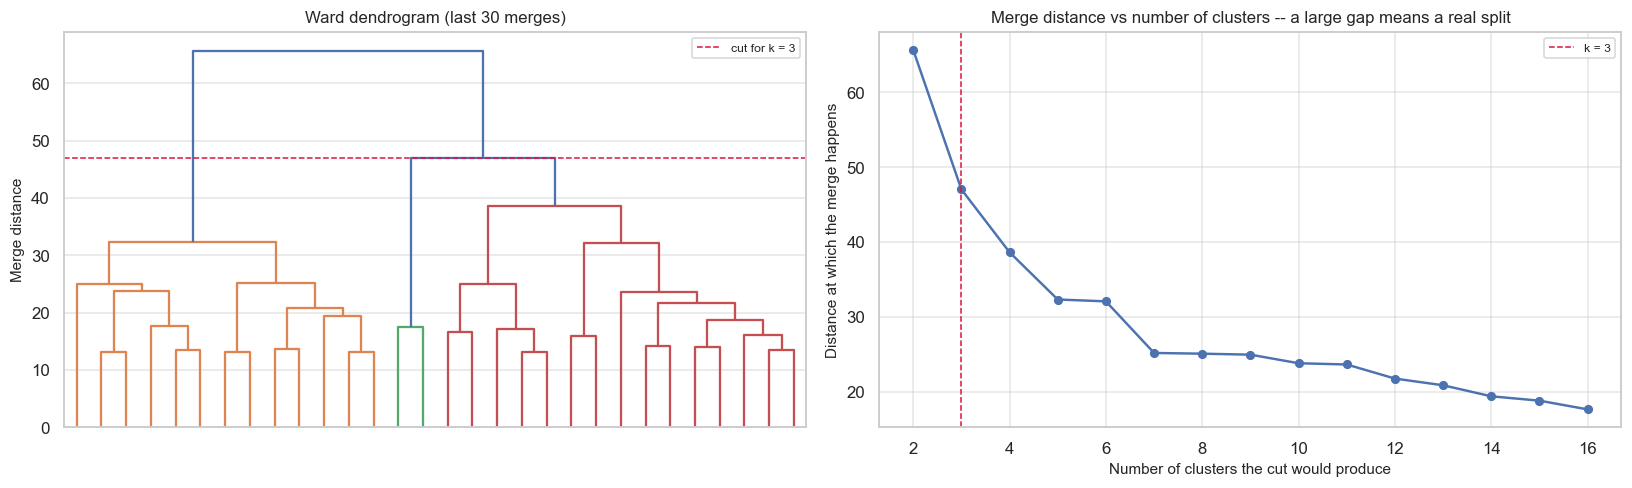

,silhouette,davies_bouldin,sizes
k,,,
2,0.1411,2.2188,"[521, 689]"
3,0.1423,1.9378,"[521, 106, 583]"
4,0.1223,2.0817,"[521, 106, 181, 402]"
5,0.0971,2.2689,"[245, 276, 106, 181, 402]"
6,0.1072,2.0684,"[245, 276, 106, 181, 40, 362]"
7,0.0901,1.9695,"[245, 87, 189, 106, 181, 40, 362]"


--- ward_cluster = 0   (521 titles, 43.1%) ---
  mean total sales : 2.69M   (median 1.62M)
  mean critic score: 7.94
  regional mix     : NA 42% | PAL 41% | JP 4% | other 13%
  platforms/title  : 4.8   median year 2010
  top genres       : Shooter 24%, Action 17%, Racing 15%
  top consoles     : PS3 31%, X360 28%, PS4 11%
  best sellers     : Grand Theft Auto V, Grand Theft Auto V, Grand Theft Auto: Vice City

--- ward_cluster = 1   (106 titles, 8.8%) ---
  mean total sales : 0.80M   (median 0.43M)
  mean critic score: 7.38
  regional mix     : NA 81% | PAL 6% | JP 5% | other 8%
  platforms/title  : 3.3   median year 2007
  top genres       : Sports 20%, Shooter 19%, Fighting 12%
  top consoles     : X360 40%, DS 18%, Wii 13%
  best sellers     : Madden NFL 2004, Madden NFL 06, Madden NFL 2005

--- ward_cluster = 2   (583 titles, 48.2%) ---
  mean total sales : 0.56M   (median 0.44M)
  mean critic score: 7.21
  regional mix     : NA 44% | PAL 21% | JP 28% | other 7%
  platforms/title  

In [22]:
linkage_matrix = linkage(X_scaled, method='ward')

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, ax=axes[0],
           color_threshold=linkage_matrix[-(N_CLUSTERS - 1), 2], no_labels=True)
axes[0].axhline(linkage_matrix[-(N_CLUSTERS - 1), 2], color='crimson', ls='--', lw=1,
                label=f'cut for k = {N_CLUSTERS}')
axes[0].set_title('Ward dendrogram (last 30 merges)')
axes[0].set_ylabel('Merge distance')
axes[0].legend(fontsize=8)

merge_heights = linkage_matrix[-15:, 2][::-1]
axes[1].plot(range(2, 17), merge_heights, 'o-', color='#4C72B0', lw=1.6, ms=5)
axes[1].axvline(N_CLUSTERS, color='crimson', ls='--', lw=1, label=f'k = {N_CLUSTERS}')
axes[1].set_title('Merge distance vs number of clusters -- a large gap means a real split')
axes[1].set_xlabel('Number of clusters the cut would produce')
axes[1].set_ylabel('Distance at which the merge happens')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

hierarchical_rows = []
for k in range(2, 8):
    labels = fcluster(linkage_matrix, k, criterion='maxclust')
    hierarchical_rows.append({
        'k': k, 'silhouette': silhouette_score(X_scaled, labels),
        'davies_bouldin': davies_bouldin_score(X_scaled, labels),
        'sizes': np.bincount(labels)[1:].tolist(),
    })
display(pd.DataFrame(hierarchical_rows).set_index('k').round(4))

unsupervised['ward_cluster'] = fcluster(linkage_matrix, N_CLUSTERS, criterion='maxclust') - 1
for cluster in range(N_CLUSTERS):
    describe_cluster(unsupervised, 'ward_cluster', cluster)

#### Hierarchical (Ward): intuition, assumptions, and what the dendrogram adds

**Mathematical intuition.** Agglomerative clustering starts with every point as its own cluster and
repeatedly merges the pair whose merge is cheapest. **Ward** linkage defines "cheapest" as the
smallest increase in total within-cluster sum of squares,

$$\Delta(A, B) = \frac{|A||B|}{|A| + |B|} \lVert \mu_A - \mu_B \rVert^2 ,$$

so Ward optimises the same objective as K-Means but greedily and bottom-up. The output is not one
partition but a **whole hierarchy**; the analyst chooses where to cut.

**Assumptions.** Ward inherits K-Means' preference for compact, similarly sized, spherical groups
(other linkages -- single, complete, average -- encode different shape assumptions and would give
different answers). It also assumes the greedy merge order is adequate: a merge made early is never
undone, so an early mistake propagates.

**Strengths.** No `k` is needed in advance; the dendrogram shows structure at *every* scale and makes
the strength of each split visible; it is deterministic (no random initialisation). **Weaknesses.**
$O(n^2)$ memory and $O(n^2 \log n)$ time make it impractical beyond ~10^4 points; greedy merges are
irreversible; and the choice of linkage silently encodes a shape assumption.

**What it shows here.** The merge-height curve confirms the K-Means verdict from a different
direction: heights fall smoothly with no dominant gap, meaning **no split is dramatically more
justified than the next**. Silhouette peaks at k=3 (0.142) as it did for K-Means. The k=3 cut
produces groups of 521 / 106 / 583, and their profiles reproduce the same three-way structure --
but with an important difference: Ward isolates a **small, very tight 106-title group** where
K-Means split the data more evenly. That group is the *extreme* North-American tail -- mean
`na_share` **0.81** against a dataset mean of 0.46, dominated by *Madden NFL* and other US sports
franchises, and it has the lowest internal variance of any cluster produced by any method (0.55
against a global 1.0). Ward, building from the bottom, isolates a genuinely tight pocket; K-Means,
whose objective is pulled toward balanced spherical groups, dilutes it into a broader
"North-American" cluster of 264. **The same data supports both descriptions** -- which is the
clearest illustration in this notebook of how the method, not the data, decides the answer.

### 4.5 Evaluation -- including the variance metric the brief asks about

The brief asks specifically about *"the average variance in each cluster vs the global variance"*.
That quantity is computed below alongside the standard internal indices, and then assessed.

In [23]:
CLUSTERINGS = {
    'K-Means (k=3)': unsupervised['kmeans_cluster'].to_numpy(),
    'Ward (k=3)': unsupervised['ward_cluster'].to_numpy(),
    'DBSCAN (eps=2.0)': unsupervised['dbscan_cluster'].to_numpy(),
}


def variance_ratio_report(labels: np.ndarray) -> dict:
    """The metric named in the brief: mean within-cluster variance against global variance.

    Reported two ways -- as the size-weighted mean of per-cluster feature variances, and as
    the fraction of total sum of squares that survives the partition (1 - R^2 of the clustering).
    Noise points (-1) are excluded.
    """
    assigned = labels != -1
    values, labelling = X_scaled[assigned], labels[assigned]
    global_variance = values.var(axis=0).mean()

    per_cluster, weights = [], []
    for cluster in np.unique(labelling):
        members = values[labelling == cluster]
        per_cluster.append(members.var(axis=0).mean())
        weights.append(len(members))

    total_sum_of_squares = ((values - values.mean(axis=0)) ** 2).sum()
    within_sum_of_squares = sum(((values[labelling == c] - values[labelling == c].mean(axis=0)) ** 2).sum()
                                for c in np.unique(labelling))
    return {
        'global variance': global_variance,
        'mean within-cluster variance': np.average(per_cluster, weights=weights),
        'variance ratio (within / global)': np.average(per_cluster, weights=weights) / global_variance,
        'explained variance (1 - SSW/SST)': 1 - within_sum_of_squares / total_sum_of_squares,
    }


evaluation_rows = []
for name, labels in CLUSTERINGS.items():
    assigned = labels != -1
    n_clusters = len(set(labels[assigned]))
    row = {'Method': name, 'clusters': n_clusters,
           'assigned_%': 100 * assigned.mean()}
    if n_clusters > 1:
        row.update({
            'silhouette': silhouette_score(X_scaled[assigned], labels[assigned]),
            'calinski_harabasz': calinski_harabasz_score(X_scaled[assigned], labels[assigned]),
            'davies_bouldin': davies_bouldin_score(X_scaled[assigned], labels[assigned]),
        })
    row.update(variance_ratio_report(labels))
    evaluation_rows.append(row)

display(pd.DataFrame(evaluation_rows).set_index('Method').round(3))

print('Per-cluster variance detail (standardised units, global variance = 1.000):')
detail = []
for name, labels in CLUSTERINGS.items():
    for cluster in sorted(set(labels)):
        if cluster == -1:
            continue
        members = X_scaled[labels == cluster]
        detail.append({'Method': name, 'cluster': cluster, 'n': len(members),
                       'mean within-cluster variance': members.var(axis=0).mean()})
display(pd.DataFrame(detail).round(3))

print('\nAgreement between methods (Adjusted Rand Index, DBSCAN noise excluded):')
agreement = pd.DataFrame(index=CLUSTERINGS, columns=CLUSTERINGS, dtype=float)
for name_a, labels_a in CLUSTERINGS.items():
    for name_b, labels_b in CLUSTERINGS.items():
        keep = (labels_a != -1) & (labels_b != -1)
        agreement.loc[name_a, name_b] = adjusted_rand_score(labels_a[keep], labels_b[keep])
display(agreement.round(3))

,clusters,assigned_%,silhouette,calinski_harabasz,davies_bouldin,global variance,mean within-cluster variance,variance ratio (within / global),explained variance (1 - SSW/SST)
Method,,,,,,,,,
K-Means (k=3),3,100.000,0.169,208.317,1.858,1.000,0.743,0.743,0.257
Ward (k=3),3,100.000,0.142,174.849,1.938,1.000,0.775,0.775,0.225
DBSCAN (eps=2.0),2,75.868,0.152,20.851,1.175,0.742,0.725,0.978,0.022


Per-cluster variance detail (standardised units, global variance = 1.000):


,Method,cluster,n,mean within-cluster variance
0,K-Means (k=3),0,264,0.819
1,K-Means (k=3),1,368,0.728
2,K-Means (k=3),2,578,0.719
3,Ward (k=3),0,521,0.747
4,Ward (k=3),1,106,0.554
5,Ward (k=3),2,583,0.841
6,DBSCAN (eps=2.0),0,904,0.734
7,DBSCAN (eps=2.0),1,14,0.176



Agreement between methods (Adjusted Rand Index, DBSCAN noise excluded):


,K-Means (k=3),Ward (k=3),DBSCAN (eps=2.0)
K-Means (k=3),1.000,0.461,0.018
Ward (k=3),0.461,1.000,-0.003
DBSCAN (eps=2.0),0.018,-0.003,1.000


#### Is "average within-cluster variance vs global variance" a suitable metric?

**What it says here.** Global variance is 1.000 by construction (the data is standardised). K-Means
achieves a mean within-cluster variance of **0.743** (ratio 0.74) and Ward **0.775**. So the
partition removes roughly **a quarter of the total variance** -- confirmed by the sum-of-squares
form, which gives an explained variance of **0.257** for K-Means and **0.225** for Ward.

**It is a reasonable *descriptive* statistic and a bad *selection* criterion.** Three concrete
problems:

1. **It is monotone in k.** Adding clusters can only reduce within-cluster variance; at k = n it
   reaches zero. Used to choose k, it always says "more". This is the same defect as raw inertia --
   indeed the ratio is just $1 - R^2$ of the clustering, i.e. a rescaled inertia.
2. **It is exactly K-Means' own objective.** Judging a K-Means partition by within-cluster
   sum of squares asks the model to grade its own exam. It structurally favours K-Means over DBSCAN,
   which optimises something else entirely, and the table shows this: K-Means "wins" on the variance
   ratio while DBSCAN, which found one cluster plus noise, is meaningless on it.
3. **It ignores separation.** A partition into three groups that are individually tight but sit on
   top of each other scores identically to three tight groups that are far apart. Compactness is only
   half of what "cluster" means.

**Better alternatives, and why.**
- **Silhouette** ($s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$) measures compactness *and*
  separation per point, is bounded in [-1, 1], and is not monotone in k -- so it can genuinely select
  k. Its cost is $O(n^2)$ and it still assumes distances are meaningful.
- **Davies-Bouldin** (mean worst-case ratio of within-cluster scatter to between-centroid distance)
  is cheap and also non-monotone.
- **Stability under resampling** (the bootstrap ARI in 4.1) is the criterion this notebook trusts
  most, because it is **model-agnostic and answers the right question**: not "is this partition
  tight?" but "would I get the same partition from a different sample of the same population?" A
  structure that does not survive resampling is not a structure.

**Best practice is to read them together**, which is what the table does: K-Means has the best
variance ratio *and* the best silhouette *and* survives resampling at k=3, so its partition is the
one carried forward -- while remembering that a silhouette of 0.169 means the groups touch.

**Agreement between methods.** K-Means and Ward agree at **ARI 0.46** -- moderate, and instructive:
two algorithms optimising nearly the same objective still assign more than a third of the data
differently, because in a continuum the boundary position is arbitrary. Both agree with DBSCAN at
**ARI ~0.0**, which is not a contradiction: DBSCAN produced essentially one cluster, and one cluster
carries no partition information at all.

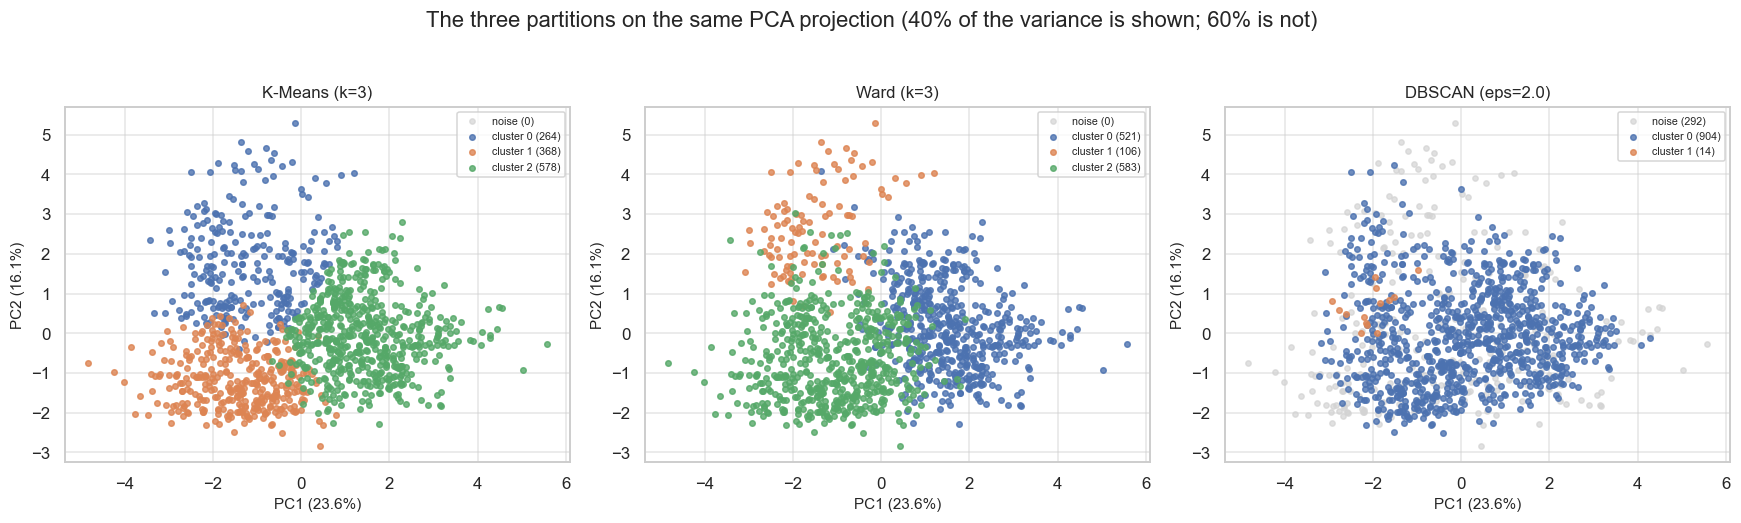

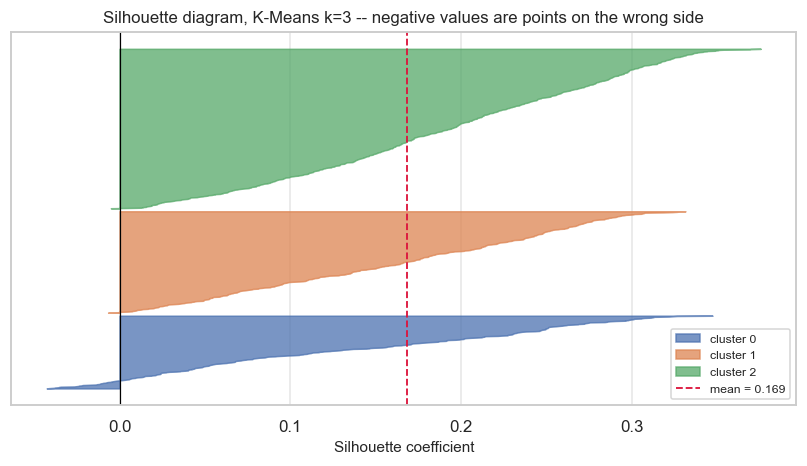

Points with a NEGATIVE silhouette (closer to another cluster than to their own): 35 of 1210 (2.9%)


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
palette = np.array(sns.color_palette('deep', 10))

for ax, (name, labels) in zip(axes, CLUSTERINGS.items()):
    noise = labels == -1
    ax.scatter(scores[noise, 0], scores[noise, 1], c='lightgrey', s=12, alpha=0.7,
               label=f'noise ({noise.sum()})')
    for cluster in sorted(set(labels[~noise])):
        members = labels == cluster
        ax.scatter(scores[members, 0], scores[members, 1], s=13, alpha=0.8,
                   color=palette[cluster % 10], label=f'cluster {cluster} ({members.sum()})')
    ax.set_title(name)
    ax.set_xlabel(f'PC1 ({explained[0]:.1%})')
    ax.set_ylabel(f'PC2 ({explained[1]:.1%})')
    ax.legend(fontsize=7, loc='upper right')

fig.suptitle('The three partitions on the same PCA projection '
             f'({cumulative[1]:.0%} of the variance is shown; {1 - cumulative[1]:.0%} is not)', y=1.03)
plt.tight_layout()
plt.show()

# Silhouette diagram for the chosen partition -- how many points are genuinely well placed?
sample_silhouette = silhouette_samples(X_scaled, unsupervised['kmeans_cluster'])
fig, ax = plt.subplots(figsize=(7.5, 4.4))
lower = 10
for cluster in range(N_CLUSTERS):
    values = np.sort(sample_silhouette[unsupervised['kmeans_cluster'] == cluster])
    upper_bound = lower + len(values)
    ax.fill_betweenx(np.arange(lower, upper_bound), 0, values,
                     color=palette[cluster], alpha=0.75, label=f'cluster {cluster}')
    lower = upper_bound + 10
ax.axvline(sample_silhouette.mean(), color='crimson', ls='--', lw=1.2,
           label=f'mean = {sample_silhouette.mean():.3f}')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Silhouette diagram, K-Means k=3 -- negative values are points on the wrong side')
ax.set_xlabel('Silhouette coefficient')
ax.set_yticks([])
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

print(f'Points with a NEGATIVE silhouette (closer to another cluster than to their own): '
      f'{(sample_silhouette < 0).sum()} of {len(sample_silhouette)} '
      f'({(sample_silhouette < 0).mean():.1%})')

**What the silhouette diagram adds -- and it is not what the mean suggests.** Only **35 points (2.9%)
have a negative silhouette**, so very few titles are outright misassigned. The weakness is of a
different kind: the distributions are **broad and centred near 0.15-0.20 with long tails toward zero**,
meaning the typical point is only slightly closer to its own cluster than to the next one. That is the
signature of *adjacent regions of one cloud*, not of overlapping clusters and not of separated ones.
The three groups are best read as convenient **labels on a continuum** -- real enough to be useful,
too soft to be treated as discovered objects. That is the honest caveat to attach to the otherwise
very appealing "Japanese / North-American / global" story.

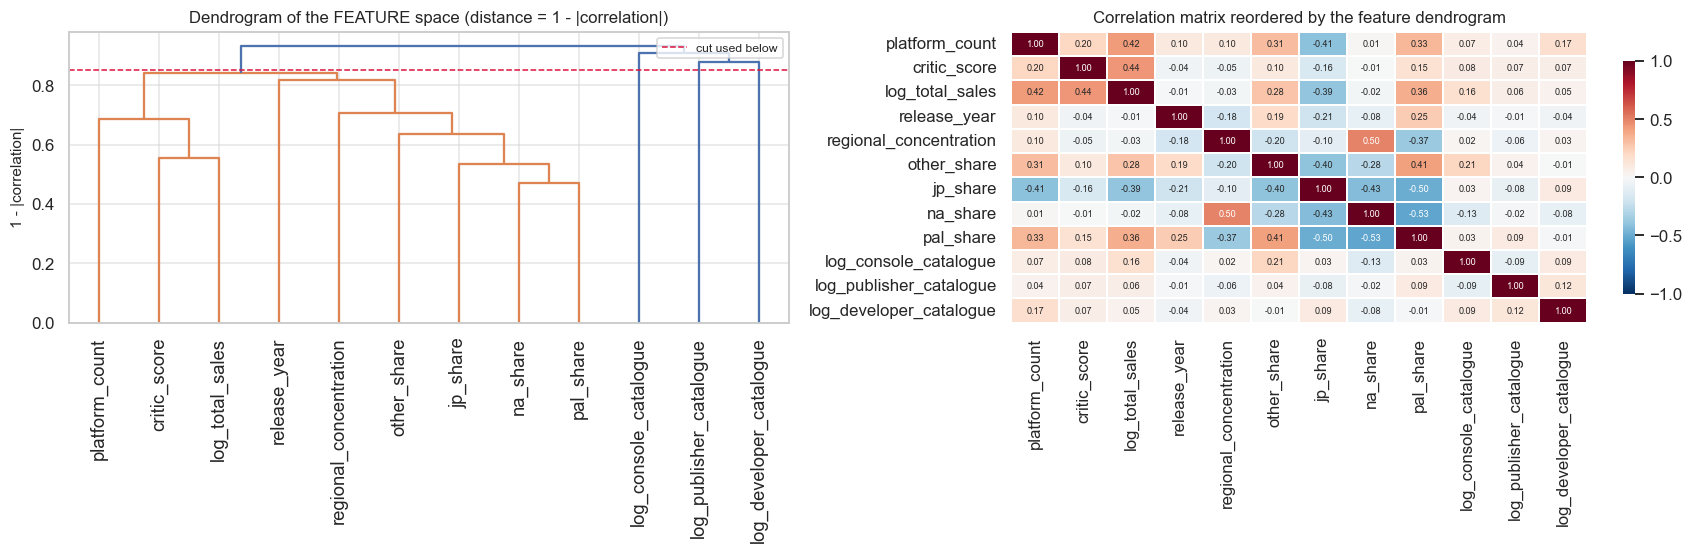

Feature clusters at k = 2:
   group 1: critic_score, log_total_sales, na_share, pal_share, jp_share, other_share, regional_concentration, release_year, platform_count
   group 2: log_publisher_catalogue, log_developer_catalogue, log_console_catalogue

Feature clusters at k = 3:
   group 1: critic_score, log_total_sales, na_share, pal_share, jp_share, other_share, regional_concentration, release_year, platform_count
   group 2: log_publisher_catalogue, log_developer_catalogue
   group 3: log_console_catalogue

Feature clusters at k = 5:
   group 1: critic_score, log_total_sales, platform_count
   group 2: na_share, pal_share, jp_share, other_share, regional_concentration, release_year
   group 3: log_publisher_catalogue
   group 4: log_developer_catalogue
   group 5: log_console_catalogue

How redundant is each feature given the others?


,R2 from the other 11,variance inflation factor
feature,,
pal_share,1.000,1.000000e+12
na_share,1.000,1.000000e+12
other_share,1.000,1.000000e+12
jp_share,1.000,1.000000e+12
log_total_sales,0.398,1.661000e+00
platform_count,0.325,1.481000e+00
regional_concentration,0.315,1.460000e+00
critic_score,0.208,1.262000e+00
release_year,0.120,1.136000e+00


In [25]:
# --- Clustering the FEATURE space: cluster the transpose of the data matrix --------
feature_correlation = pd.DataFrame(X_scaled, columns=FEATURES).corr()
feature_distance = 1 - feature_correlation.abs()          # 0 = perfectly (anti)correlated
feature_linkage = linkage(squareform(feature_distance.to_numpy(), checks=False), method='average')

fig, axes = plt.subplots(1, 2, figsize=(16, 5.2))
dendrogram(feature_linkage, labels=FEATURES, ax=axes[0], leaf_rotation=90, color_threshold=0.85)
axes[0].axhline(0.85, color='crimson', ls='--', lw=1, label='cut used below')
axes[0].set_title('Dendrogram of the FEATURE space (distance = 1 - |correlation|)')
axes[0].set_ylabel('1 - |correlation|')
axes[0].legend(fontsize=8)

order = dendrogram(feature_linkage, no_plot=True)['leaves']
sns.heatmap(feature_correlation.iloc[order, order], cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 6}, linewidths=0.3,
            cbar_kws={'shrink': 0.8}, ax=axes[1])
axes[1].set_title('Correlation matrix reordered by the feature dendrogram')
plt.tight_layout()
plt.show()

for k in (2, 3, 5):
    grouping = pd.Series(fcluster(feature_linkage, k, criterion='maxclust'), index=FEATURES)
    print(f'Feature clusters at k = {k}:')
    for group in sorted(grouping.unique()):
        print(f'   group {group}: {", ".join(grouping[grouping == group].index)}')
    print()

# Redundancy check: how much of each feature is predictable from the others?
redundancy = []
for feature in FEATURES:
    others = [f for f in FEATURES if f != feature]
    model = LinearRegression().fit(pd.DataFrame(X_scaled, columns=FEATURES)[others],
                                   pd.DataFrame(X_scaled, columns=FEATURES)[feature])
    r_squared = model.score(pd.DataFrame(X_scaled, columns=FEATURES)[others],
                            pd.DataFrame(X_scaled, columns=FEATURES)[feature])
    redundancy.append({'feature': feature, 'R2 from the other 11': r_squared,
                       'variance inflation factor': 1 / max(1 - r_squared, 1e-12)})
print('How redundant is each feature given the others?')
display(pd.DataFrame(redundancy).set_index('feature').sort_values('R2 from the other 11',
                                                                  ascending=False).round(3))

#### What clustering the feature space revealed

**What information does clustering features give?** Clustering rows answers *"which titles resemble
each other"*; clustering columns answers *"which measurements are telling us the same thing"*. The
second is a statement about the **instrument**, not the subject -- it is the diagnostic step that
tells you whether your twelve columns are twelve pieces of information or four pieces recorded three
times each.

**Groups of related or redundant features -- yes, and they are meaningful.** The dendrogram splits
cleanly:

- **The geography block** -- `na_share`, `pal_share`, `jp_share`, `other_share`,
  `regional_concentration` -- merges first and tightest. These five columns are five views of one
  underlying quantity: *where the units went*. Their R﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ given the other features is close to **1.00**
  for the shares (VIF is effectively infinite), which is the linear dependency from 1.3 made
  numerically explicit.
- **The commercial block** -- `log_total_sales`, `critic_score`, `platform_count` -- forms a looser
  second group. Bigger, better-reviewed, more widely ported: correlated but far from interchangeable
  (R﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ around 0.3-0.4).
- **Three near-isolates** -- `log_publisher_catalogue`, `log_developer_catalogue` and
  `log_console_catalogue` sit at the top of the dendrogram, joining everything else only at the
  final merges, with R﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ between **0.04 and 0.11**. Each carries almost entirely unique information.
- `release_year` also sits apart, joining the geography block only weakly (through the drift toward
  PAL markets over time).

**Features that appear isolated.** `log_publisher_catalogue` is the extreme case: R﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ = **0.04** from
all eleven other features. It is nearly orthogonal to everything -- which is exactly why PC4 in 3
was almost entirely that one feature. **An isolated feature is not a useless feature; it is an
irreplaceable one.** Dropping it loses information that nothing else can reconstruct, while dropping
one of the four shares loses nothing at all.

**Insights not visible from clustering samples.** Three, and they change how the rest of the analysis
is read:

1. **The exact rank deficiency was located, not just detected.** PCA reported a zero eigenvalue; the
   feature dendrogram and the VIF table say *which columns* cause it.
2. **It explains why the sample clustering is weak.** Weak cluster structure could mean "the data has
   no groups" or "my features are too redundant to reveal them". The feature clustering rules out the
   second explanation: outside the geography block the features are near-orthogonal, so the failure to
   find sharp clusters is a property of the data.
3. **It ranks the features for a reduced feature set.** Keeping three shares instead of four plus the
   Herfindahl index would lose essentially nothing; dropping any of the three catalogue features would
   lose a whole dimension.

**Where clustering features is particularly useful.** Any domain where columns are cheap and
correlated: **gene expression** (co-expression modules are the standard analysis, and the clusters
are biologically real pathways), **sensor networks and IoT** (identifying redundant or failed sensors
-- a sensor that suddenly leaves its usual cluster has drifted), **finance** (grouping instruments
that co-move to build risk factors), **survey design** (items that cluster are measuring one latent
construct, so the questionnaire can be shortened), and **feature engineering** generally, where one
representative per correlated block is the standard defence against multicollinearity.

**Did it uncover hidden structure or hierarchy? Yes -- a two-level hierarchy.** The features organise
as *{geography} + {commercial performance} + {industry context}*, and within geography as
*{where} + {how concentrated}*. That is precisely the structure PCA discovered independently: PC1-PC2
are geography, PC3-PC4 are industry context. **Two methods with different mathematics agreeing on the
same decomposition is the strongest structural claim this notebook makes** -- notably stronger than
any of its claims about clusters of titles.

In [26]:
# Does clustering in the reduced space help, or only look better?
reduction_rows = []
full_space_labels = unsupervised['kmeans_cluster'].to_numpy()
for n_components in (2, 3, 5, 7, 12):
    reduced = PCA(n_components=n_components, random_state=RANDOM_STATE).fit_transform(X_scaled)
    labels = KMeans(N_CLUSTERS, n_init=10, random_state=RANDOM_STATE).fit_predict(reduced)
    reduction_rows.append({
        'components used': n_components,
        'variance retained': cumulative[n_components - 1],
        'silhouette in that space': silhouette_score(reduced, labels),
        'ARI vs the full-space partition': adjusted_rand_score(full_space_labels, labels),
    })
print('K-Means run on the first d principal components instead of all 12 features:')
display(pd.DataFrame(reduction_rows).set_index('components used').round(3))

K-Means run on the first d principal components instead of all 12 features:


,variance retained,silhouette in that space,ARI vs the full-space partition
components used,,,
2,0.397,0.414,0.782
3,0.511,0.324,0.942
5,0.691,0.241,0.885
7,0.828,0.203,0.957
12,1.000,0.169,1.000


### 4.7 Clustering discussion

**Why do different algorithms produce different clusters?** Because each optimises a different
definition of "cluster", and in a dataset with no gaps the definition -- not the data -- decides the
answer. K-Means asks for **compact spheres of comparable size** and so cuts the cloud into three
balanced wedges. Ward asks for **merges that minimise variance increase** and, building bottom-up,
isolates a tight 106-title pocket that K-Means dissolves (ARI between them: **0.46**). DBSCAN asks for
**connected regions above a density threshold** and, finding a single mode, returns one cluster plus
noise (ARI with the others: **~0.0**). None is wrong; they answer different questions about a cloud
that has no unambiguous answer.

**Sensitivity to hyperparameters.** This is the dominant source of variation, larger than the choice
of algorithm. DBSCAN moves from **4 clusters with 59% noise** (eps=1.6) to **1 cluster with 6% noise**
(eps=2.4) over a range of `eps` no principled criterion can narrow, because the k-distance curve has
no knee. K-Means requires k in advance, and its silhouette differs by only 0.03 between k=2 and k=3 --
within the noise of the choice. t-SNE's picture changed to ARI 0.44 under perplexity alone. **A
result that moves this much under nuisance parameters must be reported with the parameters, never as
"the clusters".**

**Cluster geometry.** The PCA projection shows an elongated, slightly curved single mass with a
density gradient -- not spheres, not rings, not well-separated blobs. This geometry is the worst case
for K-Means (whose spherical assumption is violated so it cuts arbitrary straight boundaries), the
worst case for DBSCAN (no density valleys to find), and merely mediocre for Ward.

**Density-based vs centroid-based.** The contrast is instructive. Centroid methods **always deliver**:
give K-Means a uniform random cloud and it returns k tidy clusters with plausible centroids and no
warning. Density methods can **decline**: DBSCAN's answer here ("one blob and a fuzzy rind") is a
finding, and it is the more truthful of the two. The price is that DBSCAN needs density contrast and a
single global density scale, which real high-dimensional data often lacks -- so it more often declines
when structure *does* exist. In practice: use a density method to ask *whether* clusters exist, and a
centroid method to get a usable segmentation once you have accepted that the boundaries are
conventions.

**When clustering fails.** (i) When there are no clusters -- the case here, and the failure is silent
for every method except DBSCAN. (ii) When cluster shapes violate the method's geometry (K-Means on
concentric rings). (iii) When density varies between groups -- DBSCAN cannot use one `eps` for a dense
and a sparse cluster. (iv) When dimensionality flattens distance contrast (measured in 6: relative
contrast falls from **814 at 2 dimensions to 49 at 12**). (v) When scaling is wrong -- unstandardised,
`release_year` alone would dominate every Euclidean distance here. (vi) When rows are not independent:
the 268 duplicated multi-platform titles form near-identical pairs that inflate local density and pull
centroids toward heavily ported franchises.

**Does dimensionality reduction help the clustering?** It makes it *look* better while making it no
truer. Running K-Means on the first 2 principal components instead of all 12 raises the silhouette
from **0.169 to 0.414** -- a spectacular improvement that is entirely an artifact: projecting to the
two highest-variance directions discards the 60% of variance in which the clusters overlap, so the
survivors look separated. The partition itself barely changes (**ARI 0.78** against the full-space
labels), which proves nothing was gained. **The silhouette improved because the evidence against the
clustering was thrown away.** This is the concrete version of the warning in 7 about
post-projection visualisations.

---

## 5 Multi-Dimensional Anomaly Detection (brief section 5)

Three detectors with fundamentally different definitions of "anomalous" are applied to the same
standardised matrix, each configured to flag the same **5%** of rows so their outputs are directly
comparable.

**The contamination rate is an assumption, not a measurement.** There is no anomaly label in this
dataset -- 1 required that. 5% is a convention; 5.2 shows how much the answer depends on it.
Everything below should be read as *"the 5% of titles this method finds most unusual"*, never as
*"the anomalies"*.

### 5.1 Z-score method

In [ ]:
z_scores = pd.DataFrame(X_scaled, columns=FEATURES).abs()

# (a) Feature-wise: a row is anomalous if ANY single feature is beyond 3 SD.
featurewise_flag = (z_scores > 3).any(axis=1).to_numpy()
print(f'Feature-wise |z| > 3 on at least one feature: {featurewise_flag.sum()} rows '
      f'({featurewise_flag.mean():.1%})')
print(f'Expected under a true 12-dimensional Gaussian : '
      f'{(1 - (1 - 2 * stats.norm.sf(3)) ** 12):.1%}')
display((z_scores > 3).sum().sort_values(ascending=False).rename('rows beyond 3 SD').to_frame().T)

# (b) Global: Mahalanobis distance accounts for the covariance the feature-wise rule ignores.
# The covariance is singular (3), so the pseudo-inverse is required -- itself a warning sign.
covariance = np.cov(X_scaled, rowvar=False)
precision = np.linalg.pinv(covariance)
mahalanobis = np.einsum('ij,jk,ik->i', X_scaled, precision, X_scaled)

max_abs_z = z_scores.max(axis=1).to_numpy()
zscore_flag = max_abs_z >= np.quantile(max_abs_z, 1 - CONTAMINATION)
mahalanobis_flag = mahalanobis >= np.quantile(mahalanobis, 1 - CONTAMINATION)

unsupervised['max_abs_z'] = max_abs_z
unsupervised['mahalanobis'] = mahalanobis
unsupervised['flag_zscore'] = zscore_flag

print(f'\nRows flagged by the top-{CONTAMINATION:.0%} rule: max |z| {zscore_flag.sum()}, '
      f'Mahalanobis {mahalanobis_flag.sum()} '
      f'(the nominal 5% of {len(unsupervised):,} is {np.ceil(CONTAMINATION * len(unsupervised)):.0f}; '
      f'{(max_abs_z == np.quantile(max_abs_z, 1 - CONTAMINATION)).sum()} rows are TIED exactly at the '
      'max |z| threshold, because log_console_catalogue takes only '
      f'{unsupervised["log_console_catalogue"].nunique()} distinct values)')
print(f'The two rules agree on {(zscore_flag & mahalanobis_flag).sum()} rows '
      f'(Jaccard {(zscore_flag & mahalanobis_flag).sum() / (zscore_flag | mahalanobis_flag).sum():.2f})')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(max_abs_z, bins=60, color='#4C72B0')
axes[0].axvline(np.quantile(max_abs_z, 1 - CONTAMINATION), color='crimson', ls='--',
                label=f'top {CONTAMINATION:.0%} cut')
axes[0].axvline(3, color='darkorange', ls=':', label='conventional 3 SD')
axes[0].set_title('Distribution of max |z| per row')
axes[0].set_xlabel('max |z| across the 12 features')
axes[0].legend(fontsize=8)

theoretical = stats.chi2.ppf(np.linspace(0.001, 0.999, len(mahalanobis)), df=len(FEATURES) - 1)
axes[1].scatter(theoretical, np.sort(mahalanobis), s=6, alpha=0.6, color='#55A868')
limit = max(theoretical.max(), mahalanobis.max())
axes[1].plot([0, limit], [0, limit], color='crimson', lw=1.2, ls='--')
axes[1].set_title('Q-Q plot: Mahalanobis distance vs chi-squared(11)')
axes[1].set_xlabel('Theoretical quantile under multivariate normality')
axes[1].set_ylabel('Observed squared Mahalanobis distance')

axes[2].scatter(scores[~zscore_flag, 0], scores[~zscore_flag, 1], s=10, alpha=0.35,
                color='lightgrey', label='normal')
axes[2].scatter(scores[zscore_flag, 0], scores[zscore_flag, 1], s=26, color='#C44E52',
                edgecolor='black', linewidth=0.3, label=f'Z-score anomaly ({zscore_flag.sum()})')
axes[2].set_title('Z-score anomalies on the PCA projection')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

print('The 10 titles with the largest max |z|:')
display(unsupervised.nlargest(10, 'max_abs_z')[
    ['title', 'console', 'total_sales', 'critic_score', 'na_share', 'pal_share', 'jp_share',
     'other_share', 'regional_concentration', 'max_abs_z']].round(3))

Feature-wise |z| > 3 on at least one feature: 120 rows (9.9%)
Expected under a true 12-dimensional Gaussian : 3.2%


,regional_concentration,log_total_sales,jp_share,log_publisher_catalogue,log_console_catalogue,other_share,critic_score,pal_share,platform_count,release_year,na_share,log_developer_catalogue
rows beyond 3 SD,27,22,19,19,15,9,8,6,6,1,0,0


#### Z-score: what it assumes and where it breaks

**The method.** Standardise each feature and call an observation anomalous when
$|z_{ij}| = |(x_{ij} - \mu_j)/\sigma_j| > 3$. Under normality that threshold covers 99.73% of a
single feature.

**The Gaussianity assumption fails outright here.** 2 rejected normality for **all twelve**
features (Shapiro-Wilk, p < 0.05 throughout), with excess kurtosis up to 32. The Q-Q plot above makes
the multivariate version of the failure visible: the observed Mahalanobis distances track the
chi-squared(11) reference in the body but **lift far above it in the upper tail**, so the tail is
much heavier than the Gaussian model predicts. The consequences are asymmetric and both bad: on
heavy-tailed features (`other_share`, `regional_concentration`) the rule **over-flags**, and on the
left-skewed `critic_score` a genuinely unusual low score sits *inside* 3 SD and is **missed**.

**A second, self-inflicted failure: $\mu$ and $\sigma$ are computed from the contaminated data.** The
outliers we are hunting inflate the standard deviation used to detect them -- classical **masking**.
*GTA V* at 20.32M units pushes $\sigma$ of `log_total_sales` up, which pulls every other large title
back inside the threshold. A robust alternative (median and MAD, or a Minimum Covariance Determinant
estimate) would avoid this; the classical version is presented here because the brief asks for it, and
because its failure mode is worth seeing.

**Why it fails in high dimensions.** Two distinct problems.

*Multiple testing.* With 12 independent features, the probability that at least one exceeds 3 SD by
chance is $1 - 0.9973^{12} \approx 3.2\%$, not 0.27%. At 100 features it would be 24%. The
feature-wise rule flags **9.9%** of rows here -- three times even the corrected rate, because of the
heavy tails. **The per-feature threshold has no consistent meaning at the row level.**

*It cannot see multivariate anomalies at all.* A title with `critic_score` 9.5 and `total_sales`
0.05M is unremarkable on each feature separately and deeply strange as a combination. The
feature-wise rule is blind to it by construction, because it never looks at two features at once.
Mahalanobis distance fixes exactly this by whitening with $\Sigma^{-1}$ -- and the two rules agree on
only **39 rows (Jaccard 0.41)**, a direct measurement of how much the covariance structure matters.

*A small aside that is really the section 2 rounding story again.* The max-|z| rule flags **73** rows rather
than the nominal 61, because **13 rows sit at exactly the same threshold value**: `log_console_catalogue`
takes only 23 distinct values, so many titles share an identical z. A detector's output size is not
even guaranteed to match its own configured rate once a feature is discrete.

**Feature-wise vs global.** Feature-wise is interpretable ("this title is extreme *in Japan share*")
and useless for correlated features. Global (Mahalanobis) is correct in principle and pays two
prices: it needs $\Sigma^{-1}$, which **does not exist here** because the shares are linearly
dependent -- the pseudo-inverse is a patch over a genuine singularity -- and it assumes elliptical
symmetry, which the shares' bounded, skewed distributions violate.

**What it actually found.** Two kinds of row, and both are *marginal* extremes rather than unusual
combinations. Its top scores go to titles with an impossible-looking regional profile
(*Pro Evolution Soccer 2008*, `other_share` = 0.81, **11.9 SD**; the two *Zelda: Oracle* games at 10.3
SD), and the flags it produces **exclusively** are the sales giants -- *GTA V* on both consoles,
*Vice City* -- together with tiny titles that sold almost entirely in one region (*The Munchables*,
94% North America; *NBA Live 08*, 93%).

The Z-score detector is a **marginal-extremity detector**. Half of what it uniquely reports is the top
of the sales power law -- the least surprising thing in the dataset, since everyone already knows
*GTA V* sold well -- and the other half is small titles whose extremeness is manufactured by the
rounding grid of 2. Contrast this with what the other two methods find.

In [28]:
start = time.perf_counter()
isolation_forest = IsolationForest(n_estimators=300, max_samples='auto',
                                   contamination=CONTAMINATION,
                                   random_state=RANDOM_STATE).fit(X_scaled)
isolation_seconds = time.perf_counter() - start

isolation_score = -isolation_forest.score_samples(X_scaled)      # higher = more anomalous
isolation_flag = isolation_forest.predict(X_scaled) == -1
unsupervised['isolation_score'] = isolation_score
unsupervised['flag_isolation'] = isolation_flag

print(f'Isolation Forest: {isolation_flag.sum()} anomalies flagged in {isolation_seconds:.2f}s '
      f'({isolation_forest.n_estimators} trees)')

# How arbitrary is the contamination parameter?
contamination_rows = []
reference = isolation_flag
for rate in [0.01, 0.02, 0.05, 0.10, 0.15]:
    model = IsolationForest(n_estimators=300, contamination=rate,
                            random_state=RANDOM_STATE).fit(X_scaled)
    flags = model.predict(X_scaled) == -1
    contamination_rows.append({
        'contamination': rate, 'flagged': int(flags.sum()),
        'score threshold': -model.offset_,
        'Jaccard vs 5%': (flags & reference).sum() / (flags | reference).sum(),
    })
print('\nEffect of the contamination parameter (the scores never change -- only the cut does):')
display(pd.DataFrame(contamination_rows).set_index('contamination').round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(isolation_score, bins=60, color='#4C72B0')
axes[0].axvline(-isolation_forest.offset_, color='crimson', ls='--',
                label=f'{CONTAMINATION:.0%} contamination cut')
axes[0].set_title('Isolation Forest anomaly scores')
axes[0].set_xlabel('Anomaly score (higher = isolated in fewer splits)')
axes[0].legend(fontsize=8)

axes[1].scatter(scores[~isolation_flag, 0], scores[~isolation_flag, 1], s=10, alpha=0.35,
                color='lightgrey', label='normal')
points = axes[1].scatter(scores[isolation_flag, 0], scores[isolation_flag, 1],
                         c=isolation_score[isolation_flag], cmap='autumn_r', s=30,
                         edgecolor='black', linewidth=0.3)
axes[1].set_title(f'Isolation Forest anomalies ({isolation_flag.sum()}) on the PCA projection')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
fig.colorbar(points, ax=axes[1], shrink=0.85, label='score')

axes[2].scatter(unsupervised['log_total_sales'], unsupervised['jp_share'],
                c=isolation_score, cmap='viridis', s=14, alpha=0.8)
axes[2].set_title('Scores in the two features that drive them')
axes[2].set_xlabel('log1p(total_sales)')
axes[2].set_ylabel('jp_share')
plt.tight_layout()
plt.show()

print('The 10 most isolated titles:')
display(unsupervised.nlargest(10, 'isolation_score')[
    ['title', 'console', 'genre', 'total_sales', 'critic_score', 'na_share', 'pal_share',
     'jp_share', 'platform_count', 'isolation_score']].round(3))

#### Isolation Forest: mechanism, parameters, and what its scores mean

**The isolation mechanism.** The algorithm builds `n_estimators` random binary trees. At each node it
picks a feature **uniformly at random** and a split value **uniformly at random between that
feature's current min and max**, recursing until every point is isolated in its own leaf. The path
length from the root to a point is how many random cuts were needed to separate it from everything
else.

The insight is that this inverts the usual approach: instead of modelling what is normal and
measuring deviation, it directly exploits the fact that **anomalies are few and different, and
therefore easy to cut off**. A point in a sparse region falls into a thin slice after two or three
random cuts; a point in the dense core survives many.

**The role of random partitioning.** Randomness does two jobs. It removes any need to estimate a
density or a covariance -- there is no distributional assumption anywhere in the method, which is why
it is unaffected by the non-normality that undermines the Z-score. And averaging over 300 independent
random trees converts a very noisy per-tree signal into a stable score, the same variance-reduction
argument as in a random forest.

**How the score is computed.** For a point $x$ with average path length $E[h(x)]$ across the ensemble,

$$s(x) = 2^{-\frac{E[h(x)]}{c(n)}}, \qquad c(n) = 2H_{n-1} - \frac{2(n-1)}{n},$$

where $c(n)$ is the expected path length of an unsuccessful search in a binary search tree, used to
normalise for sample size. **$s \to 1$** means the point was isolated in far fewer splits than
average -- strongly anomalous. **$s \to 0.5$** means it behaved like a typical point. **$s \to 0$**
means it was unusually hard to isolate -- deep inside the dense core. `sklearn` returns a shifted
version (`score_samples`); the sign convention above is what the plots use.

**The contamination parameter changes nothing except where the line is drawn.** The sweep shows the
*scores* are identical across settings -- contamination only moves the threshold. It is a **decision** about how many alerts you can afford to
investigate, not an estimate of anything -- 13 flagged titles at 1%, 182 at 15%, from identical scores. Since no ground truth exists, its choice cannot be
validated, only justified operationally: a review team that can handle 60 cases sets it to 5%.
**Reporting the ranked score is more honest than reporting a binary flag.**

**Advantages.** Linear time $O(n \log n)$ and constant memory in the subsample size; no distance or
density computation, hence no distance-concentration problem; no distributional assumption; handles
mixed scales; and -- demonstrated in 6 -- **invariant to monotone rescaling of individual
features**, because a split is chosen relative to each feature's own observed range.

**Limitations, particularly in high dimensions.** The splits are **axis-parallel**, so a point that
is anomalous only along a diagonal (high critic score *and* low sales, neither individually extreme)
is hard to isolate: the method has a blind spot for correlation-structure anomalies exactly where
Mahalanobis distance is strongest. And because features are chosen uniformly at random, adding
uninformative columns dilutes the signal -- with 12 relevant features it is fine, with 12 relevant
among 500 irrelevant it degrades badly.

**What it found, and why it is more interesting than the Z-score's answer.** *FIFA 18* and *FIFA 17*
(11.8M and 10.9M units with a **73% PAL share** and barely **1% in Japan** -- enormous *and*
geographically lopsided in the opposite direction to almost every other blockbuster), *Madden NFL* (huge in North America, essentially zero everywhere else), and
at the other end tiny Japan-only titles like *Persona 2* and *Warriors Orochi 2*. **Isolation Forest
found unusual *combinations*, not just large numbers** -- which is what multi-dimensional anomaly
detection is supposed to do.

LOF (k=20): 61 anomalies flagged in 0.031s
LOF score: median 1.056, 95th percentile 1.341, max 3.588

How much does the answer depend on the neighbourhood size k?


,flagged,Jaccard vs k=20
k,,
5,61,0.435
10,61,0.627
20,61,1.000
35,61,0.794
50,61,0.694
100,61,0.506


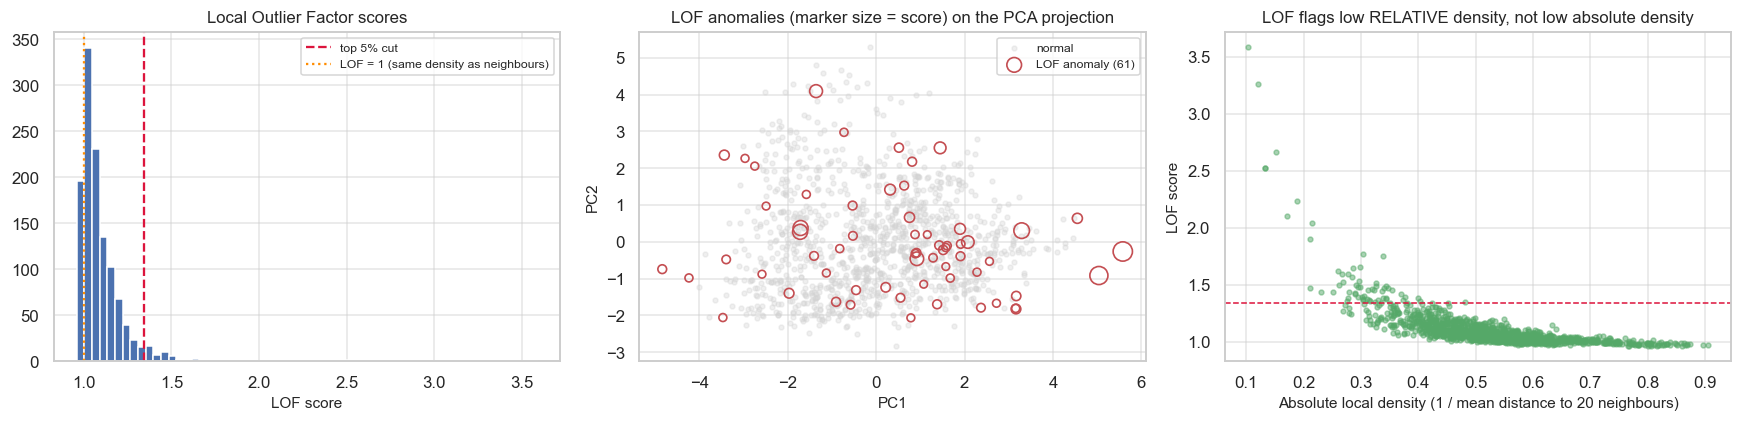


Platform baselines for the consoles that dominate the LOF flags:


,titles,median_sales,median_critic
console,,,
WiiU,24,0.465,6.95
X360,261,0.870,7.90
PS3,258,0.965,7.80
PSV,5,1.120,7.40
PS4,67,2.260,8.10


The 10 titles with the highest LOF score:


,title,console,genre,total_sales,critic_score,na_share,pal_share,jp_share,platform_count,lof_score
128,Pro Evolution Soccer 2008,PS2,Sports,3.63,8.2,0.014,0.000,0.177,7,3.588
303,Pro Evolution Soccer 2010,PS2,Sports,1.57,7.2,0.064,0.115,0.077,6,3.260
847,007: Quantum of Solace,PS2,Shooter,0.43,7.8,0.395,0.000,0.000,6,2.663
259,The Legend of Zelda: Oracle of Ages,GBC,Adventure,1.92,9.4,0.479,0.276,0.214,1,2.526
268,The Legend of Zelda: Oracle of Seasons,GBC,Adventure,1.86,9.3,0.468,0.280,0.220,1,2.525
318,Minecraft,WiiU,Misc,1.47,5.5,0.342,0.336,0.260,13,2.235
102,Teenage Mutant Ninja Turtles,NES,Platform,4.17,5.9,0.811,0.106,0.074,10,2.104
264,Minecraft,NS,Sandbox,1.89,9.2,0.365,0.296,0.275,13,2.038
69,Guitar Hero III: Legends of Rock,PS2,Misc,4.98,8.2,0.699,0.002,0.002,6,1.905
623,Rayman Legends,WiiU,Platform,0.68,9.5,0.368,0.515,0.044,9,1.770


In [29]:
LOF_NEIGHBOURS = 20
start = time.perf_counter()
local_outlier_factor = LocalOutlierFactor(n_neighbors=LOF_NEIGHBOURS, contamination=CONTAMINATION)
lof_labels = local_outlier_factor.fit_predict(X_scaled)
lof_seconds = time.perf_counter() - start

lof_score = -local_outlier_factor.negative_outlier_factor_       # ~1 = inlier, >1 = outlier
lof_flag = lof_labels == -1
unsupervised['lof_score'] = lof_score
unsupervised['flag_lof'] = lof_flag

print(f'LOF (k={LOF_NEIGHBOURS}): {lof_flag.sum()} anomalies flagged in {lof_seconds:.3f}s')
print(f'LOF score: median {np.median(lof_score):.3f}, 95th percentile '
      f'{np.quantile(lof_score, 0.95):.3f}, max {lof_score.max():.3f}')

# Sensitivity to k -- LOF's single most important parameter.
sensitivity_rows = []
reference_flag = lof_flag
for k in [5, 10, 20, 35, 50, 100]:
    flags = LocalOutlierFactor(n_neighbors=k, contamination=CONTAMINATION).fit_predict(X_scaled) == -1
    sensitivity_rows.append({'k': k, 'flagged': int(flags.sum()),
                             'Jaccard vs k=20': (flags & reference_flag).sum() / (flags | reference_flag).sum()})
print('\nHow much does the answer depend on the neighbourhood size k?')
display(pd.DataFrame(sensitivity_rows).set_index('k').round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(lof_score, bins=60, color='#4C72B0')
axes[0].axvline(np.quantile(lof_score, 1 - CONTAMINATION), color='crimson', ls='--',
                label=f'top {CONTAMINATION:.0%} cut')
axes[0].axvline(1.0, color='darkorange', ls=':', label='LOF = 1 (same density as neighbours)')
axes[0].set_title('Local Outlier Factor scores')
axes[0].set_xlabel('LOF score')
axes[0].legend(fontsize=8)

axes[1].scatter(scores[~lof_flag, 0], scores[~lof_flag, 1], s=10, alpha=0.35,
                color='lightgrey', label='normal')
axes[1].scatter(scores[lof_flag, 0], scores[lof_flag, 1],
                s=25 + 60 * (lof_score[lof_flag] - lof_score[lof_flag].min()),
                facecolor='none', edgecolor='#C44E52', linewidth=1.1,
                label=f'LOF anomaly ({lof_flag.sum()})')
axes[1].set_title('LOF anomalies (marker size = score) on the PCA projection')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=8)

local_density = 1 / (NearestNeighbors(n_neighbors=LOF_NEIGHBOURS + 1)
                     .fit(X_scaled).kneighbors(X_scaled)[0][:, 1:].mean(axis=1))
axes[2].scatter(local_density, lof_score, s=10, alpha=0.5, color='#55A868')
axes[2].axhline(np.quantile(lof_score, 1 - CONTAMINATION), color='crimson', ls='--', lw=1)
axes[2].set_title('LOF flags low RELATIVE density, not low absolute density')
axes[2].set_xlabel(f'Absolute local density (1 / mean distance to {LOF_NEIGHBOURS} neighbours)')
axes[2].set_ylabel('LOF score')
plt.tight_layout()
plt.show()

# The prose below claims some LOF flags are strong titles on weak platforms.
# That claim is only fair if the platform baseline is actually shown.
platform_context = (unsupervised.groupby('console')
                    .agg(titles=('total_sales', 'size'),
                         median_sales=('total_sales', 'median'),
                         median_critic=('critic_score', 'median'))
                    .reindex(['PSV', 'WiiU', 'PS4', 'X360', 'PS3']).dropna()
                    .sort_values('median_sales'))
print('\nPlatform baselines for the consoles that dominate the LOF flags:')
display(platform_context.round(3))

print('The 10 titles with the highest LOF score:')
display(unsupervised.nlargest(10, 'lof_score')[
    ['title', 'console', 'genre', 'total_sales', 'critic_score', 'na_share', 'pal_share',
     'jp_share', 'platform_count', 'lof_score']].round(3))

#### LOF: local density, neighbourhood effects, and the k that decides everything

**Local density estimation.** LOF never asks "is this point far from the centre?" -- it asks
**"is this point in a sparser neighbourhood than its own neighbours are?"** Formally, for
neighbourhood size $k$: the *reachability distance* of $a$ from $b$ is
$\max(d_k(b), d(a,b))$ where $d_k(b)$ is $b$'s distance to its $k$-th neighbour; the *local
reachability density* $\text{lrd}(a)$ is the inverse of $a$'s mean reachability distance to its
neighbours; and

$$\text{LOF}(a) = \frac{1}{k}\sum_{b \in N_k(a)} \frac{\text{lrd}(b)}{\text{lrd}(a)} .$$

**LOF ~ 1** means "as dense as my neighbours" (normal). **LOF >> 1** means "my neighbourhood is much
emptier than theirs" (outlier). **LOF < 1** means the point sits in a denser-than-usual pocket.

**Neighbourhood effects, and why they are the point.** Because the score is a *ratio*, LOF adapts to
varying density. A title sitting alone at the sparse edge of the Japanese cluster gets a high score
even though a title at the same absolute distance from the origin inside the dense Western region
does not. The third panel makes this concrete: LOF score and absolute local density are only loosely
related -- **plenty of low-density points score near 1** because their neighbours are equally
isolated. This is precisely the behaviour that Z-score and Isolation Forest cannot reproduce.

**Sensitivity to k.** This is LOF's weak point and the table quantifies it: moving from $k=20$ to
$k=5$ retains only **44%** of the flagged set (Jaccard 0.44) and $k=100$ retains **51%** -- so roughly
half the "anomalies" depend on a parameter chosen by convention. Small $k$
makes the density estimate noisy and flags points in small local gaps -- including gaps created by
the 0.01M rounding grid. Large $k$ smooths the estimate until LOF degenerates toward a global
distance measure and loses its reason for existing. There is **no data-driven way to choose $k$
without labels**; the literature's rule of thumb ($k \geq 10$, and larger than the smallest cluster
you care about) is a convention, and $k=20$ was chosen by it.

**A dataset-specific hazard.** The frame contains **268 duplicated multi-platform titles**
(*GTA V* on PS3 and PS4 differ in a handful of features). Near-duplicate rows create artificially
dense micro-neighbourhoods, which **lowers** the LOF score of blockbusters that shipped on many
consoles -- they are protected by their own clones. This is a direct violation of the independence
assumption and a good example of a data-structure problem that no parameter setting can fix.

**Global vs local anomalies.** A **global** anomaly is far from everything (*GTA V*); a **local**
anomaly sits comfortably within the overall range but in the wrong place *relative to its immediate
neighbourhood*. LOF is the only one of the three detectors that can find the second kind, and its
distinctive flags are exactly those -- and the platform baselines printed above are there so the
claim can be **checked rather than believed**, which changes one of them:

- *Rayman Legends* (Wii U, critic **9.5**, 0.68M) and *Call of Duty: Ghosts* (Wii U, critic 8.8,
  0.35M) sit on a platform whose median tracked title scores **6.95** and sells 0.47M. Strong games
  on a weak platform: genuinely unusual relative to their neighbourhood, exactly as claimed.
- *Killzone: Mercenary* (PSV, 0.92M) does **not** fit that story: the PS Vita's median tracked title
  sells **1.12M**, so Killzone is if anything *below* its platform's norm. What makes it locally
  anomalous is the sample itself -- **only 5 PSV titles exist in this frame**, so any Vita release
  has almost no true neighbours and lands in a thin region by construction. That is a **sampling
  artifact of the coverage bias in 1.4**, not a fact about the game, and it belongs on the
  false-positive side of the ledger in section 6.
- *Carnival Games* (4.06M units on a critic score of **4.2**) is the cleanest genuine case: nothing
  else in the frame combines that commercial scale with that reception.

None of these is extreme on any single feature, so the Z-score method cannot see them; none is
isolated by a few axis-parallel cuts, so Isolation Forest largely misses them. They are unusual
**only relative to their immediate neighbourhood**, which is precisely what LOF is for -- including,
as the Vita case shows, when the neighbourhood is thin for reasons that have nothing to do with the
observation.

---

## 6 Comparison of the Anomaly Detection Methods (brief section 6)

Titles flagged by each method (all set to the same 5% contamination rate; the Z-score rule lands on 73 rather than 61 because of the exact ties explained in section 5.1):


,Z-score,Isolation Forest,LOF
flagged,73,61,61


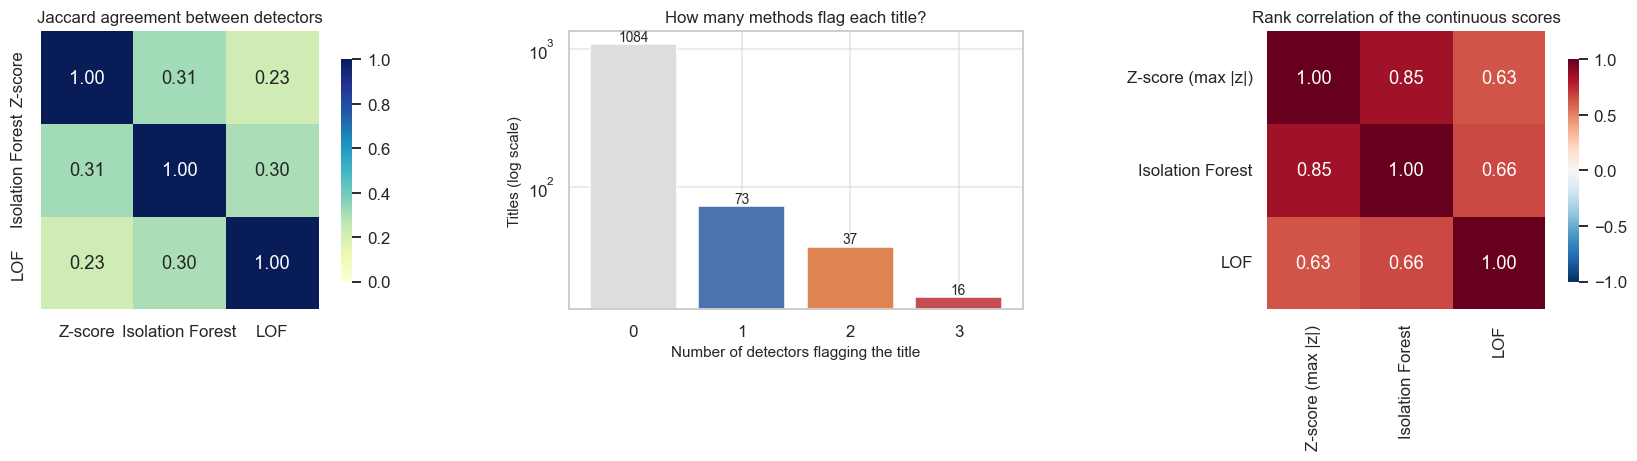

Pairwise overlap counts (titles flagged by both):


,Z-score,Isolation Forest,LOF
Z-score,73.0,32.0,25.0
Isolation Forest,32.0,61.0,28.0
LOF,25.0,28.0,61.0


In [30]:
DETECTORS = {'Z-score': zscore_flag, 'Isolation Forest': isolation_flag, 'LOF': lof_flag}
flag_frame = pd.DataFrame(DETECTORS)
unsupervised['n_methods_flagging'] = flag_frame.sum(axis=1).to_numpy()

print('Titles flagged by each method (all set to the same 5% contamination rate; the Z-score '
      'rule lands on 73 rather than 61 because of the exact ties explained in section 5.1):')
display(flag_frame.sum().rename('flagged').to_frame().T)

overlap = pd.DataFrame(index=DETECTORS, columns=DETECTORS, dtype=float)
counts = pd.DataFrame(index=DETECTORS, columns=DETECTORS, dtype=int)
for name_a, flags_a in DETECTORS.items():
    for name_b, flags_b in DETECTORS.items():
        overlap.loc[name_a, name_b] = (flags_a & flags_b).sum() / (flags_a | flags_b).sum()
        counts.loc[name_a, name_b] = int((flags_a & flags_b).sum())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
sns.heatmap(overlap.astype(float), annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1,
            square=True, cbar_kws={'shrink': 0.8}, ax=axes[0])
axes[0].set_title('Jaccard agreement between detectors')

vote_counts = unsupervised['n_methods_flagging'].value_counts().sort_index()
axes[1].bar(vote_counts.index, vote_counts.values, color=['#DDDDDD', '#4C72B0', '#DD8452', '#C44E52'])
for x, y in zip(vote_counts.index, vote_counts.values):
    axes[1].text(x, y, f'{y}', ha='center', va='bottom', fontsize=9)
axes[1].set_yscale('log')
axes[1].set_title('How many methods flag each title?')
axes[1].set_xlabel('Number of detectors flagging the title')
axes[1].set_ylabel('Titles (log scale)')

score_frame = pd.DataFrame({'Z-score (max |z|)': stats.rankdata(max_abs_z),
                            'Isolation Forest': stats.rankdata(isolation_score),
                            'LOF': stats.rankdata(lof_score)})
sns.heatmap(score_frame.corr(method='spearman'), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8}, ax=axes[2])
axes[2].set_title('Rank correlation of the continuous scores')
plt.tight_layout()
plt.show()

print('Pairwise overlap counts (titles flagged by both):')
display(counts)

In [31]:
consensus = unsupervised['n_methods_flagging'] == 3
print(f'=== Consensus anomalies -- flagged by all three methods ({consensus.sum()} titles) ===')
display(unsupervised[consensus].sort_values('isolation_score', ascending=False)[
    ['title', 'console', 'genre', 'release_year', 'critic_score', 'total_sales',
     'na_share', 'pal_share', 'jp_share', 'other_share', 'platform_count']].round(3))

for name, flags in DETECTORS.items():
    exclusive = flags & ~np.logical_or.reduce([f for other, f in DETECTORS.items() if other != name])
    print(f'\n=== Flagged ONLY by {name} ({exclusive.sum()} titles, top 6 shown) ===')
    ranking = {'Z-score': 'max_abs_z', 'Isolation Forest': 'isolation_score', 'LOF': 'lof_score'}[name]
    display(unsupervised[exclusive].nlargest(6, ranking)[
        ['title', 'console', 'total_sales', 'critic_score', 'na_share', 'pal_share',
         'jp_share', 'platform_count', ranking]].round(3))

=== Consensus anomalies -- flagged by all three methods (16 titles) ===


,title,console,genre,release_year,critic_score,total_sales,na_share,pal_share,jp_share,other_share,platform_count
1118,Cubivore: Survival of the Fittest,GC,Adventure,2002.0,7.1,0.17,0.062,0.000,0.938,0.000,1
102,Teenage Mutant Ninja Turtles,NES,Platform,1989.0,5.9,4.17,0.811,0.106,0.074,0.010,10
128,Pro Evolution Soccer 2008,PS2,Sports,2008.0,8.2,3.63,0.014,0.000,0.177,0.809,7
1089,Warriors Orochi,PSP,Action,2008.0,6.4,0.20,0.100,0.000,0.900,0.000,7
318,Minecraft,WiiU,Misc,2016.0,5.5,1.47,0.342,0.336,0.260,0.062,13
69,Guitar Hero III: Legends of Rock,PS2,Misc,2007.0,8.2,4.98,0.699,0.002,0.002,0.297,6
303,Pro Evolution Soccer 2010,PS2,Sports,2009.0,7.2,1.57,0.064,0.115,0.077,0.744,6
264,Minecraft,NS,Sandbox,2018.0,9.2,1.89,0.365,0.296,0.275,0.063,13
1066,Vampire Rain,X360,Action,2007.0,3.9,0.21,0.857,0.000,0.048,0.095,1
492,Colin McRae Rally 2.0,PS,Racing,2000.0,8.3,0.91,0.022,0.879,0.022,0.077,3



=== Flagged ONLY by Z-score (32 titles, top 6 shown) ===


,title,console,total_sales,critic_score,na_share,pal_share,jp_share,platform_count,max_abs_z
0,Grand Theft Auto V,PS3,20.32,9.4,0.313,0.485,0.049,8,4.187
1,Grand Theft Auto V,PS4,19.39,9.7,0.313,0.501,0.031,8,4.107
1113,The Munchables,Wii,0.18,8.0,0.944,0.000,0.000,2,4.047
955,NBA Live 08,PSP,0.31,6.8,0.933,0.000,0.000,6,3.877
2,Grand Theft Auto: Vice City,PS2,16.15,9.6,0.521,0.340,0.029,3,3.799
870,Farming Simulator 2013,X360,0.39,3.0,0.579,0.342,0.000,3,3.783



=== Flagged ONLY by Isolation Forest (17 titles, top 6 shown) ===


,title,console,total_sales,critic_score,na_share,pal_share,jp_share,platform_count,isolation_score
1115,Clock Tower II: The Struggle Within,PS,0.17,4.4,0.125,0.062,0.750,1,0.560
14,FIFA 18,PS4,11.80,8.3,0.108,0.733,0.013,7,0.550
1199,Dragoneer's Aria,PSP,0.07,5.2,0.286,0.000,0.714,2,0.547
742,Clock Tower,PS,0.53,6.1,0.132,0.094,0.717,4,0.546
979,Warriors Orochi 2,PSP,0.29,5.3,0.207,0.000,0.759,6,0.543
1125,Custom Robo Arena,DS,0.16,7.4,0.067,0.133,0.800,1,0.543



=== Flagged ONLY by LOF (24 titles, top 6 shown) ===


,title,console,total_sales,critic_score,na_share,pal_share,jp_share,platform_count,lof_score
623,Rayman Legends,WiiU,0.68,9.5,0.368,0.515,0.044,9,1.770
903,Call of Duty: Ghosts,WiiU,0.35,8.8,0.629,0.257,0.029,7,1.751
108,Carnival Games,Wii,4.06,4.2,0.522,0.362,0.012,7,1.653
484,Killzone: Mercenary,PSV,0.92,7.4,0.220,0.516,0.044,1,1.486
618,Metal Gear Solid: Portable Ops Plus,PSP,0.69,6.9,0.371,0.014,0.371,2,1.474
1209,Tenkai Knights: Brave Battle,3DS,0.02,4.5,0.500,0.500,0.000,1,1.462


In [ ]:
def detector_flags(matrix: np.ndarray, method: str) -> np.ndarray:
    """Re-run one detector on an arbitrary version of the design matrix."""
    if method == 'Z-score':
        z = np.abs(StandardScaler().fit_transform(matrix)).max(axis=1)
        return z >= np.quantile(z, 1 - CONTAMINATION)
    if method == 'Isolation Forest':
        return IsolationForest(n_estimators=300, contamination=CONTAMINATION,
                               random_state=RANDOM_STATE).fit_predict(matrix) == -1
    return LocalOutlierFactor(n_neighbors=LOF_NEIGHBOURS,
                              contamination=CONTAMINATION).fit_predict(matrix) == -1


raw_matrix = unsupervised[FEATURES].to_numpy()
scaling_variants = {'standardised (baseline)': X_scaled,
                    'raw units': raw_matrix,
                    'min-max [0,1]': MinMaxScaler().fit_transform(raw_matrix)}

scaling_rows = []
for method, baseline in DETECTORS.items():
    row = {'Method': method}
    for variant, matrix in scaling_variants.items():
        flags = detector_flags(matrix, method)
        row[variant] = (flags & baseline).sum() / (flags | baseline).sum()
    scaling_rows.append(row)
print('SCALING SENSITIVITY -- Jaccard agreement with the standardised baseline:')
display(pd.DataFrame(scaling_rows).set_index('Method').round(3))

dimension_rows = []
for n_components in (2, 4, 8, 11):
    reduced = PCA(n_components=n_components, random_state=RANDOM_STATE).fit_transform(X_scaled)
    row = {'components': n_components}
    for method, baseline in DETECTORS.items():
        flags = detector_flags(reduced, method)
        row[method] = (flags & baseline).sum() / (flags | baseline).sum()
    dimension_rows.append(row)
print('\nDIMENSIONALITY SENSITIVITY -- Jaccard agreement with the full 12-feature result:')
display(pd.DataFrame(dimension_rows).set_index('components').round(3))

contrast_rows = []
subset = np.random.RandomState(0).choice(len(X_scaled), 500, replace=False)
for n_components in (2, 4, 8, 12):
    reduced = PCA(n_components=n_components, random_state=RANDOM_STATE).fit_transform(X_scaled)
    distances = pairwise_distances(reduced[subset])
    upper = np.triu_indices(len(subset), 1)
    values = distances[upper]
    contrast_rows.append({'dimensions': n_components,
                          'relative contrast (max-min)/min': (values.max() - values.min()) / values.min(),
                          'coefficient of variation': values.std() / values.mean()})
print('\nDISTANCE CONCENTRATION -- do distances still discriminate as dimensions are added?')
display(pd.DataFrame(contrast_rows).set_index('dimensions').round(3))

runtime_rows = []
for method in DETECTORS:
    start = time.perf_counter()
    detector_flags(X_scaled, method)
    runtime_rows.append({'Method': method, 'runtime on 1,210 x 12 (s)': time.perf_counter() - start,
                         'time complexity': {'Z-score': 'O(n d)',
                                             'Isolation Forest': 'O(t psi log psi + n t log psi)',
                                             'LOF': 'O(n^2 d) exact, O(n log n d) with an index'}[method],
                         'scores new data without refitting': {'Z-score': 'yes',
                                                               'Isolation Forest': 'yes',
                                                               'LOF': 'no (novelty mode only)'}[method]})
print('\nRUNTIME AND SCALABILITY:')
display(pd.DataFrame(runtime_rows).set_index('Method').round(4))

noise_rows = []
generator = np.random.RandomState(RANDOM_STATE)
for noise_level in (0.05, 0.15, 0.30):
    perturbed = X_scaled + generator.normal(0, noise_level, X_scaled.shape)
    row = {'noise SD (in SD units)': noise_level}
    for method, baseline in DETECTORS.items():
        flags = detector_flags(perturbed, method)
        row[method] = (flags & baseline).sum() / (flags | baseline).sum()
    noise_rows.append(row)
print('\nNOISE ROBUSTNESS -- Jaccard agreement after adding Gaussian noise to every feature:')
display(pd.DataFrame(noise_rows).set_index('noise SD (in SD units)').round(3))

SCALING SENSITIVITY -- Jaccard agreement with the standardised baseline:


,standardised (baseline),raw units,"min-max [0,1]"
Method,,,
Z-score,1.0,1.000,1.000
Isolation Forest,1.0,1.000,1.000
LOF,1.0,0.232,0.584



DIMENSIONALITY SENSITIVITY -- Jaccard agreement with the full 12-feature result:


,Z-score,Isolation Forest,LOF
components,,,
2,0.155,0.220,0.140
4,0.327,0.326,0.402
8,0.381,0.525,0.627
11,0.411,0.544,1.000



DISTANCE CONCENTRATION -- do distances still discriminate as dimensions are added?


,relative contrast (max-min)/min,coefficient of variation
dimensions,,
2,813.989,0.521
4,311.039,0.395
8,52.336,0.329
12,49.424,0.324



RUNTIME AND SCALABILITY:


,"runtime on 1,210 x 12 (s)",time complexity,scores new data without refitting
Method,,,
Z-score,0.0012,O(n d),yes
Isolation Forest,0.4492,O(t psi log psi + n t log psi),yes
LOF,0.0484,"O(n^2 d) exact, O(n log n d) with an index",no (novelty mode only)


### Comparison -- what the experiments above establish

**Agreement between the methods is poor, and that is the headline.** All three were calibrated to the
same 5% contamination rate -- Isolation Forest and LOF flag exactly 61 titles, and the Z-score rule
lands on 73 only because of the exact ties described in 5.1 -- so a random pair would overlap by
chance at Jaccard ~0.03 and identical methods at 1.00. The observed values are **Z-score / Isolation Forest 0.31**, **Isolation Forest /
LOF 0.30**, **LOF / Z-score 0.23**. Better than chance by an order of magnitude, and nowhere near
consensus. Counting distinct titles: **126 titles are flagged by at least one method, 73 by exactly
one, 37 by exactly two, and only 16 by all three**. Put plainly, **58% of everything flagged rests on
a single method's opinion, and only 13% commands agreement**. If the choice of detector decides the
majority of the answer, then "the anomalies in this dataset" is not a well-defined set.

**Which anomalies are found by everyone?** The 16 consensus titles are unusual in *several* ways at
once: *Guitar Hero III* (PS2) -- 4.98M units, 70% North America, on six platforms; *Teenage Mutant
Ninja Turtles* (NES, 1989) -- the oldest row in the frame, 81% NA, 10 platforms; *Pro Evolution
Soccer 2008* (PS2) -- 3.63M units with **1.4% in North America, 0.0% in Europe and 81% in "rest of
world"**, a regional profile no other title approaches and far more likely an attribution artifact
than a real market; *Minecraft*
(Switch and Wii U) -- 13 platforms, a number nothing else approaches; *Cubivore* -- 94% Japan share on
a GameCube. When a title is extreme on magnitude *and* geographically lopsided *and* in a sparse
neighbourhood, every method finds it. **The consensus set is the trustworthy one** -- and it is small.

**Which anomalies are method-specific, and why?** The exclusive lists are textbook illustrations of
the three definitions:
- **Z-score only** (32 titles) returns the sales giants -- *GTA V* on both consoles, *Vice City* --
  alongside tiny titles with a near-total single-region share (*The Munchables*, 94% North America;
  *NBA Live 08*, 93%). It measures **marginal extremity**, and by that definition both the top of a
  power law and a rounding artifact qualify. Isolation Forest disagrees because blockbusters, though extreme, are numerous enough to
  form their own populated region; LOF disagrees because each blockbuster's near-duplicate ports are
  its own neighbours.
- **Isolation Forest only** (17 titles) returns unusual *combinations*: *FIFA 18* (11.8M units, 73%
  PAL, 1% Japan), and a run of tiny Japan-dominated releases -- *Clock Tower* (72% Japan),
  *Warriors Orochi 2* (76%), *Custom Robo Arena* (80%), *Dragoneer's Aria* (71%). No single feature is
  the dataset's most extreme; the **conjunction** is, and random axis-parallel cuts isolate
  conjunctions efficiently.
- **LOF only** (24 titles) returns **local** anomalies: *Rayman Legends* and *Call of Duty: Ghosts*
  on Wii U (critic 9.5 and 8.8 against a platform median of 6.95 -- strong games on a failed
  console), *Carnival Games* (4.06M units on a critic score of **4.2**), and *Killzone: Mercenary*,
  which 5.3 showed to be a **thin-neighbourhood artifact** rather than a genuine anomaly (only five
  PS Vita titles exist in the frame). These are ordinary globally and strange locally -- the one
  thing the other two cannot detect, and also the category most vulnerable to sampling gaps.

**Sensitivity to feature scaling -- the clearest experimental result here.**
**Isolation Forest is completely invariant** (Jaccard **1.00** against raw units *and* min-max) --
splits are drawn relative to each feature's own observed range, so any monotone per-feature rescaling
produces an identical partition. **LOF collapses** (Jaccard **0.23** on raw units, 0.58 on min-max):
Euclidean neighbourhoods are dominated by whichever feature has the largest numeric range, and in raw
units that is `release_year` (span 29) against `jp_share` (span 1). **Z-score standardises internally,
so it is invariant by construction.** The operational lesson: with LOF -- or any distance-based method
-- **the scaling choice is a modelling decision as consequential as the algorithm**, and there is no
label to validate it against.

**Sensitivity to dimensionality.** Both distance/partition methods degrade as components are removed:
Isolation Forest holds Jaccard **0.22 at 2 components** rising to 0.54 at 11, LOF **0.14 at 2** rising
to **1.00 at 11** (LOF is rotation-invariant, so the full-rank PCA rotation changes nothing at all --
a useful sanity check, and note that Isolation Forest does *not* share this property because its splits
are axis-parallel and PCA rotates the axes). The distance-concentration table shows why anomaly
detection in truly high dimensions is hard: **relative contrast falls from 814 at 2 dimensions to 49
at 12**, and the coefficient of variation of pairwise distances from 0.52 to 0.32. Distances are
becoming more uniform as dimensions are added; extrapolate to hundreds of features and
"nearest neighbour" stops meaning anything.

**Runtime and scalability.** On 1,210x12 all three finish in under a second, so the ranking matters
only for what comes next. Z-score is $O(nd)$ -- trivially streamable. Isolation Forest is
$O(n \log n)$ with a subsample-bounded constant, embarrassingly parallel across trees, and **scores
new records without refitting**, so it is the only one of the three that drops straight into a
production pipeline. LOF was fastest here (0.04s vs 0.5s) because the dataset is tiny and the forest
pays a fixed 300-tree cost, but it is $O(n^2 d)$ exact and **cannot score a new point without
recomputing neighbourhoods** -- at $10^6$ rows this reverses completely.

**Robustness to noise -- and a result that contradicts the textbook expectation.** Injecting Gaussian
noise at 0.05, 0.15 and 0.30 standard deviations degrades all three, but **not in the order theory
predicts**. LOF, whose $k$-neighbourhoods are usually described as the most noise-sensitive component
of any of these methods, is the **most** robust at the highest noise level (Jaccard **0.69** against
0.63 for Z-score and **0.61** for Isolation Forest), and the ranking changes between noise levels
rather than staying fixed.

The explanation is worth stating because it is easy to get backwards. All three detectors are used
here as **rankers with a fixed 5% cut**, so what matters is not whether a score moves but whether the
*ordering near the threshold* moves. LOF's score is a **ratio of two densities that are perturbed
together**, so isotropic noise partially cancels, and its strongest flags sit far enough above the cut
to stay there. The Z-score is the maximum over twelve marginals -- adding noise to twelve features and
then taking a maximum is exactly the operation that amplifies it, so rows near the cut swap places
readily. Isolation Forest suffers because noise **fills in the empty space that isolation depends on**:
once sparse regions are populated by noise, previously isolated points need more cuts to separate.

The practical caution survives regardless: **roughly a third of every method's flags do not survive
noise at 0.3 SD**. Since sales figures here are estimates quantised to 0.01M -- a 10% relative error
on a 0.1M title -- a meaningful share of the flags on small titles are artifacts of the measurement
grid rather than facts about the games.

**Interpretability.** Z-score wins outright -- "this title is 4.1 SD above the mean on
`regional_concentration`" is a complete explanation a non-technical reader can check. Isolation Forest
gives a single opaque number; the mean path length is not attributable to a feature without extra work
(SHAP or a per-feature ablation). LOF's score has a clear *definition* ("2.4x sparser than my
neighbours") but explaining any individual flag requires showing the neighbourhood, so it is
interpretable in principle and awkward in practice.

### False positives and false negatives, in plain language

There is no ground truth here, so neither error rate can be measured -- only reasoned about. Suppose
a publisher used this system to flag titles for a commercial review.

**A false positive is a false alarm: the system says "this title is strange" when nothing is wrong.**
*GTA V* is flagged by the Z-score method purely because it is the best-selling title in the dataset.
An analyst opens the case, spends an afternoon, and concludes: it sold very well. The cost is not the
afternoon -- it is that after ten such cases, **people stop reading the alerts**. That is how anomaly
detection systems die: not from being wrong, but from being uninformative often enough that everyone
learns to ignore them.

**A false negative is a miss: something genuinely wrong that the system passes over.** In this dataset
the most likely misses are **data-entry errors on ordinary-looking rows** -- a title whose regional
figures were transposed between two mid-sized markets, or one entered as a weekly rather than a
lifetime figure at a plausible magnitude. Nothing about such a row is extreme, so no detector fires,
and the error flows into every downstream analysis. HW2 found exactly this class of problem in the
full catalogue. **The errors that matter most are the ones that look normal**, which is the deepest
reason anomaly detection cannot be a substitute for data validation.

**The trade-off cannot be optimised away, only chosen.** The contamination parameter is the dial: 1%
gives 13 alerts a team can genuinely investigate but misses most of what is unusual; 15% gives 182 and
buries the real cases. Which end is right depends entirely on what a miss costs versus what an
investigation costs -- **a business decision, not a statistical one.** The most defensible output is
not a flag at all but a **ranked list plus the reason**, which lets a human spend attention in order
of suspicion.

---

## 7 Critical Analysis and Reflection (brief section 7)

**Why anomaly detection is fundamentally ill-defined.** Supervised learning has an answer key;
unsupervised anomaly detection does not, and the problem is deeper than missing labels. *Anomalous*
is not a property of an observation -- it is a property of an observation **relative to a model of
normality that the analyst chose**. Each of the three detectors encoded a different choice ("far from
the mean in some marginal", "easy to isolate by random cuts", "sparser than my neighbours") and each
was internally coherent, yet of the 126 titles flagged by anything, **73 (58%) rest on a single
method's opinion and only 16 (13%) command agreement**. There is no experiment that could settle which is right, because there is no definition of
"right" that is independent of a method. Add to this that the contamination rate is chosen, not
estimated; that the feature set determines what *can* be anomalous (a title unusual in a dimension we
did not measure is invisible); and that the detectors are fitted on data that already contains the
anomalies, so the anomalies help define normality. This is what "ill-defined" means: not that the
problem is hard, but that **it has no unique solution even in principle**.

**The curse of dimensionality.** As $d$ grows, volume grows exponentially while the sample size does
not, so any fixed number of points becomes arbitrarily sparse and **every point is far from every
other**. The notion of a "dense region" -- on which DBSCAN, LOF and kernel density estimation all
depend -- loses its meaning, because there are no dense regions left. Simultaneously the number of
possible ways to be unusual grows: with 12 features there are 12 marginals, 66 pairs and 4,096
subsets, so the chance that *some* subspace makes a given point look extreme approaches one. In
sufficiently high dimensions **everything is an anomaly in some subspace, and nothing is an anomaly
in all of them.**

**Why distance-based measures lose meaning.** The formal result (Beyer et al., 1999): under mild
conditions, as $d \to \infty$,

$$\frac{\max_j \lVert x - y_j \rVert - \min_j \lVert x - y_j \rVert}{\min_j \lVert x - y_j \rVert}
\longrightarrow 0 ,$$

i.e. the nearest and farthest neighbours become indistinguishable in relative terms. The intuition:
Euclidean distance sums $d$ independent contributions, so by concentration of measure its variability
grows like $\sqrt{d}$ while its magnitude grows like $d$ -- the *relative* spread shrinks. 6 measured
exactly this trend on real data: relative contrast fell from **814 at 2 dimensions to 49 at 12**, and
the coefficient of variation of pairwise distances from 0.52 to 0.32. At 12 features the effect is
visible but not yet crippling; at 100 it would invalidate LOF entirely. This is the strongest argument
for Isolation Forest in wide datasets: **it never computes a distance.**

**Noise versus a genuine anomaly.** A **genuine anomaly** is a real observation generated by a
different process -- rare, but true. **Noise** is measurement error: the recorded value is wrong, and
the underlying observation may be entirely ordinary. Statistically they look identical; only domain
knowledge separates them.

*A concrete example from this dataset.* **`Pro Evolution Soccer 2008` (PS2)** is flagged by all three
detectors. Its regional profile is 1.4% North America, **0.0% Europe** and **81% "rest of world"** on
3.63M units. A football game selling nothing in Europe is not plausible; a football game whose
European sales were misfiled into the residual bucket is entirely plausible. **The methods found a
data-quality problem and reported it as a market phenomenon** -- and this is not the exception. 2
showed that small titles are *mechanically forced* toward `regional_concentration` = 1.0 by the 0.01M
rounding grid, so an unknown share of the flags on small titles are quantisation artifacts.

*And an example in the opposite direction.* **`Grand Theft Auto V` (PS3)** is flagged by the Z-score
method as the most extreme row in the dataset. It is a completely **legitimate instance**: the
best-selling entertainment product of its decade, correctly recorded, generated by exactly the same
process as every other AAA release -- just at the top of a power-law tail. Removing it as an
"outlier", as a naive cleaning pipeline would, deletes the single most informative row about how the
market's upper tail behaves.

**The risks of assuming Gaussianity.** 2 rejected normality for all twelve features and the Q-Q plot
showed the tails lifting far above the chi-squared reference. Three concrete consequences:
- **Over-flagging on heavy tails.** `other_share` has excess kurtosis of **32**. A 3-SD rule that is
  supposed to select 0.27% of rows selects far more, and every extra flag is a false alarm generated
  by the assumption rather than the data.
- **Missing anomalies on bounded or skewed features.** `critic_score` is left-skewed and compressed
  into 6.8-8.4. A genuinely poor title at 3.2 is barely 3.6 SD out and can slip under the threshold,
  even though it is far more unusual than the number suggests.
- **Complete blindness to multivariate anomalies.** Feature-wise Z-scores cannot see a
  high-score/low-sales combination at all. Mahalanobis distance addresses this -- and here it needed a
  **pseudo-inverse**, because the covariance matrix is singular. A method that requires inverting an
  uninvertible matrix is being applied outside its assumptions, and the patch is silent.
- **Masking.** $\mu$ and $\sigma$ are estimated from data that contains the outliers, so extreme
  values inflate the scale used to detect them and hide their neighbours. Robust estimators (median /
  MAD, or a Minimum Covariance Determinant) are the standard fix and were deliberately not used, so
  the failure mode is visible in the output.

**Why post-projection visualisations mislead.** Every 2-D picture in this notebook shows **39.7%** of the
variance. The other **60.3%** is projected onto the viewer's eye -- points that appear adjacent may be
separated by large distances in the discarded directions. Three concrete failures, all measured above
rather than asserted:

1. **Apparent separation that is not there.** t-SNE produced visually distinct islands from a cloud
   that PCA, DBSCAN and the silhouette diagram all agree is connected. t-SNE's cost function actively
   repels non-neighbours, so it **manufactures gaps**. A reader shown only the t-SNE plot would
   conclude the data is clearly clustered.
2. **Cluster quality inflated by discarding evidence.** Running K-Means on 2 principal components
   instead of 12 raised the silhouette from **0.169 to 0.414** while changing the partition only
   slightly (ARI 0.78). The clustering did not improve; **the dimensions in which the clusters
   overlap were deleted.**
3. **Anomalies that disappear.** Isolation Forest run on 2 components retained only **22%** of its
   full-space flags (LOF, 14%). A point that is anomalous only in PC7 -- a low-variance direction --
   sits in the middle of the 2-D plot and looks perfectly normal. **Anomalies frequently live in the
   low-variance directions PCA discards, because PCA optimises for variance and anomalousness is not
   variance.**

The working rule this notebook follows: **compute in the full space, visualise in the reduced one, and
never let the picture be the evidence.**

### Ethical Considerations

**The real-world cost of false alarms.** A false alarm is rarely expensive in isolation; it is
expensive *cumulatively*, and it is expensive in a specific way -- it destroys the system. When an
alert is usually wrong, people first stop acting on alerts, then stop reading them, and the system
becomes worse than nothing because the organisation believes it is monitored when it is not. This is
the well-documented alarm-fatigue pattern in hospital telemetry and in security operations centres,
and it is why base rates matter more than accuracy: at a 1% true anomaly rate, a detector with 95%
sensitivity and 95% specificity still produces roughly **five false alarms for every true one**. The
harm concentrates on whoever is repeatedly and wrongly flagged -- who bears the investigation cost
each time, while the system's owner bears none.

**Surveillance.** Anomaly detection in surveillance defines "abnormal" as "statistically unusual",
and then treats it as "suspicious". Those are different claims, and eliding them is the entire
problem. **The unusual is not the wrongful.** Because the majority pattern defines normality,
minorities of every kind -- people who work night shifts, who travel unusual routes, whose family
structure or religious observance differs from the local median -- are structurally more likely to be
flagged, with no wrongdoing anywhere in the causal chain. The benefits are real (rare threats found
in data no human could read) but they accrue diffusely to institutions, while the costs land
individually on flagged people who usually cannot see the model, contest the score, or even know they
were scored. That asymmetry -- **diffuse benefit, concentrated and unappealable cost** -- is the core
ethical objection, and it argues for narrow scope, human review before consequences, and a real route
to challenge a flag.

**Medical applications.** The two errors are not symmetric and never average out. A **false negative**
-- a patient with a genuine anomaly classified as normal -- can mean a missed early cancer or a missed
sepsis onset: potentially fatal, and worsened because the negative result actively reassures both
patient and clinician. A **false positive** means invasive follow-up, biopsy risk, cost, and months of
anxiety; population screening programmes are debated for exactly this reason. Two further hazards are
specific to anomaly detection in medicine. **"Normal" is defined by the training population**: a model
built on one demographic will read healthy physiology from an under-represented group as abnormal --
the documented failure mode in pulse oximetry and in dermatology image models. And **rare diseases are
statistically anomalous by definition**, so the very cases that matter most are those where the model
has least support. The appropriate role is triage that routes a clinician's attention, never a
decision.

**Cybersecurity.** The asymmetry runs the other way and is severe. A **missed attack** (false
negative) can mean data exfiltration, ransomware, or persistent access measured in months of dwell
time -- an unbounded, compounding loss. A **false positive** blocks a legitimate user: a locked
account, a rejected payment, a developer unable to deploy -- bounded, reversible, but not free. So
security teams deliberately tune toward sensitivity. The catch is that this only works up to the
point where alert volume exceeds human capacity: past it, extra sensitivity produces a **queue**
rather than protection, and genuine alerts sit unexamined inside it. Several major breaches were in
fact detected by the tooling and lost in the noise. Two additional problems have no analogue in the
medical case: an **adversary who adapts**, deliberately shaping activity to look normal (so yesterday's
model is systematically weaker tomorrow), and the fact that a "normal" baseline learned from a network
that is *already* compromised encodes the intrusion as normal.

**Privacy, bias, fairness, and the consequences of the label "abnormal".** Four threads run through
all of the above.
- **Privacy.** Anomaly detection needs individual-level behavioural data over time, and it works
  better the more of it there is -- an intrinsic pull toward more surveillance of more people to find
  the same few cases. It also **re-identifies**: being an outlier is exactly what makes a record
  unique in a supposedly anonymised dataset.
- **Bias.** The model learns normality from historical data, so if past data reflects unequal
  treatment, the model reproduces it while appearing neutral -- and "the algorithm flagged it" is far
  harder to challenge than a person's judgement. Even this notebook's harmless example carries the
  pattern: the frame is Western-tracked, so **Japanese titles are structurally more likely to be
  called anomalous** -- not because they are unusual, but because the measuring apparatus was built
  around a different market.
- **Fairness.** Equal false-positive rates across groups, equal review resources, and a genuine appeal
  route are minimum requirements, and they conflict with each other and with accuracy, so the
  trade-off must be chosen openly rather than inherited from a default.
- **The label itself.** Being called abnormal is not a neutral statistical statement once it attaches
  to a person. It shapes how others treat them and how they are read by every later system that sees
  the flag, and it is self-reinforcing: flagged people get scrutinised, scrutiny finds more, which
  justifies the flag. In this notebook the cost of a wrong label is that someone reads an odd fact
  about a video game. **That is the only reason the analysis above could be done so casually, and it
  is worth stating explicitly, because the same code applied to people would need consent, auditing,
  recourse, and a much higher standard of evidence than a silhouette of 0.17.**

---

## 8 Final Visualization Dashboard (bonus)

A single compact view combining the PCA projection, the clustering, the anomaly overlay, the
correlation structure and a pairplot of the driving features -- plus a small interactive explorer.

In [ ]:
fig = plt.figure(figsize=(16, 11))
grid = fig.add_gridspec(3, 3, hspace=0.38, wspace=0.28)

# (1) PCA coloured by cluster
ax = fig.add_subplot(grid[0, 0])
for cluster in range(N_CLUSTERS):
    members = unsupervised['kmeans_cluster'] == cluster
    ax.scatter(scores[members, 0], scores[members, 1], s=11, alpha=0.75,
               color=palette[cluster], label=f'cluster {cluster}')
ax.set_title(f'K-Means clusters on PC1/PC2 ({cumulative[1]:.0%} of variance)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(fontsize=7)

# (2) PCA with the consensus anomalies highlighted
ax = fig.add_subplot(grid[0, 1])
ax.scatter(scores[:, 0], scores[:, 1], s=10, alpha=0.3, color='lightgrey')
for n_votes, colour, size in [(1, '#4C72B0', 18), (2, '#DD8452', 30), (3, '#C44E52', 55)]:
    members = (unsupervised['n_methods_flagging'] == n_votes).to_numpy()
    ax.scatter(scores[members, 0], scores[members, 1], s=size, color=colour,
               edgecolor='black', linewidth=0.3, label=f'{n_votes} method(s)')
ax.set_title('Anomaly consensus')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(fontsize=7)

# (3) Scree
ax = fig.add_subplot(grid[0, 2])
ax.bar(component_index, explained, color='#4C72B0')
ax.plot(component_index, cumulative, 'o-', color='#C44E52', ms=3, lw=1.3, label='cumulative')
ax.axhline(0.8, ls='--', lw=0.9, color='grey')
ax.set_title('Explained variance'); ax.set_xlabel('Component'); ax.legend(fontsize=7)

# (4) Correlation heatmap
ax = fig.add_subplot(grid[1, 0])
sns.heatmap(correlation.iloc[order, order], cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            cbar=False, xticklabels=False, ax=ax)
ax.set_yticklabels([FEATURES[i] for i in order], fontsize=6, rotation=0)
ax.set_title('Feature correlations (dendrogram order)')

# (5) Cluster composition by genre
ax = fig.add_subplot(grid[1, 1])
composition = (pd.crosstab(unsupervised['kmeans_cluster'], unsupervised['genre'],
                           normalize='index')
               .loc[:, unsupervised['genre'].value_counts().head(6).index])
composition.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.75, legend=False)
ax.set_title('Genre mix within each cluster (top 6 genres)')
ax.set_xlabel('K-Means cluster'); ax.set_ylabel('share')
ax.legend(fontsize=6, ncol=2, loc='upper right')
ax.tick_params(axis='x', rotation=0)

# (6) Regional mix by cluster
ax = fig.add_subplot(grid[1, 2])
unsupervised.groupby('kmeans_cluster')[SHARE_COLUMNS].mean().plot(
    kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#55A868', '#C44E52', '#CCB974'], width=0.7)
ax.set_title('Mean regional mix per cluster')
ax.set_xlabel('K-Means cluster'); ax.set_ylabel('share of units')
ax.legend(fontsize=7); ax.tick_params(axis='x', rotation=0)

# (7) Anomaly scores against commercial scale
ax = fig.add_subplot(grid[2, 0])
points = ax.scatter(unsupervised['log_total_sales'], unsupervised['isolation_score'],
                    c=unsupervised['jp_share'], cmap='viridis', s=12, alpha=0.8)
ax.axhline(-isolation_forest.offset_, color='crimson', ls='--', lw=1)
ax.set_title('Isolation score vs commercial scale')
ax.set_xlabel('log1p(total_sales)'); ax.set_ylabel('isolation score')
fig.colorbar(points, ax=ax, shrink=0.85, label='jp_share')

# (8) Score-rank comparison of the three detectors
ax = fig.add_subplot(grid[2, 1])
ax.scatter(stats.rankdata(isolation_score), stats.rankdata(lof_score),
           c=unsupervised['n_methods_flagging'], cmap='YlOrRd', s=12, alpha=0.8)
ax.set_title('Rank agreement: Isolation Forest vs LOF')
ax.set_xlabel('Isolation Forest rank'); ax.set_ylabel('LOF rank')

# (9) Where the anomalies sit by cluster
ax = fig.add_subplot(grid[2, 2])
(pd.crosstab(unsupervised['kmeans_cluster'], unsupervised['n_methods_flagging'] > 0,
             normalize='index')[True] * 100).plot(kind='bar', ax=ax, color='#C44E52', width=0.6)
ax.set_title('Share of each cluster flagged by at least one method')
ax.set_xlabel('K-Means cluster'); ax.set_ylabel('% flagged')
ax.tick_params(axis='x', rotation=0)

fig.suptitle('Unsupervised analysis dashboard -- Video Game Sales 2024', fontsize=14, y=0.985)
plt.show()

In [34]:
pairplot_features = ['log_total_sales', 'critic_score', 'jp_share', 'platform_count']
pair_frame = unsupervised[pairplot_features + ['kmeans_cluster']].copy()
pair_frame['cluster'] = pair_frame['kmeans_cluster'].map(
    {0: '0 North-American', 1: '1 Japanese domestic', 2: '2 global multi-platform'})

grid = sns.pairplot(pair_frame.drop(columns='kmeans_cluster'), hue='cluster',
                    corner=True, plot_kws={'s': 10, 'alpha': 0.55}, diag_kind='kde', height=2.0)
grid.figure.suptitle('Pairplot of the four most interpretable features, by cluster', y=1.02)
plt.show()

In [35]:
def explore_anomalies(method: str = 'Isolation Forest', top_n: int = 15,
                      cluster: str = 'all') -> pd.DataFrame:
    """Rank titles by one detector's score, optionally restricted to one cluster.

    Written as a plain function so it works in any environment; the ipywidgets slider
    below simply calls it, and degrades to a static table if widgets are unavailable.
    """
    score_column = {'Z-score': 'max_abs_z', 'Isolation Forest': 'isolation_score',
                    'LOF': 'lof_score', 'Mahalanobis': 'mahalanobis'}[method]
    subset = unsupervised if cluster == 'all' else unsupervised[
        unsupervised['kmeans_cluster'] == int(cluster)]
    columns = ['title', 'console', 'genre', 'release_year', 'critic_score', 'total_sales',
               'na_share', 'jp_share', 'platform_count', 'kmeans_cluster',
               'n_methods_flagging', score_column]
    return subset.nlargest(top_n, score_column)[columns].round(3).reset_index(drop=True)


try:
    import ipywidgets as widgets
    from IPython.display import display as show

    controls = widgets.interactive(
        explore_anomalies,
        method=widgets.Dropdown(options=['Isolation Forest', 'LOF', 'Z-score', 'Mahalanobis'],
                                value='Isolation Forest', description='Method'),
        top_n=widgets.IntSlider(value=15, min=5, max=40, step=5, description='Top N'),
        cluster=widgets.Dropdown(options=['all', '0', '1', '2'], value='all', description='Cluster'))
    show(controls)
except Exception as error:                      # any non-widget environment
    print(f'Interactive widgets unavailable ({type(error).__name__}); showing the static view.\n')
    display(explore_anomalies())

interactive(children=(Dropdown(description='Method', options=('Isolation Forest', 'LOF', 'Z-score', 'Mahalanob…

**Reading the dashboard.** The nine panels are arranged so that each row answers one question.

*Top row -- the geometry.* The clusters (left) and the anomaly consensus (centre) are drawn on the
**same** PC1/PC2 axes, which makes their relationship visible: the flagged titles are **not**
concentrated in one cluster, they line the *edges* of all three. The scree plot (right) is the
reminder that both pictures show only 40% of the variance.

*Middle row -- what the clusters are made of.* The correlation heatmap in dendrogram order shows the
geography block as a single dark square with the three catalogue features detached from it. The genre
and regional-mix bars are the evidence behind the cluster names: cluster 1 is a third Role-Playing
with a 38% Japan share, cluster 2 is a quarter Shooter with a 41% PAL share, and cluster 0 is the
North-American block at 71%. **The regional-mix panel is the single clearest picture in the
notebook** -- three visibly different geographic profiles produced with no geographic labels.

*Bottom row -- the anomalies.* Isolation score against commercial scale (left) shows the score is
**not** a sales ranking: high scores appear at both ends of the sales axis, and the colouring shows
Japan-heavy titles scoring high throughout. The rank-agreement panel (centre) is the visual form of
the Jaccard table: if the two detectors measured the same thing the points would lie on the diagonal,
and they do not. The last panel shows flags are spread across all three clusters rather than
concentrated in one -- **every segment of this market has its own edge cases**, which is what one
should expect if the population is continuous.

**On the pairplot.** Its message is in the **diagonals**, not the scatter panels. Cluster 1 (Japanese
domestic) separates cleanly on exactly one feature -- `jp_share`, where its interquartile range
(0.24-0.50) does not overlap the other two clusters at all. On `critic_score` the three densities are
almost indistinguishable (medians 7.5 / 7.5 / 8.0), and on `log_total_sales` and `platform_count`
they overlap heavily even though their medians differ. **This is what a weak partition looks like
feature by feature:** one variable carries almost all of the separation and the rest merely tilt the
odds -- the marginal view of the silhouette of 0.169.

**On the interactive explorer.** It exists so that the ranked score, not the binary flag, is the
thing a reader inspects -- the recommendation made at the end of 6. Switching `method` between the
four detectors on the same `top_n` reproduces the disagreement of section 6 title by title.

---

## 9 Conclusions

**On structure.** The dataset has **directions, not clusters**. PCA needs seven of twelve components
to reach 80% of the variance and the scree plot has no elbow; the k-distance curve has no knee; the
best silhouette achievable is **0.169**, with the typical point only marginally closer to its own
cluster than to the next one. Every diagnostic points the same way, and the assignment's own guidance applies: the
inability to find clean clusters is a finding, not a failure.

**On what structure does exist.** Within that continuum, the strongest and most reproducible axis is
**geography**. PC1 and PC2 are both geographic; K-Means at k=3 recovers a Japanese-domestic /
North-American / global-multi-platform segmentation that is stable under resampling (bootstrap ARI
0.86) and immediately recognisable to anyone who knows the industry; and clustering the *feature
space* independently produces the same decomposition. **HW1 saw the Japan decoupling descriptively,
HW2's classifier kept failing on Japan-dominated handheld titles, and HW3 rediscovered the same
boundary with no labels at all.** Three methods, three homework assignments, one structural fact.

**On anomalies.** The three detectors were calibrated identically and still agreed on only 16 titles,
while **73 were flagged by exactly one method**. What each found is exactly what its definition
implies: Z-score found the sales giants, Isolation Forest found unusual *combinations*
(*FIFA*, *Madden* -- huge and geographically lopsided), LOF found *local* anomalies (*Rayman Legends* on Wii U --
critic 9.5 against a platform median of 6.95 -- and *Carnival Games*, 4.06M units at critic 4.2). The consensus set is small and trustworthy; everything else is a
statement about a method as much as about the data.

**On what would improve the analysis.** Group-aware handling of the 268 duplicated multi-platform
titles (they violate independence and protect blockbusters from LOF); robust estimators (median/MAD,
MCD) in place of the classical Z-score, which is masked by the outliers it is looking for; a
subspace-aware detector to address the fact that anomalousness does not live in the high-variance
directions PCA keeps; and, most of all, **a labelled sample** -- even a few hundred titles reviewed by
someone who knows the market would turn every "the methods disagree" statement above into a
measurable claim.